# Final Homework – Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection

**Student Name:** Elior Nassi  
**Student ID:** 314806704  
**Course:** Introduction to Data Science
**Course:** Introduction to Data Science  
**Dataset:** Ecommerce User Journeys – Google Merchandise Store  
**Source:** Kaggle  
**Dataset URL:** https://www.kaggle.com/datasets/sravanivaka39/ecommerce-user-journeys-google-merchandise-store

---

## 1. Dataset Selection

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

# Path to the raw dataset.
# The CSV file is stored in the same folder as this notebook.
DATA_PATH = Path("Dataset_v4.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset file was not found: {DATA_PATH.resolve()}"
    )

# Path Step contains a small number of non-standard text values,
# therefore it is explicitly loaded as a string column.
raw_df = pd.read_csv(
    DATA_PATH,
    dtype={"Path Step": "string"},
    low_memory=False
)

print("Dataset loaded successfully.")
print(f"Shape: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")

display(raw_df.head())

Dataset loaded successfully.
Shape: 150,011 rows × 9 columns


,Path ID,Path Step,#TP,Campaign,Total Revenue,Days till key event,Touchpoints,Conversion Rate,Date of Key Event
0,842,1,1,(direct),144.445774,0.0,1.0,0.035,4/22/2025
1,843,1,1,(direct),144.445774,0.0,1.0,0.035,11/30/2024
2,844,1,1,(direct),144.445774,0.0,1.0,0.035,3/2/2025
3,845,1,1,(direct),144.445774,0.0,1.0,0.035,5/28/2024
4,846,1,1,(direct),144.445774,0.0,1.0,0.035,11/11/2024


### 1.1 Dataset Source, Context, and Motivation

The dataset selected for this project is **Ecommerce User Journeys – Google Merchandise Store**, available through Kaggle.

The dataset represents e-commerce journeys associated with the **Google Merchandise Store**. Each journey can consist of one or more marketing or traffic-source interactions before a recorded key event. The data therefore describes the sequence and characteristics of touchpoints involved in the customer journey rather than only describing a single transaction.

The Kaggle dataset is published by the user **sravanivaka39**. However, the exact original extraction, transformation, and sampling pipeline used to construct this specific CSV file is not fully documented in the dataset itself. Therefore, the analysis will distinguish between what can be verified directly from the supplied data and assumptions about how the original information was collected.

This dataset was selected because customer journeys are naturally multidimensional. Revenue, journey duration, number of touchpoints, campaign composition, conversion behavior, and temporal information can all describe different aspects of the same journey. This makes the dataset suitable for investigating hidden structure using **PCA, clustering, and multidimensional anomaly detection**.

The dataset is also practically relevant to e-commerce analysis. Its results may suggest hypotheses or experiments for other online stores. Nevertheless, because the observations originate from the Google Merchandise Store rather than, for example, a cosmetics or Shopify store, conclusions should not be treated as universal rules for all e-commerce businesses.

In [2]:
# Parse the key-event date only for verification.
# The original raw column is preserved unchanged.
key_event_dates = pd.to_datetime(
    raw_df["Date of Key Event"],
    format="%m/%d/%Y",
    errors="coerce"
)

numeric_columns = raw_df.select_dtypes(include=np.number).columns.tolist()

overview = pd.DataFrame({
    "Property": [
        "Number of rows",
        "Number of original columns",
        "Unique Path IDs",
        "Unique campaigns / traffic sources",
        "First key-event date",
        "Last key-event date",
        "Numerically stored columns",
        "Unparseable key-event dates"
    ],
    "Observed value": [
        f"{len(raw_df):,}",
        raw_df.shape[1],
        f"{raw_df['Path ID'].nunique():,}",
        raw_df["Campaign"].nunique(),
        key_event_dates.min().date(),
        key_event_dates.max().date(),
        len(numeric_columns),
        int(key_event_dates.isna().sum())
    ]
})

display(overview)

print("\nNumerically stored columns:")
for column in numeric_columns:
    print(f"- {column}")

,Property,Observed value
0,Number of rows,"150,011"
1,Number of original columns,9
2,Unique Path IDs,"93,629"
3,Unique campaigns / traffic sources,41
4,First key-event date,2024-04-28
5,Last key-event date,2025-04-30
6,Numerically stored columns,6
7,Unparseable key-event dates,0



Numerically stored columns:
- Path ID
- #TP
- Total Revenue
- Days till key event
- Touchpoints
- Conversion Rate


### 1.2 Verified Dataset Structure

Direct inspection of the supplied CSV file shows that the raw dataset contains:

- **150,011 rows**
- **9 original columns**
- **93,629 unique Path IDs**
- **41 distinct campaign or traffic-source values**
- Key-event dates ranging from **April 28, 2024 to April 30, 2025**

A `Path ID` represents a journey identifier rather than a numerical measurement. A journey may therefore occupy more than one row in the raw dataset.

This distinction is important for the later analysis. The raw CSV is stored in a **long journey format**, where different rows may represent different stages or campaign segments belonging to the same path. Consequently, 150,011 raw rows should not be interpreted as 150,011 independent customer journeys.

The intended unit of analysis for PCA, clustering, and anomaly detection will later be the **journey (`Path ID`)**. The raw rows will therefore be aggregated into one numerical representation per journey before the unsupervised models are applied.

In [3]:
# Examine the internal structure of each journey.

journey_structure = (
    raw_df
    .groupby("Path ID")
    .agg(
        rows_in_path=("Path ID", "size"),
        total_revenue_records=("Total Revenue", "count"),
        days_to_event_records=("Days till key event", "count"),
        touchpoints_records=("Touchpoints", "count"),
        sum_of_TP=("#TP", "sum"),
        reported_touchpoints=("Touchpoints", "first")
    )
)

structure_checks = pd.DataFrame({
    "Structural check": [
        "Every Path ID has exactly one Total Revenue value",
        "Every Path ID has exactly one Days till key event value",
        "Every Path ID has exactly one Touchpoints value",
        "Sum of #TP within each path equals reported Touchpoints"
    ],
    "Result": [
        journey_structure["total_revenue_records"].eq(1).all(),
        journey_structure["days_to_event_records"].eq(1).all(),
        journey_structure["touchpoints_records"].eq(1).all(),
        journey_structure["sum_of_TP"]
            .eq(journey_structure["reported_touchpoints"])
            .all()
    ]
})

display(structure_checks)

print(
    f"Journeys represented by more than one raw row: "
    f"{(journey_structure['rows_in_path'] > 1).sum():,}"
)

,Structural check,Result
0,Every Path ID has exactly one Total Revenue value,True
1,Every Path ID has exactly one Days till key ev...,True
2,Every Path ID has exactly one Touchpoints value,True
3,Sum of #TP within each path equals reported To...,True


Journeys represented by more than one raw row: 38,576


### 1.3 Description of the Original Variables

| Feature | Description | Role in the Analysis |
|---|---|---|
| **Path ID** | Identifier of an e-commerce journey. The same Path ID can appear in several raw rows. | Identifier only; it will not be treated as a continuous numerical feature. |
| **Path Step** | Ordered position of a campaign or traffic-source segment within a journey. | Describes journey sequence and will require cleaning before numerical feature engineering. |
| **#TP** | Number of touchpoints represented by the corresponding path-step row. | Numerical journey-composition information. The sum of `#TP` within a Path ID equals the reported total number of touchpoints. |
| **Campaign** | Campaign or traffic-source category associated with the journey segment. | Categorical variable from which journey-level composition features can later be derived. |
| **Total Revenue** | Total revenue associated with the journey. | Important numerical journey-level variable. |
| **Days till key event** | Number of days associated with the journey until the recorded key event. | Numerical measure of journey duration. |
| **Touchpoints** | Total number of touchpoints in the complete journey. | Numerical measure of journey complexity or interaction volume. |
| **Conversion Rate** | Conversion-rate value associated with the corresponding campaign or traffic-source row. | Numerical behavioral/marketing variable that can be summarized across each journey. |
| **Date of Key Event** | Calendar date on which the key event associated with the journey occurred. | Temporal variable from which numerical calendar features may later be derived. |

Three columns — `Total Revenue`, `Days till key event`, and `Touchpoints` — contain a value only once per `Path ID` in the raw long-format table. Their apparent missing values on the remaining rows therefore have a **structural meaning** rather than automatically representing unknown measurements.

This distinction will be taken into account during preprocessing instead of blindly replacing or deleting these values.

In [4]:
# Check whether a pre-labeled anomaly/outlier target appears to exist.

label_keywords = ["anomaly", "outlier", "label"]

possible_predefined_labels = [
    column
    for column in raw_df.columns
    if any(keyword in column.lower() for keyword in label_keywords)
]

# Excluding the identifier, check how many remaining raw variables
# are already numerically represented.
analysis_columns = [
    column for column in raw_df.columns
    if column != "Path ID"
]

numeric_analysis_columns = (
    raw_df[analysis_columns]
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

requirements_check = pd.DataFrame({
    "Assignment requirement": [
        "At least 1,000 rows",
        "At least 8 original variables",
        "Mostly numerical variables",
        "Real-world dataset",
        "No pre-labeled anomaly column"
    ],
    "Observed in this dataset": [
        f"{len(raw_df):,} rows",
        f"{raw_df.shape[1]} original columns",
        (
            f"{len(numeric_analysis_columns)} of "
            f"{len(analysis_columns)} non-ID raw variables are already numeric; "
            "additional numerical journey features will be engineered"
        ),
        "Google Merchandise Store e-commerce journey data",
        (
            "None detected"
            if not possible_predefined_labels
            else ", ".join(possible_predefined_labels)
        )
    ],
    "Status": [
        "PASS" if len(raw_df) >= 1000 else "FAIL",
        "PASS" if raw_df.shape[1] >= 8 else "FAIL",
        (
            "PASS"
            if len(numeric_analysis_columns) > len(analysis_columns) / 2
            else "REQUIRES TRANSFORMATION"
        ),
        "PASS",
        "PASS" if not possible_predefined_labels else "CHECK"
    ]
})

display(requirements_check)

,Assignment requirement,Observed in this dataset,Status
0,"At least 1,000 rows","150,011 rows",PASS
1,At least 8 original variables,9 original columns,PASS
2,Mostly numerical variables,5 of 8 non-ID raw variables are already numeri...,PASS
3,Real-world dataset,Google Merchandise Store e-commerce journey data,PASS
4,No pre-labeled anomaly column,None detected,PASS


### 1.4 Suitability for Unsupervised Learning

The dataset satisfies the main selection requirements of the assignment and provides enough observations for meaningful unsupervised analysis.

The raw representation contains more than the required number of observations and variables, while several important variables are already numerical. The remaining categorical, sequential, and temporal information can be converted into meaningful numerical journey-level features during preprocessing.

For the later machine-learning stages, `Path ID` will be treated as the unit of analysis. Each journey can be summarized using characteristics such as:

- Revenue
- Journey duration
- Total number of touchpoints
- Number of path segments
- Number of unique campaigns
- Statistics of campaign conversion rates
- Sequential journey characteristics
- Campaign-composition characteristics
- Calendar and timing characteristics derived from the key-event date

This transformation is particularly important because applying PCA, clustering, or multidimensional anomaly detection directly to the raw 150,011 rows would incorrectly treat separate steps from the same journey as independent observations.

The journey-level representation will provide a numerical feature matrix with substantially more than eight usable numerical variables, without requiring an existing anomaly label. This makes the dataset appropriate for the dimensionality-reduction, clustering, and anomaly-detection tasks required in this project.

In [5]:
# Final reproducibility checks for the selected dataset.

expected_columns = {
    "Path ID",
    "Path Step",
    "#TP",
    "Campaign",
    "Total Revenue",
    "Days till key event",
    "Touchpoints",
    "Conversion Rate",
    "Date of Key Event"
}

assert raw_df.shape[0] >= 1000, "Dataset has fewer than 1,000 rows."
assert raw_df.shape[1] >= 8, "Dataset has fewer than 8 columns."
assert set(raw_df.columns) == expected_columns, "Unexpected dataset columns detected."
assert raw_df["Path ID"].nunique() == 93629, "Unexpected number of Path IDs."
assert raw_df["Campaign"].nunique() == 41, "Unexpected number of campaigns."
assert key_event_dates.notna().all(), "Some key-event dates could not be parsed."
assert not possible_predefined_labels, "Possible pre-labeled anomaly column detected."

print("Dataset selection checks completed successfully.")
print("The supplied Dataset_v4.csv is ready for the next analysis stages.")

Dataset selection checks completed successfully.
The supplied Dataset_v4.csv is ready for the next analysis stages.


### 1.5 Limitations and Potential Biases

Despite its suitability for unsupervised analysis, the dataset has several important limitations.

1. **Domain limitation**  
   The observations originate from the Google Merchandise Store. Purchasing behavior, customer demographics, product types, prices, and marketing strategies may differ substantially from those of other e-commerce businesses. Results should therefore not be generalized automatically to other stores or industries.

2. **Selection bias**  
   The dataset is centered on journeys for which a key event is recorded. Users who browse without reaching such an event may be absent or underrepresented. The observed journeys may therefore represent a more engaged population than the complete population of website visitors.

3. **No geographic information**  
   There is no country or region variable. Consequently, geographic comparisons, such as comparing customer behavior in Israel and the United States, cannot be performed.

4. **No advertising-cost information**  
   Campaign expenditure is not provided. Revenue can be analyzed, but true advertising profitability measures such as ROAS cannot be calculated.

5. **Long-format structure and structural missingness**  
   Several journey-level values are stored only once per Path ID even when the journey occupies multiple rows. These blank values should not automatically be interpreted as missing measurements. The structure of the data must be respected during preprocessing.

6. **Campaign-level information may not be observation-independent**  
   Conversion-rate values may be shared by many journeys associated with the same campaign or traffic source. These values should therefore not automatically be interpreted as completely independent customer-level measurements.

7. **Limited documentation of data construction**  
   Although the dataset is publicly available on Kaggle and represents Google Merchandise Store journeys, the exact extraction, preprocessing, sampling, and transformation procedure used to create the supplied CSV is not fully documented in the file. This limits the ability to evaluate all possible measurement and sampling biases.

8. **Temporal limitation**  
   The dataset covers approximately one year, from April 2024 to April 2025. Seasonal effects or changes outside this observation period are not represented.

9. **Journey IDs are not necessarily customer IDs**  
   `Path ID` identifies an observed journey. It should not be assumed that each Path ID necessarily represents a permanently unique individual customer.

### Dataset Selection Conclusion

Overall, the dataset is sufficiently large, multidimensional, real-world, and unlabeled for the purposes of this assignment.

Its structure also creates an interesting methodological challenge: the raw data describes individual steps of customer journeys, whereas the later unsupervised-learning methods require a meaningful numerical representation of each complete journey.

Therefore, the next stage of the analysis will carefully inspect the raw data, identify missing and unusual values, and construct a reproducible journey-level feature matrix before applying PCA, clustering, and anomaly-detection methods.

All conclusions will be interpreted in the context of this specific dataset and with the limitations above in mind.

## 2. Exploratory Data Analysis (EDA)

The purpose of this section is to understand the structure, quality, distributions, relationships, and unusual patterns in the dataset before applying dimensionality reduction, clustering, or anomaly-detection algorithms.

The EDA is performed in two stages:

1. **Raw-data analysis** – examination of the original 150,011-row journey-step dataset, including missing values, data types, structural properties, and potential data-quality issues.
2. **Journey-level analysis** – construction and exploration of a numerical feature matrix in which each `Path ID` represents one observation.

This distinction is necessary because the raw file is stored in long format: several rows may belong to the same customer journey. Applying PCA, clustering, or anomaly detection directly to those rows would incorrectly treat separate steps of the same journey as independent observations.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [7]:
print("RAW DATASET STRUCTURE")
print("=" * 50)

print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]}")
print(f"Unique Path IDs: {raw_df['Path ID'].nunique():,}")
print(f"Exact duplicate rows: {raw_df.duplicated().sum():,}")

raw_structure = pd.DataFrame({
    "Data Type": raw_df.dtypes.astype(str),
    "Missing Values": raw_df.isna().sum(),
    "Missing Percentage (%)": raw_df.isna().mean() * 100,
    "Unique Values": raw_df.nunique(dropna=True)
})

display(raw_structure)

print("\nStatistical summary of the raw dataset:")
display(raw_df.describe(include="all").T)

RAW DATASET STRUCTURE
Rows: 150,011
Columns: 9
Unique Path IDs: 93,629
Exact duplicate rows: 0


,Data Type,Missing Values,Missing Percentage (%),Unique Values
Path ID,int64,0,0.0000,93629
Path Step,string,0,0.0000,9
#TP,int64,0,0.0000,20
Campaign,str,0,0.0000,41
Total Revenue,float64,56382,37.5852,558
Days till key event,float64,56382,37.5852,254
Touchpoints,float64,56382,37.5852,20
Conversion Rate,float64,0,0.0000,7
Date of Key Event,str,0,0.0000,368



Statistical summary of the raw dataset:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Path ID,"150,011.0000",NaN,NaN,NaN,"52,677.0710","25,987.4097",842.0000,"31,980.5000","53,912.0000","74,364.5000","94,470.0000"
Path Step,150011,9,1,93629,NaN,NaN,NaN,NaN,NaN,NaN,NaN
#TP,"150,011.0000",NaN,NaN,NaN,2.2068,2.3166,1.0000,1.0000,1.0000,3.0000,20.0000
Campaign,150011,41,(organic),24707,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Revenue,"93,629.0000",NaN,NaN,NaN,185.5141,62.9769,2.7917,188.8385,190.3601,190.5809,"2,811.9600"
Days till key event,"93,629.0000",NaN,NaN,NaN,19.8827,26.2915,0.0000,0.0000,7.0000,35.0000,90.0000
Touchpoints,"93,629.0000",NaN,NaN,NaN,3.5357,3.2414,1.0000,1.0000,3.0000,4.0000,20.0000
Conversion Rate,"150,011.0000",NaN,NaN,NaN,0.0268,0.0051,0.0180,0.0250,0.0280,0.0300,0.0370
Date of Key Event,150011,368,8/14/2024,555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.1 Structural Analysis of the Raw Dataset

The raw dataset contains **150,011 rows and 9 original columns**, representing **93,629 unique Path IDs**.

The difference between the number of rows and the number of paths confirms that some journeys are represented by multiple rows.

No exact duplicate rows were found.

Three variables contain apparently large numbers of missing values:

- `Total Revenue`
- `Days till key event`
- `Touchpoints`

Each contains **56,382 missing entries**, corresponding to approximately **37.6% of the raw rows**.

However, these missing values should not immediately be interpreted as incomplete observations. Because several rows may belong to the same Path ID, these journey-level values are stored only once within each journey. The following checks examine whether this missingness is structural.

In [8]:
eda_raw = raw_df.copy()

# Parse dates.
eda_raw["event_date"] = pd.to_datetime(
    eda_raw["Date of Key Event"],
    format="%m/%d/%Y",
    errors="coerce"
)

# Convert Path Step to numeric form while detecting blank values.
eda_raw["path_step_numeric"] = pd.to_numeric(
    eda_raw["Path Step"]
        .astype("string")
        .str.strip()
        .replace("", pd.NA),
    errors="coerce"
)

# Verify the structure of journey-level variables.
journey_structure = (
    eda_raw
    .groupby("Path ID")
    .agg(
        rows_in_path=("Path ID", "size"),
        revenue_records=("Total Revenue", "count"),
        days_records=("Days till key event", "count"),
        touchpoint_records=("Touchpoints", "count"),
        sum_tp=("#TP", "sum"),
        reported_touchpoints=("Touchpoints", "first")
    )
)

quality_checks = pd.DataFrame({
    "Check": [
        "Exactly one Total Revenue value per Path ID",
        "Exactly one Days till key event value per Path ID",
        "Exactly one Touchpoints value per Path ID",
        "Sum of #TP equals reported Touchpoints",
        "Exact duplicate raw rows",
        "Blank / invalid Path Step values",
        "Campaign rows marked '(not set)'",
        "Invalid key-event dates"
    ],
    "Result": [
        journey_structure["revenue_records"].eq(1).all(),
        journey_structure["days_records"].eq(1).all(),
        journey_structure["touchpoint_records"].eq(1).all(),
        journey_structure["sum_tp"]
            .eq(journey_structure["reported_touchpoints"]).all(),
        int(eda_raw.duplicated().sum()),
        int(eda_raw["path_step_numeric"].isna().sum()),
        int(eda_raw["Campaign"].eq("(not set)").sum()),
        int(eda_raw["event_date"].isna().sum())
    ]
})

display(quality_checks)

print(
    "\nJourneys represented by more than one raw row:",
    f"{(journey_structure['rows_in_path'] > 1).sum():,}"
)

print(
    "Maximum number of rows belonging to one Path ID:",
    journey_structure["rows_in_path"].max()
)

,Check,Result
0,Exactly one Total Revenue value per Path ID,True
1,Exactly one Days till key event value per Path ID,True
2,Exactly one Touchpoints value per Path ID,True
3,Sum of #TP equals reported Touchpoints,True
4,Exact duplicate raw rows,0
5,Blank / invalid Path Step values,47
6,Campaign rows marked '(not set)',2111
7,Invalid key-event dates,0



Journeys represented by more than one raw row: 38,576
Maximum number of rows belonging to one Path ID: 8


### Interpretation of Missing Values and Data Quality

The structural checks confirm that the apparent missing values in `Total Revenue`, `Days till key event`, and `Touchpoints` are primarily caused by the long-format representation of the dataset.

For every Path ID:

- exactly one `Total Revenue` value is present,
- exactly one `Days till key event` value is present,
- exactly one `Touchpoints` value is present,
- and the sum of `#TP` across the rows belonging to the path equals the reported number of touchpoints.

Therefore, the 56,382 blank cells in each of these three columns are **structural missing values rather than ordinary unknown measurements**.

Deleting these rows using a standard `dropna()` operation would therefore destroy valid journey information and would be methodologically incorrect.

Additional quality checks reveal:

- **47 rows contain a blank or non-numeric `Path Step`.**
- **2,111 rows use `(not set)` as the campaign value.**
- All key-event dates can be parsed successfully.
- No exact duplicate rows exist.

The blank `Path Step` values and `(not set)` campaign values will be investigated further rather than silently removed.

In [9]:
# Group campaigns into broad traffic categories.
eda_raw["campaign_group"] = np.select(
    [
        eda_raw["Campaign"].eq("(direct)"),
        eda_raw["Campaign"].eq("(organic)"),
        eda_raw["Campaign"].eq("(referral)"),
        eda_raw["Campaign"].eq("(not set)")
    ],
    [
        "direct",
        "organic",
        "referral",
        "not_set"
    ],
    default="other"
)

# Basic journey-level aggregation.
journey_df = (
    eda_raw
    .groupby("Path ID")
    .agg(
        total_revenue=("Total Revenue", "first"),
        days_till_key_event=("Days till key event", "first"),
        touchpoints=("Touchpoints", "first"),
        path_segments=("Path ID", "size"),
        unique_campaigns=("Campaign", "nunique"),
        max_tp_per_segment=("#TP", "max"),
        mean_tp_per_segment=("#TP", "mean"),
        std_tp_per_segment=("#TP", "std"),
        conversion_rate_mean=("Conversion Rate", "mean"),
        conversion_rate_std=("Conversion Rate", "std"),
        conversion_rate_min=("Conversion Rate", "min"),
        conversion_rate_max=("Conversion Rate", "max"),
        event_date=("event_date", "first"),
        missing_path_step=(
            "path_step_numeric",
            lambda x: x.isna().any()
        )
    )
)

# Standard deviation is undefined for a path containing one segment.
# In that situation there is no within-path variation, so it is set to zero.
journey_df["std_tp_per_segment"] = (
    journey_df["std_tp_per_segment"].fillna(0.0)
)

journey_df["conversion_rate_std"] = (
    journey_df["conversion_rate_std"].fillna(0.0)
)

# Conversion-rate range.
journey_df["conversion_rate_range"] = (
    journey_df["conversion_rate_max"]
    - journey_df["conversion_rate_min"]
)

# Touchpoint-weighted conversion rate.
weighted_conversion = (
    eda_raw
    .assign(
        weighted_cr_component=
        eda_raw["#TP"] * eda_raw["Conversion Rate"]
    )
    .groupby("Path ID")
    .agg(
        weighted_cr_sum=("weighted_cr_component", "sum"),
        tp_sum=("#TP", "sum")
    )
)

journey_df["conversion_rate_weighted_mean"] = (
    weighted_conversion["weighted_cr_sum"]
    / weighted_conversion["tp_sum"]
)

# Calculate the fraction of touchpoints belonging to each broad
# campaign / traffic category.
tp_shares = (
    eda_raw
    .pivot_table(
        index="Path ID",
        columns="campaign_group",
        values="#TP",
        aggfunc="sum",
        fill_value=0
    )
    .reindex(
        columns=[
            "direct",
            "organic",
            "referral",
            "not_set",
            "other"
        ],
        fill_value=0
    )
)

tp_shares = tp_shares.div(
    eda_raw.groupby("Path ID")["#TP"].sum(),
    axis=0
)

tp_shares.columns = [
    f"{column}_tp_share"
    for column in tp_shares.columns
]

journey_df = journey_df.join(tp_shares)

# Campaign diversity using Shannon entropy.
campaign_tp = (
    eda_raw
    .groupby(["Path ID", "Campaign"])["#TP"]
    .sum()
)

campaign_share = (
    campaign_tp
    / campaign_tp.groupby(level=0).transform("sum")
)

journey_df["campaign_entropy"] = (
    -(campaign_share * np.log(campaign_share))
    .groupby(level=0)
    .sum()
)

# Additional interpretable ratios.
journey_df["revenue_per_touchpoint"] = (
    journey_df["total_revenue"]
    / journey_df["touchpoints"]
)

journey_df["days_per_touchpoint"] = (
    journey_df["days_till_key_event"]
    / journey_df["touchpoints"]
)

# Cyclical encoding of calendar information.
journey_df["event_month_sin"] = np.sin(
    2 * np.pi *
    (journey_df["event_date"].dt.month - 1) / 12
)

journey_df["event_month_cos"] = np.cos(
    2 * np.pi *
    (journey_df["event_date"].dt.month - 1) / 12
)

journey_df["event_dow_sin"] = np.sin(
    2 * np.pi *
    journey_df["event_date"].dt.dayofweek / 7
)

journey_df["event_dow_cos"] = np.cos(
    2 * np.pi *
    journey_df["event_date"].dt.dayofweek / 7
)

journey_df["missing_path_step"] = (
    journey_df["missing_path_step"].astype(int)
)

feature_columns = [
    "total_revenue",
    "days_till_key_event",
    "touchpoints",
    "path_segments",
    "unique_campaigns",
    "max_tp_per_segment",
    "mean_tp_per_segment",
    "std_tp_per_segment",
    "conversion_rate_mean",
    "conversion_rate_std",
    "conversion_rate_min",
    "conversion_rate_max",
    "conversion_rate_range",
    "conversion_rate_weighted_mean",
    "campaign_entropy",
    "revenue_per_touchpoint",
    "days_per_touchpoint",
    "direct_tp_share",
    "organic_tp_share",
    "referral_tp_share",
    "not_set_tp_share",
    "other_tp_share",
    "event_month_sin",
    "event_month_cos",
    "event_dow_sin",
    "event_dow_cos",
    "missing_path_step"
]

journey_features = journey_df[feature_columns].copy()

print(
    f"Journey-level analytical dataset: "
    f"{journey_features.shape[0]:,} rows × "
    f"{journey_features.shape[1]} numerical features"
)

print(
    "Total missing values:",
    journey_features.isna().sum().sum()
)

Journey-level analytical dataset: 93,629 rows × 27 numerical features
Total missing values: 0


### 2.2 Construction of the Journey-Level Numerical Representation

The raw 9-column table was transformed into a numerical journey-level representation containing **one observation per Path ID**.

The resulting analytical dataset contains **93,629 journeys and 27 numerical features with no missing values**.

The engineered variables describe several complementary aspects of each journey:

- **Economic behavior:** total revenue and revenue per touchpoint.
- **Journey duration:** days until the key event and days per touchpoint.
- **Journey complexity:** total touchpoints, number of path segments, and number of unique campaigns.
- **Touchpoint concentration:** maximum, mean, and standard deviation of touchpoints across segments.
- **Conversion behavior:** mean, weighted mean, minimum, maximum, standard deviation, and range of campaign conversion rates.
- **Traffic-source composition:** proportions of direct, organic, referral, `(not set)`, and other campaign touchpoints.
- **Campaign diversity:** Shannon entropy of the campaign composition.
- **Temporal behavior:** cyclical representations of month and day of week.
- **Data-quality information:** an indicator marking journeys containing a missing `Path Step`.

For campaign proportions \(p_1,\ldots,p_k\), the Shannon entropy used here is:

\[
H=-\sum_{i=1}^{k}p_i\ln(p_i)
\]

A value close to zero represents a journey dominated by one campaign, while a larger value represents a journey distributed across several campaigns.

Cyclical sine/cosine encoding is used for calendar variables because December and January, or Sunday and Monday, should be considered close in time despite having numerically distant integer codes.

In [10]:
print("JOURNEY-LEVEL DATASET")
print("=" * 50)

print(
    f"Shape: {journey_features.shape[0]:,} rows × "
    f"{journey_features.shape[1]} columns"
)

print(
    f"Total missing values: "
    f"{journey_features.isna().sum().sum():,}"
)

print(
    f"Exact duplicate feature vectors: "
    f"{journey_features.duplicated().sum():,}"
)

journey_structure_table = pd.DataFrame({
    "Data Type": journey_features.dtypes.astype(str),
    "Missing Values": journey_features.isna().sum(),
    "Unique Values": journey_features.nunique()
})

display(journey_structure_table)

print("\nStatistical summary:")
display(
    journey_features
    .describe()
    .T
)

JOURNEY-LEVEL DATASET
Shape: 93,629 rows × 27 columns
Total missing values: 0
Exact duplicate feature vectors: 76,729


,Data Type,Missing Values,Unique Values
total_revenue,float64,0,558
days_till_key_event,float64,0,254
touchpoints,float64,0,20
path_segments,int64,0,7
unique_campaigns,int64,0,5
max_tp_per_segment,int64,0,20
mean_tp_per_segment,float64,0,45
std_tp_per_segment,float64,0,50
conversion_rate_mean,float64,0,54
conversion_rate_std,float64,0,73



Statistical summary:


,count,mean,std,min,25%,50%,75%,max
total_revenue,"93,629.0000",185.5141,62.9769,2.7917,188.8385,190.3601,190.5809,"2,811.9600"
days_till_key_event,"93,629.0000",19.8827,26.2915,0.0000,0.0000,7.0000,35.0000,90.0000
touchpoints,"93,629.0000",3.5357,3.2414,1.0000,1.0000,3.0000,4.0000,20.0000
path_segments,"93,629.0000",1.6022,0.9104,1.0000,1.0000,1.0000,2.0000,8.0000
unique_campaigns,"93,629.0000",1.5363,0.7439,1.0000,1.0000,1.0000,2.0000,5.0000
max_tp_per_segment,"93,629.0000",2.7906,2.7238,1.0000,1.0000,2.0000,4.0000,20.0000
mean_tp_per_segment,"93,629.0000",2.3673,2.0842,1.0000,1.0000,1.5000,3.0000,20.0000
std_tp_per_segment,"93,629.0000",0.4510,1.2384,0.0000,0.0000,0.0000,0.0000,12.7279
conversion_rate_mean,"93,629.0000",0.0277,0.0045,0.0180,0.0250,0.0280,0.0300,0.0370
conversion_rate_std,"93,629.0000",0.0016,0.0026,0.0000,0.0000,0.0000,0.0035,0.0134


### Journey-Level Structural Interpretation

After aggregation, every Path ID is represented by a complete numerical feature vector.

The feature scales differ substantially. For example:

- conversion rates are approximately between 0.018 and 0.037,
- traffic-source shares range from 0 to 1,
- touchpoints range from 1 to 20,
- journey duration reaches 90 days,
- and total revenue reaches values above 2,800.

These large scale differences are important because PCA, K-Means, LOF, and other distance-based methods can otherwise be dominated by variables with larger numerical ranges.

Therefore, scaling will be required before later unsupervised-learning stages. Scaling is intentionally not applied during the present descriptive EDA because the original units are more interpretable when investigating the raw distributions.

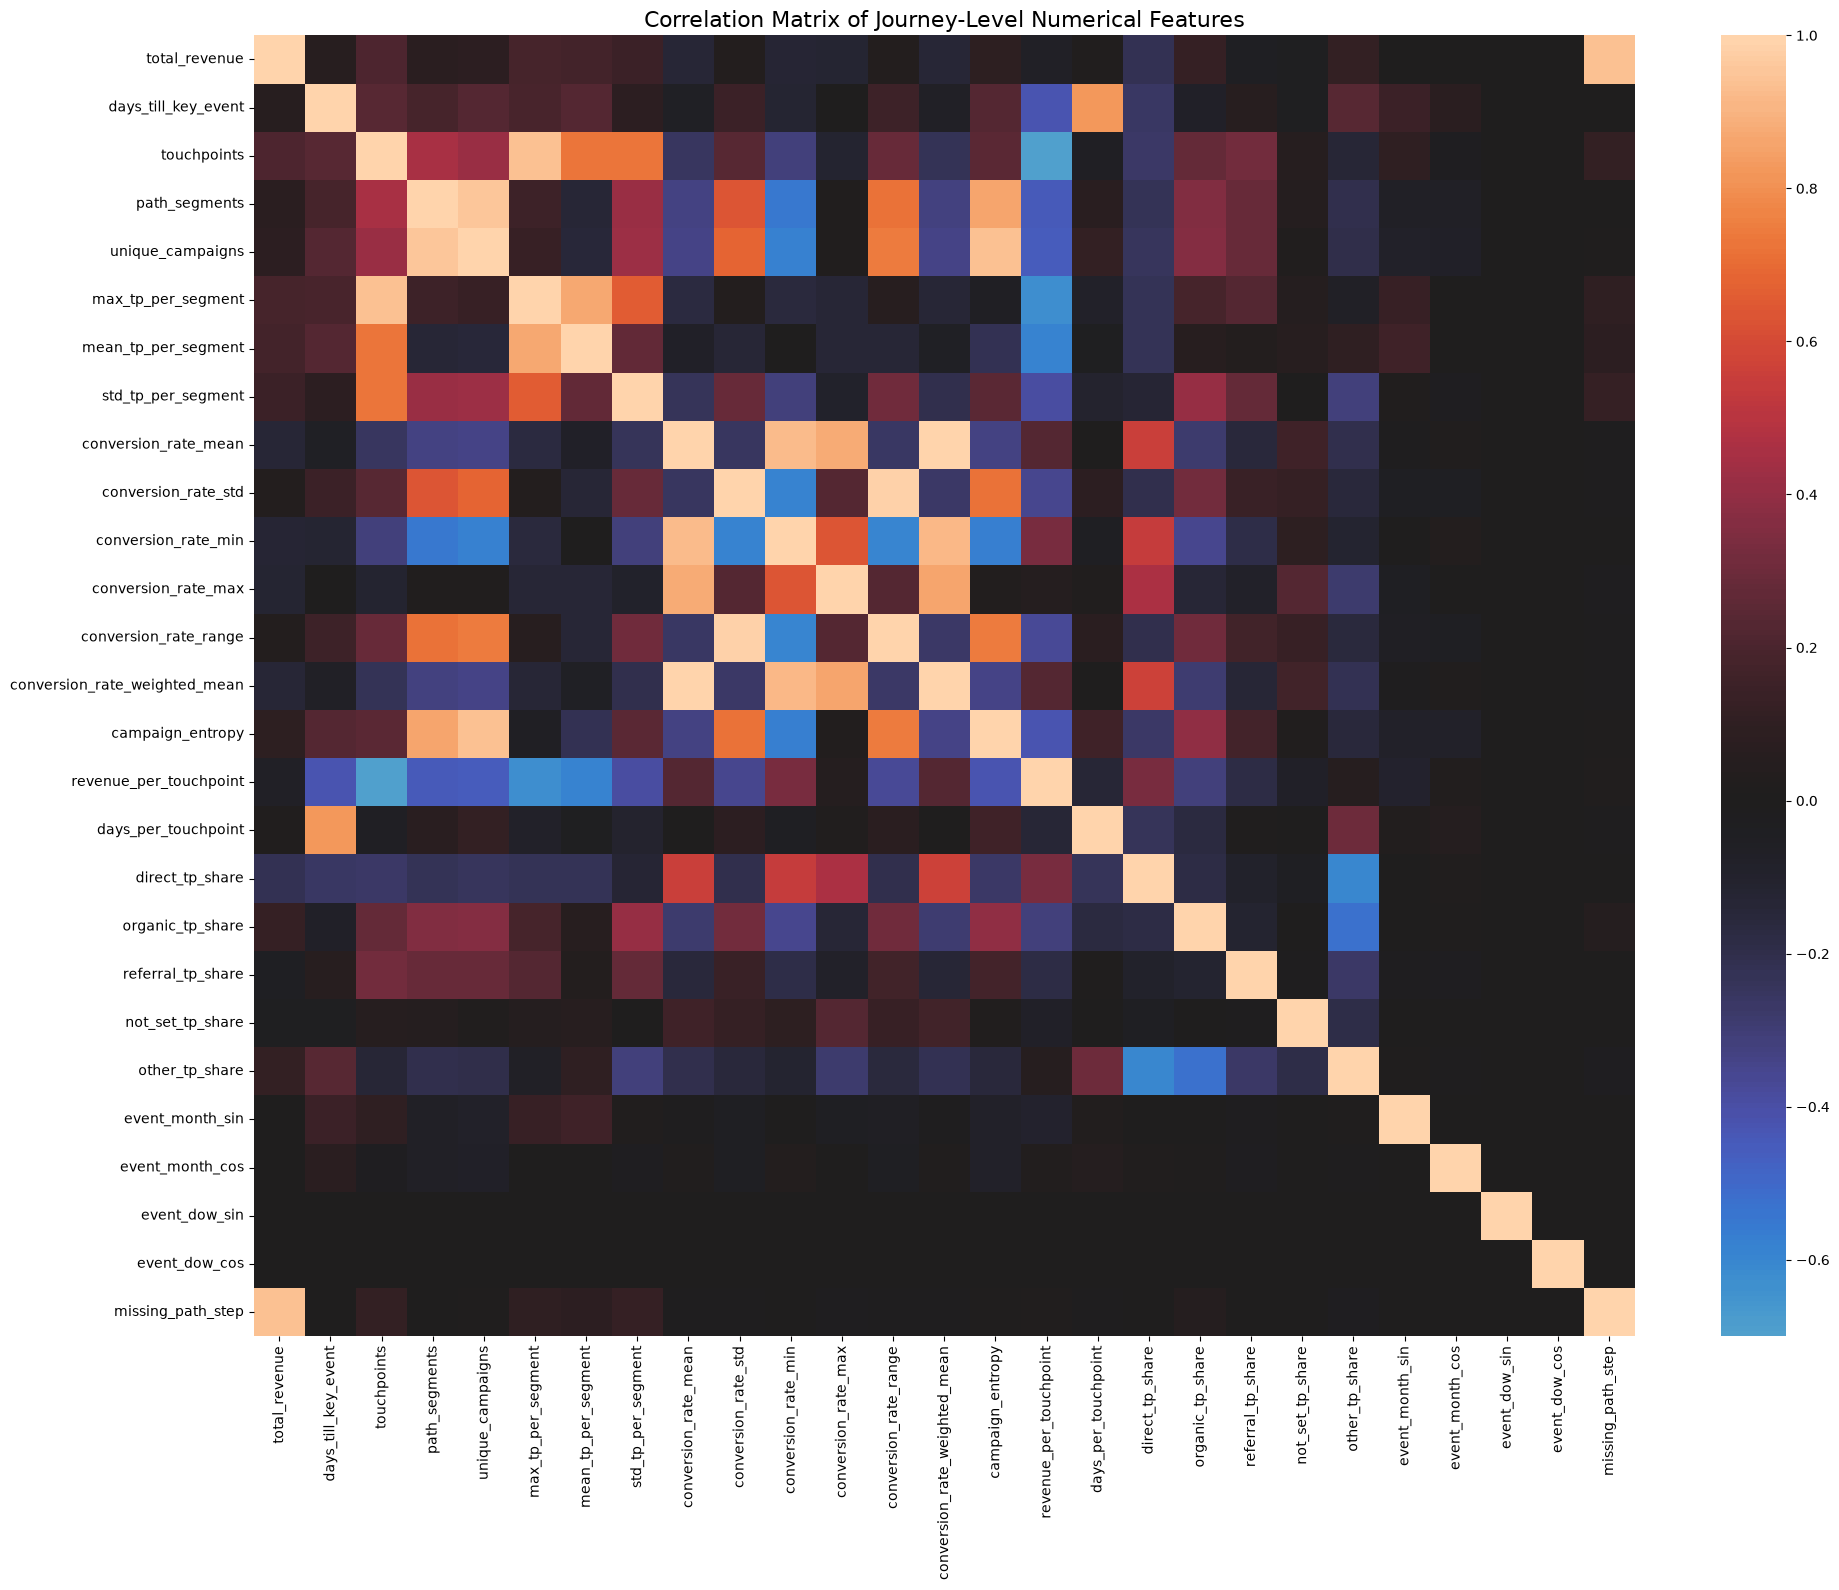

,Feature 1,Feature 2,Correlation,Absolute Correlation
229,conversion_rate_mean,conversion_rate_weighted_mean,0.9886,0.9886
255,conversion_rate_std,conversion_rate_range,0.9807,0.9807
85,path_segments,unique_campaigns,0.9493,0.9493
122,unique_campaigns,campaign_entropy,0.9398,0.9398
59,touchpoints,max_tp_per_segment,0.9365,0.9365
26,total_revenue,missing_path_step,0.9346,0.9346
226,conversion_rate_mean,conversion_rate_min,0.9251,0.9251
283,conversion_rate_min,conversion_rate_weighted_mean,0.9186,0.9186
227,conversion_rate_mean,conversion_rate_max,0.8747,0.8747
141,max_tp_per_segment,mean_tp_per_segment,0.8705,0.8705


In [11]:
correlation_matrix = journey_features.corr()

plt.figure(figsize=(20, 16))

sns.heatmap(
    correlation_matrix,
    center=0
)

plt.title(
    "Correlation Matrix of Journey-Level Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()


# Extract the strongest non-duplicate correlation pairs.
upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

strong_correlations = (
    upper_triangle
    .stack()
    .rename("Correlation")
    .reset_index()
)

strong_correlations.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

strong_correlations["Absolute Correlation"] = (
    strong_correlations["Correlation"].abs()
)

strong_correlations = (
    strong_correlations[
        strong_correlations["Absolute Correlation"] >= 0.70
    ]
    .sort_values(
        "Absolute Correlation",
        ascending=False
    )
)

display(strong_correlations)

### 2.3 Correlation Analysis

The correlation matrix reveals several strong relationships between the engineered variables.

The strongest relationships include approximately:

- `conversion_rate_mean` and `conversion_rate_weighted_mean`: **0.99**
- `path_segments` and `unique_campaigns`: **0.95**
- `unique_campaigns` and `campaign_entropy`: **0.94**
- `touchpoints` and `max_tp_per_segment`: **0.94**
- `max_tp_per_segment` and `mean_tp_per_segment`: **0.87**
- `path_segments` and `campaign_entropy`: **0.86**
- `days_till_key_event` and `days_per_touchpoint`: **0.83**

These relationships are reasonable because several engineered variables describe related aspects of the same journey.

For example, journeys containing more path segments are also likely to contain more unique campaigns and therefore have greater campaign diversity.

Similarly, the ordinary mean and touchpoint-weighted mean conversion rates are extremely strongly correlated.

This correlation structure indicates that the dataset contains **substantial redundancy**. This is directly relevant to PCA: PCA should be able to combine some of these correlated variables into a smaller number of components while retaining much of the original information.

However, correlation does not imply causation. These relationships describe statistical co-movement within the dataset and should not be interpreted as evidence that one feature causes another.

In [12]:
major_features = [
    "total_revenue",
    "days_till_key_event",
    "touchpoints",
    "path_segments",
    "unique_campaigns",
    "max_tp_per_segment",
    "mean_tp_per_segment",
    "conversion_rate_mean",
    "conversion_rate_weighted_mean",
    "conversion_rate_range",
    "campaign_entropy",
    "revenue_per_touchpoint",
    "days_per_touchpoint",
    "direct_tp_share",
    "organic_tp_share",
    "referral_tp_share",
    "not_set_tp_share",
    "other_tp_share"
]

distribution_statistics = pd.DataFrame({
    "Mean": journey_features[major_features].mean(),
    "Median": journey_features[major_features].median(),
    "Std": journey_features[major_features].std(),
    "Minimum": journey_features[major_features].min(),
    "Maximum": journey_features[major_features].max(),
    "Skewness": journey_features[major_features].skew(),
    "Excess Kurtosis": journey_features[major_features].kurt()
})

display(
    distribution_statistics
    .sort_values(
        "Skewness",
        key=abs,
        ascending=False
    )
)

,Mean,Median,Std,Minimum,Maximum,Skewness,Excess Kurtosis
total_revenue,185.5141,190.3601,62.9769,2.7917,"2,811.9600",36.9722,"1,529.0999"
not_set_tp_share,0.0109,0.0000,0.0888,0.0000,1.0000,9.3296,91.8260
referral_tp_share,0.0433,0.0000,0.1647,0.0000,1.0000,4.2499,18.2079
mean_tp_per_segment,2.3673,1.5000,2.0842,1.0000,20.0000,2.9350,13.8191
max_tp_per_segment,2.7906,2.0000,2.7238,1.0000,20.0000,2.7326,9.8186
direct_tp_share,0.1033,0.0000,0.3043,0.0000,1.0000,2.6076,4.7999
touchpoints,3.5357,3.0000,3.2414,1.0000,20.0000,2.5909,8.8096
path_segments,1.6022,1.0000,0.9104,1.0000,8.0000,2.1042,6.1357
conversion_rate_range,0.0026,0.0000,0.0042,0.0000,0.0190,1.7819,2.9397
organic_tp_share,0.1469,0.0000,0.2779,0.0000,1.0000,1.6490,1.2924


### 2.4 Skewness and Kurtosis

Skewness measures the asymmetry of a distribution. A common population definition is:

\[
\gamma_1 =
E\left[
\left(
\frac{X-\mu}{\sigma}
\right)^3
\right]
\]

where \(\mu\) is the mean and \(\sigma\) is the standard deviation.

- \(\gamma_1 \approx 0\): approximately symmetric distribution.
- \(\gamma_1 > 0\): long right tail.
- \(\gamma_1 < 0\): long left tail.

Kurtosis measures the strength of the tails relative to the center of the distribution. Pandas reports **excess kurtosis**:

\[
\gamma_2 =
E\left[
\left(
\frac{X-\mu}{\sigma}
\right)^4
\right]-3
\]

A Gaussian distribution therefore has excess kurtosis approximately equal to zero.

The observed distributions are far from uniformly Gaussian.

Most notably:

- `total_revenue` has extremely high positive skewness of approximately **36.97** and excess kurtosis above **1,500**.
- `touchpoints` has skewness of approximately **2.59** and positive kurtosis.
- `path_segments`, `max_tp_per_segment`, and `mean_tp_per_segment` are also strongly right-skewed.
- `days_till_key_event` is moderately positively skewed.
- the mean conversion-rate variables are comparatively close to symmetric.
- `referral_tp_share` and especially `not_set_tp_share` are highly right-skewed because most journeys contain no touchpoints from these categories, while a relatively small subset contains substantial proportions.

These results show why assuming Gaussianity for all features would be inappropriate. This observation will later be especially important when evaluating Z-score anomaly detection.

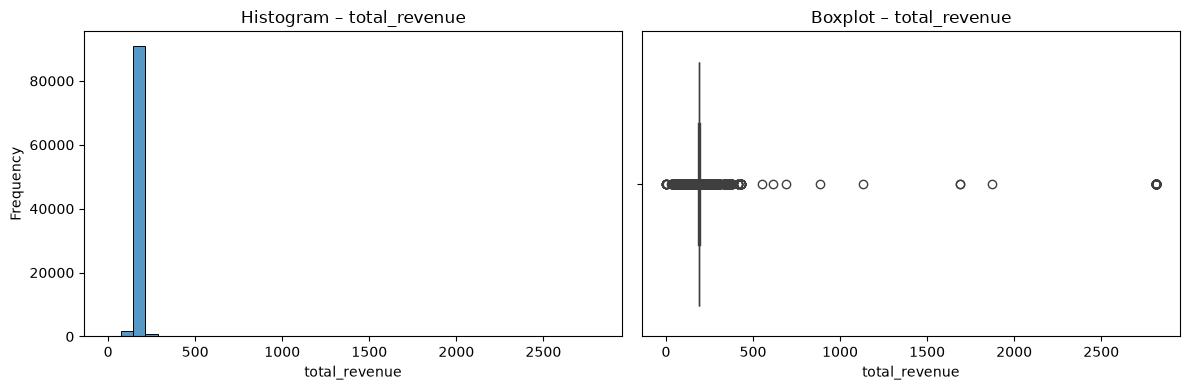

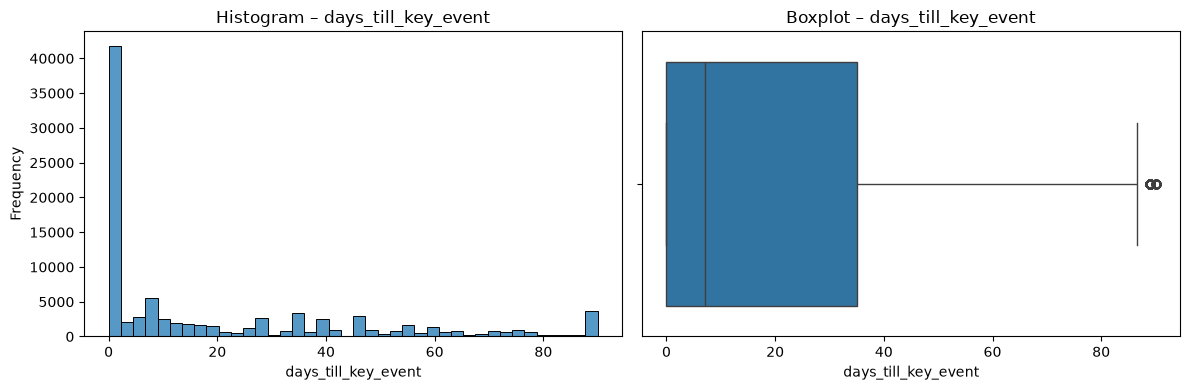

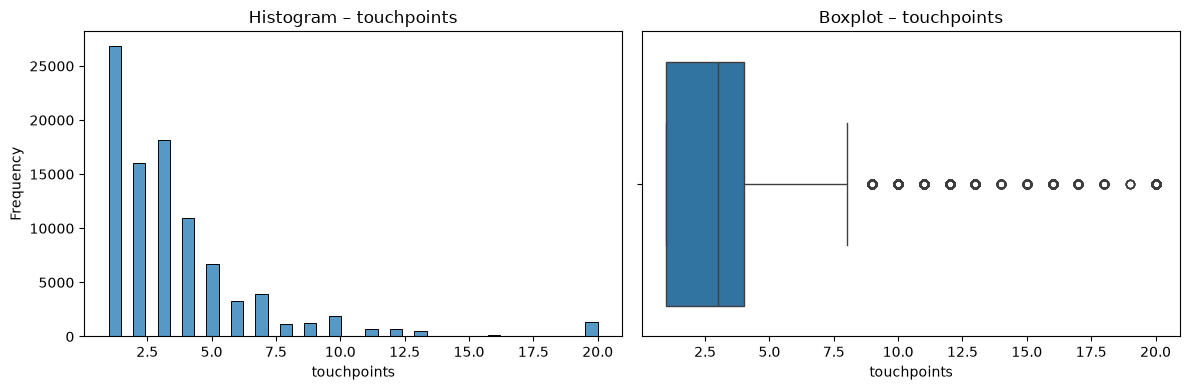

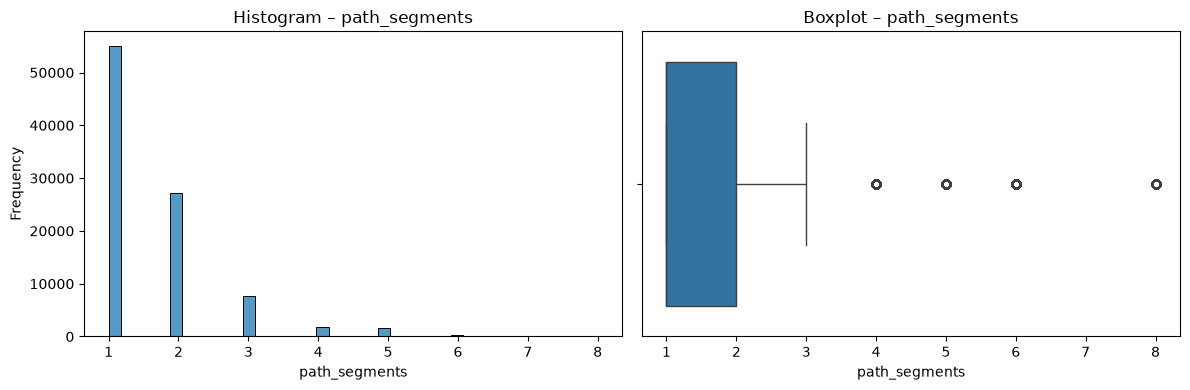

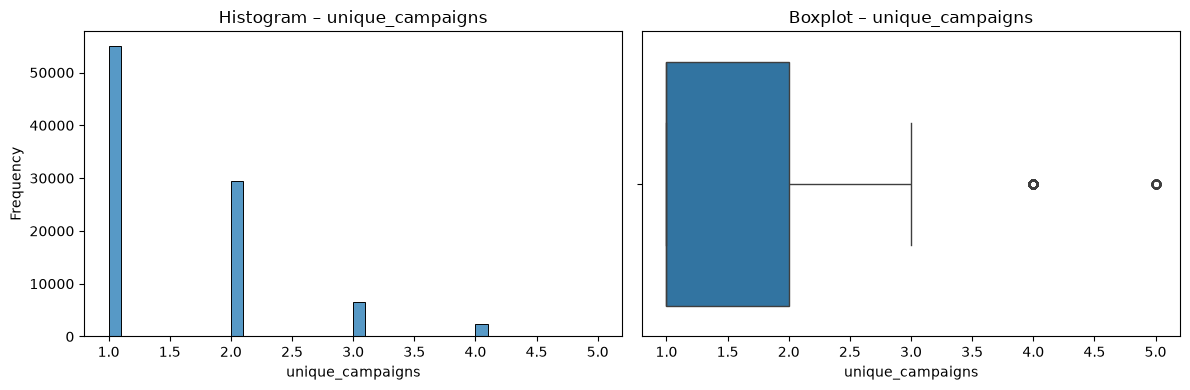

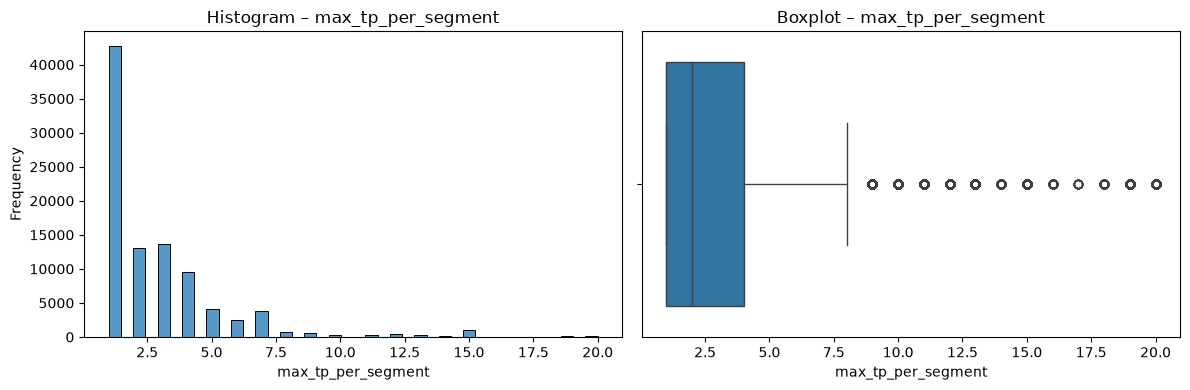

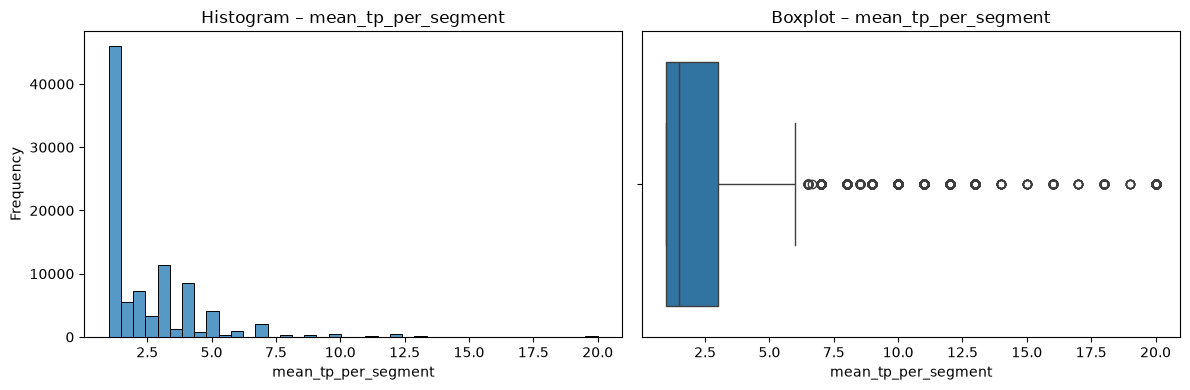

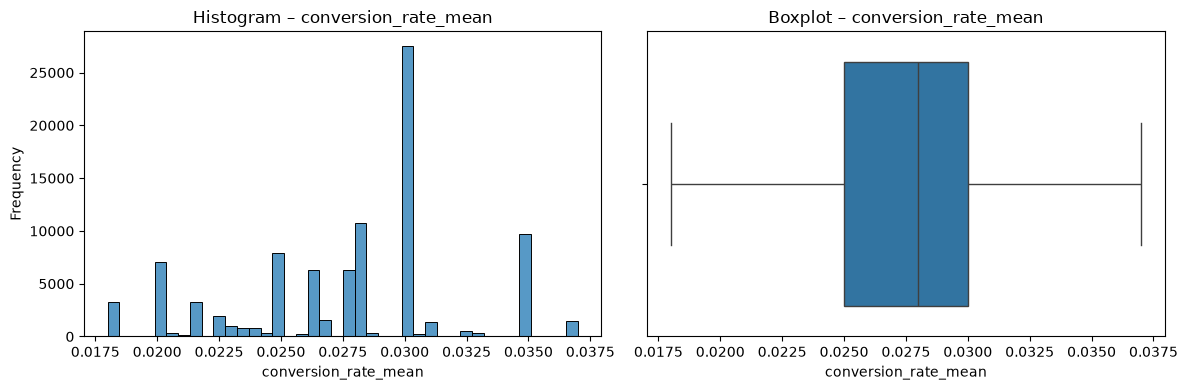

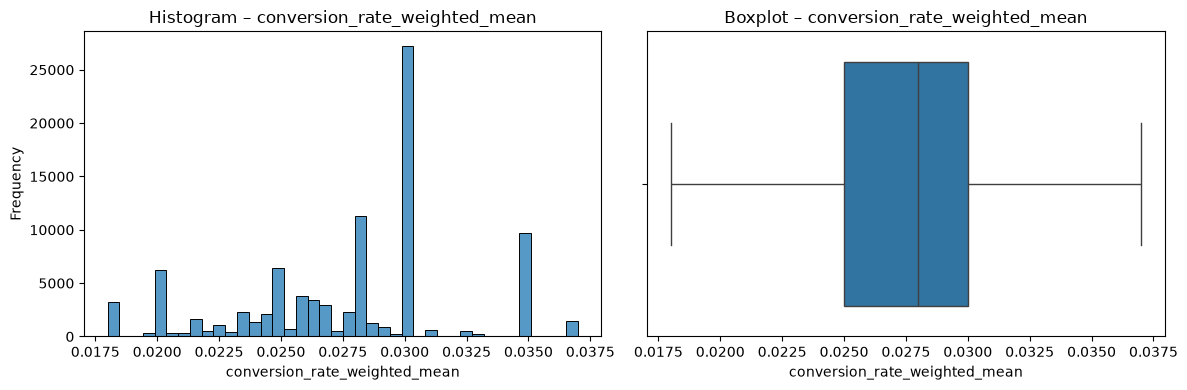

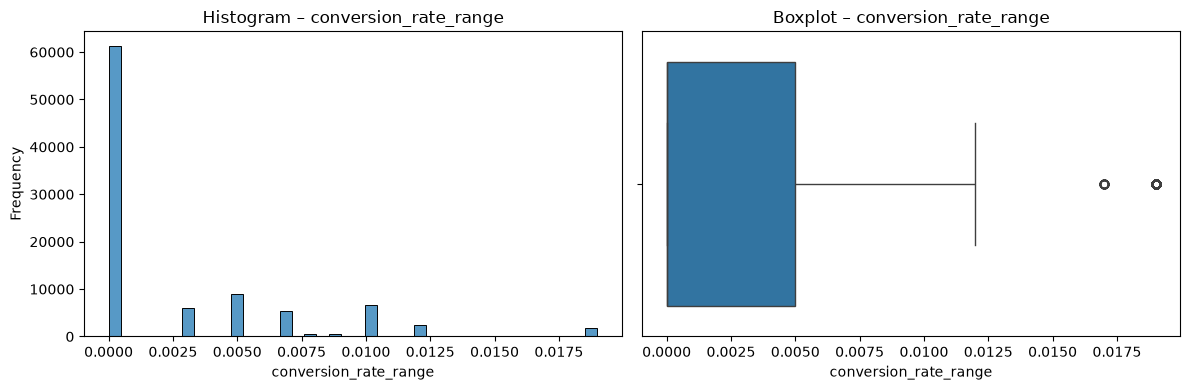

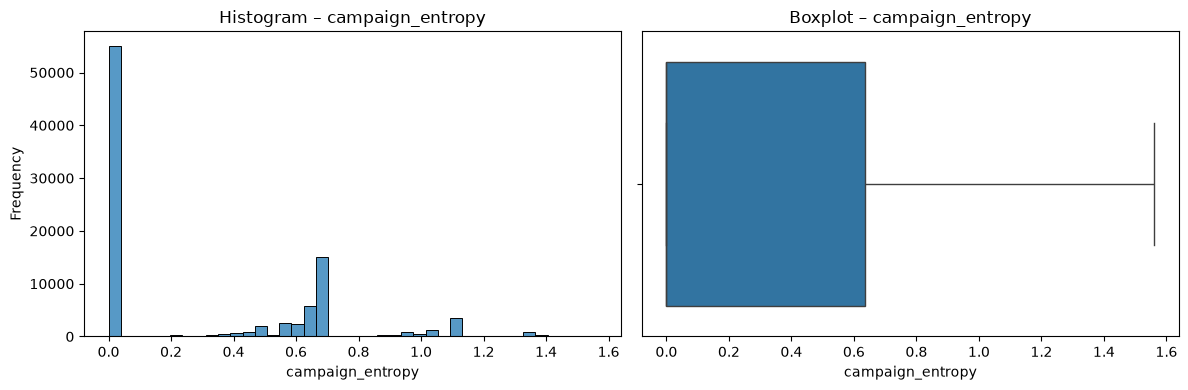

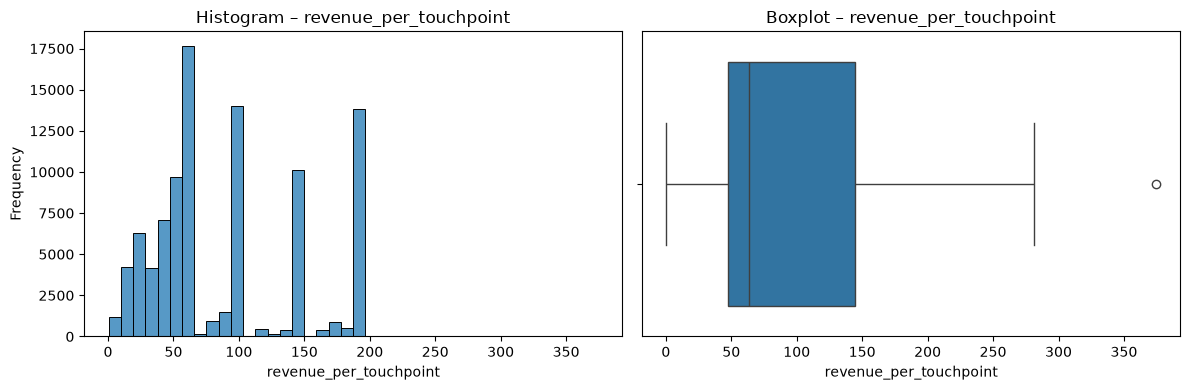

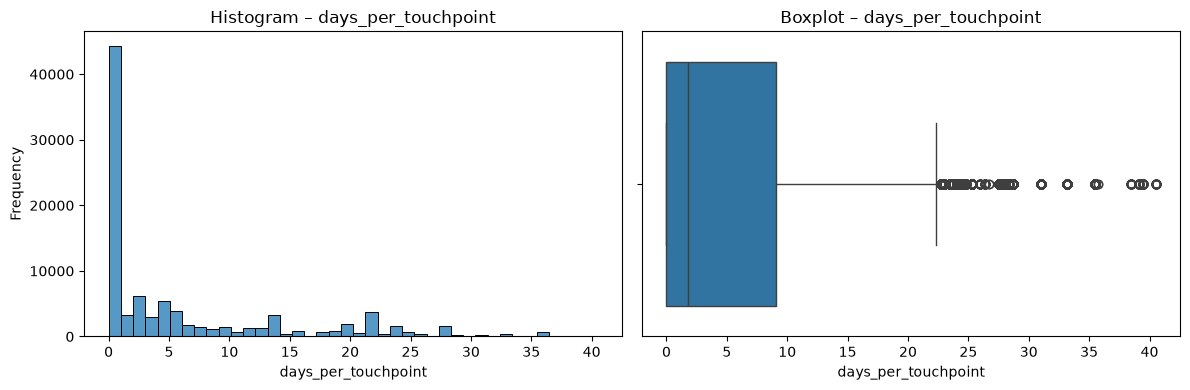

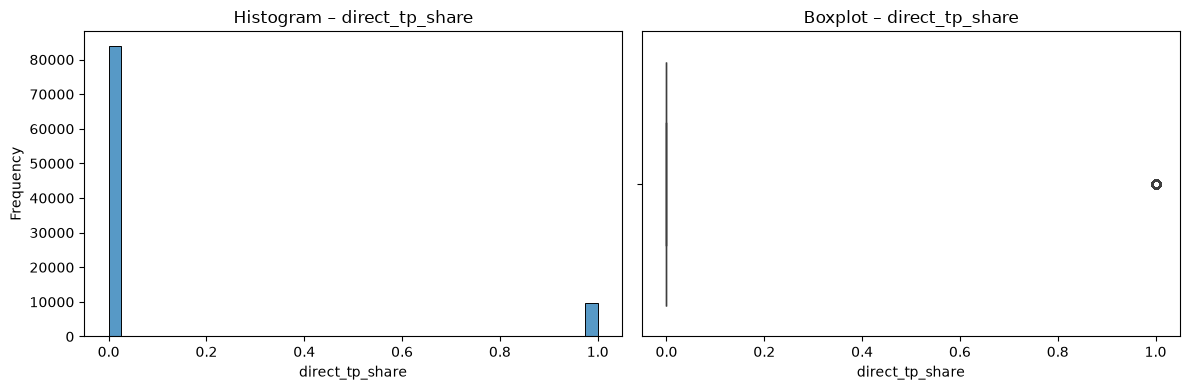

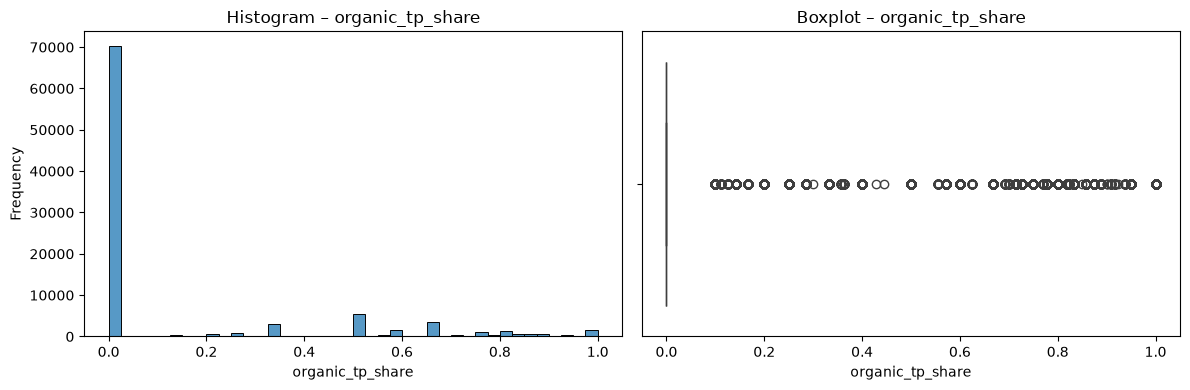

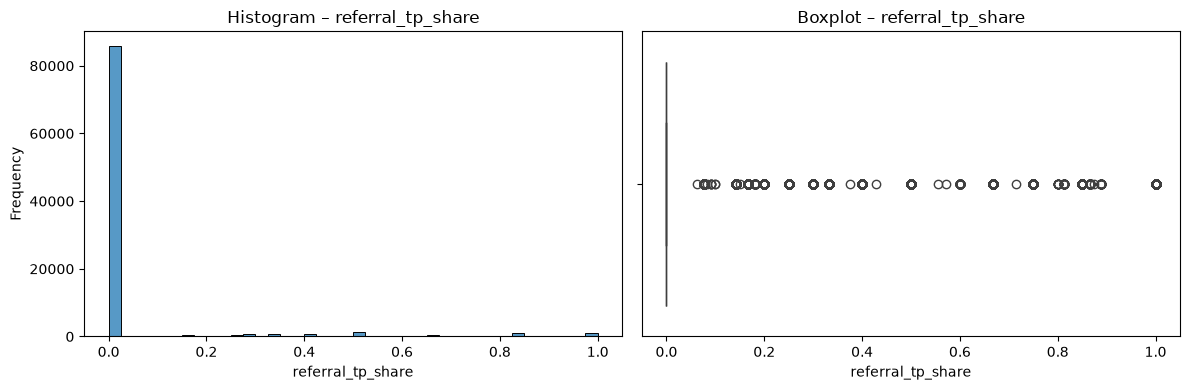

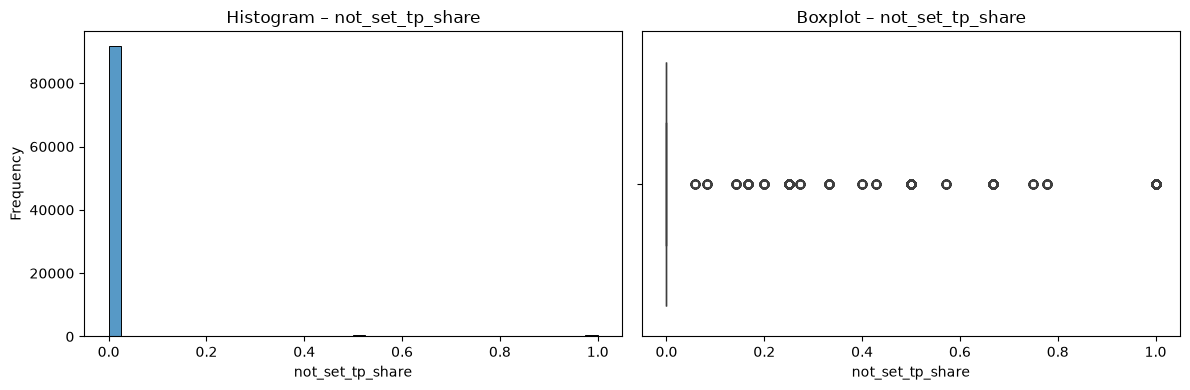

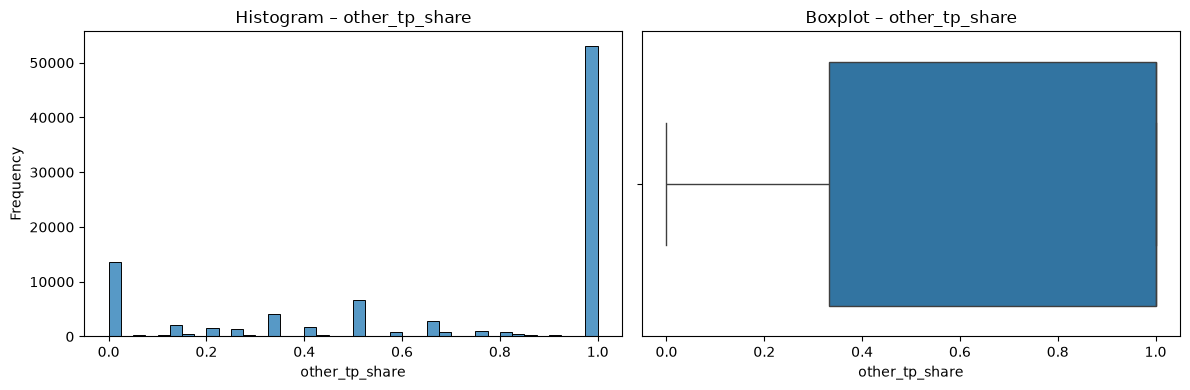

In [13]:
for feature in major_features:

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 4)
    )

    sns.histplot(
        data=journey_features,
        x=feature,
        bins=40,
        ax=axes[0]
    )

    axes[0].set_title(
        f"Histogram – {feature}"
    )

    axes[0].set_ylabel("Frequency")

    sns.boxplot(
        data=journey_features,
        x=feature,
        ax=axes[1]
    )

    axes[1].set_title(
        f"Boxplot – {feature}"
    )

    plt.tight_layout()
    plt.show()

### Distribution Analysis

The histograms and boxplots confirm that the journey-level features have substantially different distribution shapes.

#### Revenue

`total_revenue` has a highly concentrated central region together with a very long right tail. The median is approximately 190, while the maximum value reaches approximately 2,812. The extreme tail is responsible for the exceptionally high skewness and kurtosis.

#### Journey Duration

`days_till_key_event` is positively skewed. A large number of journeys reach their key event on the same day, while a smaller group continues for considerably longer periods, up to approximately 90 days.

A zero value should not automatically be treated as an error because a same-day conversion is a plausible e-commerce event.

#### Touchpoints and Path Complexity

`touchpoints`, `path_segments`, `max_tp_per_segment`, and `mean_tp_per_segment` all show positive skewness. Most journeys are relatively short and simple, while a much smaller number contain many interactions.

This is behaviorally plausible: most customers interact with relatively few marketing sources before converting, while a minority undergo much longer journeys.

#### Conversion Rates

The conversion-rate features occupy a very narrow numerical interval and are considerably less skewed than the journey-length variables.

The distributions are also discrete rather than continuous. This reflects the fact that the raw dataset contains only a small number of conversion-rate values associated with campaigns.

#### Campaign Diversity

`campaign_entropy` is concentrated near zero for many journeys because a large fraction of journeys involve only one campaign or traffic source. Journeys involving several sources produce larger entropy values.

#### Traffic-Source Shares

The traffic-source proportion variables contain many zeros and ones. They are therefore bounded, zero-inflated distributions rather than Gaussian continuous variables.

For this reason, an observation appearing far from the quartiles of a share variable should not automatically be considered anomalous.

In [14]:
iqr_features = [
    "total_revenue",
    "days_till_key_event",
    "touchpoints",
    "path_segments",
    "unique_campaigns",
    "max_tp_per_segment",
    "mean_tp_per_segment",
    "conversion_rate_mean",
    "conversion_rate_weighted_mean",
    "conversion_rate_range",
    "campaign_entropy",
    "revenue_per_touchpoint",
    "days_per_touchpoint"
]

iqr_results = []

for feature in iqr_features:

    q1 = journey_features[feature].quantile(0.25)
    q3 = journey_features[feature].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        (journey_features[feature] < lower_bound)
        |
        (journey_features[feature] > upper_bound)
    )

    iqr_results.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "IQR Outliers": int(outlier_mask.sum()),
        "Outlier Percentage (%)": outlier_mask.mean() * 100
    })

iqr_summary = pd.DataFrame(iqr_results)

display(
    iqr_summary.sort_values(
        "Outlier Percentage (%)",
        ascending=False
    )
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,IQR Outliers,Outlier Percentage (%)
0,total_revenue,188.8385,190.5809,1.7424,186.2249,193.1945,18718,19.9917
2,touchpoints,1.0000,4.0000,3.0000,-3.5000,8.5000,6677,7.1313
12,days_per_touchpoint,0.0000,9.0700,9.0700,-13.6050,22.6750,6362,6.7949
6,mean_tp_per_segment,1.0000,3.0000,2.0000,-2.0000,6.0000,4332,4.6268
3,path_segments,1.0000,2.0000,1.0000,-0.5000,3.5000,3789,4.0468
1,days_till_key_event,0.0000,35.0000,35.0000,-52.5000,87.5000,3712,3.9646
5,max_tp_per_segment,1.0000,4.0000,3.0000,-3.5000,8.5000,3405,3.6367
4,unique_campaigns,1.0000,2.0000,1.0000,-0.5000,3.5000,2486,2.6552
9,conversion_rate_range,0.0000,0.0050,0.0050,-0.0075,0.0125,1809,1.9321
11,revenue_per_touchpoint,47.2487,144.4458,97.1971,-98.5469,290.2414,1,0.0011


In [15]:
maximum_revenue = journey_features["total_revenue"].max()

maximum_revenue_ids = set(
    journey_features.index[
        journey_features["total_revenue"] == maximum_revenue
    ]
)

missing_step_ids = set(
    eda_raw.loc[
        eda_raw["path_step_numeric"].isna(),
        "Path ID"
    ]
)

print(f"Maximum Total Revenue: {maximum_revenue:,.2f}")

print(
    "Journeys with maximum Total Revenue:",
    len(maximum_revenue_ids)
)

print(
    "Journeys containing a missing Path Step:",
    len(missing_step_ids)
)

print(
    "Are these exactly the same Path IDs?",
    maximum_revenue_ids == missing_step_ids
)

print(
    "\nUnique non-missing Total Revenue values:",
    eda_raw["Total Revenue"].nunique(dropna=True)
)

print(
    "Unique Conversion Rate values:",
    eda_raw["Conversion Rate"].nunique()
)

campaign_conversion_variation = (
    eda_raw
    .groupby("Campaign")["Conversion Rate"]
    .nunique()
)

print(
    "Does every campaign have exactly one Conversion Rate?",
    campaign_conversion_variation.eq(1).all()
)

same_day_paths = (
    journey_features["days_till_key_event"] == 0
).sum()

print(
    f"\nSame-day key-event journeys: "
    f"{same_day_paths:,} "
    f"({same_day_paths / len(journey_features) * 100:.2f}%)"
)

print("\nExamples of the maximum-revenue journeys:")

display(
    journey_df.loc[
        sorted(maximum_revenue_ids),
        [
            "total_revenue",
            "days_till_key_event",
            "touchpoints",
            "path_segments",
            "unique_campaigns",
            "max_tp_per_segment",
            "mean_tp_per_segment",
            "conversion_rate_mean",
            "campaign_entropy",
            "missing_path_step",
            "event_date"
        ]
    ].head(10)
)

Maximum Total Revenue: 2,811.96
Journeys with maximum Total Revenue: 47
Journeys containing a missing Path Step: 47
Are these exactly the same Path IDs? True

Unique non-missing Total Revenue values: 558
Unique Conversion Rate values: 7
Does every campaign have exactly one Conversion Rate? True

Same-day key-event journeys: 34,587 (36.94%)

Examples of the maximum-revenue journeys:


,total_revenue,days_till_key_event,touchpoints,path_segments,unique_campaigns,max_tp_per_segment,mean_tp_per_segment,conversion_rate_mean,campaign_entropy,missing_path_step,event_date
Path ID,,,,,,,,,,,
94377,"2,811.9600",15.0000,20.0000,2,2,15,10.0000,0.0250,0.5623,1,2025-04-27
94378,"2,811.9600",15.0000,20.0000,2,2,15,10.0000,0.0250,0.5623,1,2024-06-19
94379,"2,811.9600",15.0000,20.0000,2,2,15,10.0000,0.0250,0.5623,1,2025-01-07
94380,"2,811.9600",15.0000,20.0000,2,2,15,10.0000,0.0250,0.5623,1,2025-03-24
94381,"2,811.9600",15.0000,20.0000,2,2,15,10.0000,0.0250,0.5623,1,2025-03-30
94382,"2,811.9600",15.0000,20.0000,2,2,15,10.0000,0.0250,0.5623,1,2024-08-02
94383,"2,811.9600",15.0000,20.0000,2,2,15,10.0000,0.0250,0.5623,1,2025-01-30
94384,"2,811.9600",15.0000,20.0000,2,2,15,10.0000,0.0250,0.5623,1,2024-07-28
94385,"2,811.9600",15.0000,20.0000,2,2,15,10.0000,0.0250,0.5623,1,2025-04-05


### 2.5 Outlier Exploration and Data-Quality Investigation

The distribution analysis reveals several observations that appear statistically extreme. However, statistical extremeness alone is not sufficient to determine whether an observation is a genuine anomaly, a valid rare customer journey, or a data-quality artifact.

#### Heavy Tails

Several variables contain pronounced right tails.

The clearest example is `total_revenue`, whose extreme skewness and kurtosis indicate a small number of observations very far from the main concentration of the data.

Journey-complexity variables such as `touchpoints`, `max_tp_per_segment`, and `mean_tp_per_segment` also have right tails, although these values may represent legitimate customers with unusually long purchase journeys.

Therefore, heavy-tailed behavior is part of the structure of the dataset and should not automatically be removed.

#### Extreme Revenue Values

A particularly important pattern was found at the upper end of `total_revenue`.

The maximum revenue is approximately **2,811.96**, compared with a median around **190.36**.

Exactly **47 journeys** have this maximum revenue.

Unexpectedly, the same **47 Path IDs are also exactly the 47 journeys containing a missing `Path Step` value**.

These journeys also share a highly similar structural profile.

This one-to-one relationship between an extreme numerical value and a data-quality irregularity is suspicious. It could indicate:

- a special but legitimate journey pattern,
- a transformation artifact introduced while constructing the dataset,
- a missing sequential label associated with a particular journey template,
- or another undocumented aspect of the source-data pipeline.

Without additional source documentation, it would be inappropriate to declare these observations incorrect.

Therefore, they will **not be deleted during EDA**. Instead, the missing-step indicator is retained so that we can later determine whether anomaly-detection algorithms independently identify these journeys as unusual.

This provides a useful real-world example of the distinction between a statistical anomaly and a possible measurement artifact.

#### Possible Noise and Data-Entry Problems

There are **47 blank `Path Step` values**. Because the remaining Path Step values follow a simple ordered structure, these blank entries represent a possible data-entry or preprocessing problem.

In addition, **2,111 raw rows contain `(not set)` as the campaign value**. This is not treated as an ordinary missing value because `(not set)` is an explicit category in the source data. Nevertheless, it represents incomplete information about the acquisition source.

#### Structural Missingness Is Not Noise

The 56,382 blank values in each of `Total Revenue`, `Days till key event`, and `Touchpoints` are not treated as data-entry errors.

The structural analysis showed that every Path ID has exactly one valid value for each of these journey-level variables. Their remaining blank cells result from the long-format representation.

This demonstrates why missing-value analysis must consider the meaning and structure of the data rather than relying only on the numerical missing-value count.

#### Possible Measurement or Aggregation Artifacts

`Conversion Rate` contains only a small number of distinct values, and every campaign has one fixed conversion-rate value.

Consequently, this variable behaves more like a **campaign-level characteristic repeated across observations** than an independent measurement for every customer journey.

Similarly, `Total Revenue` contains substantially fewer distinct values than the number of journeys, with many repeated values.

These patterns do not necessarily represent errors, but they suggest that some fields may contain aggregated or transformed information. They should therefore be interpreted cautiously.

#### IQR Outliers

The classical \(1.5\times IQR\) rule is useful for exploratory purposes:

\[
IQR = Q_3-Q_1
\]

and observations outside

\[
[Q_1-1.5IQR,\;Q_3+1.5IQR]
\]

are traditionally marked as potential outliers.

However, the rule is not a definition of anomaly.

For example, approximately one fifth of the revenue observations are outside the revenue IQR boundaries because the middle 50% of the revenue distribution occupies a very narrow interval. Labeling such a large fraction of the dataset as anomalous would clearly be inappropriate.

The problem becomes even stronger for zero-inflated traffic-share variables: if both the first and third quartiles are zero, every non-zero observation could formally be classified as an IQR outlier.

For this reason, IQR results are used only to understand the distributions and are **not converted into anomaly labels**.

#### False Outliers and Legitimate Rare Behavior

A high number of touchpoints, a long journey duration, or a rare combination of campaigns may be statistically unusual while still describing a genuine customer.

Removing such observations before the anomaly-detection stage could eliminate exactly the patterns that the later algorithms are intended to study.

Therefore, no observations are removed solely because of their histogram, boxplot, skewness, kurtosis, or IQR position.

### 2.6 EDA Conclusions

The exploratory analysis leads to several methodological conclusions for the next stages of the project.

1. The original dataset is a long-format journey dataset, and the raw 150,011 rows should not be treated as independent customer observations.

2. Aggregation by `Path ID` produces **93,629 journey observations and 27 numerical analytical features with no missing values**.

3. Several variables are strongly correlated, demonstrating redundancy in the original information. This suggests that dimensionality reduction through PCA may be useful.

4. The numerical variables exist on very different scales. Standardization will therefore be required before PCA and most distance-based clustering or anomaly-detection methods.

5. Several distributions are strongly non-Gaussian and heavy-tailed. This is especially important for the later Z-score anomaly-detection method, whose assumptions may be inappropriate for some variables.

6. The dataset contains both statistically extreme observations and potential data-quality artifacts. The most notable example is the group of 47 maximum-revenue journeys that exactly coincides with the 47 journeys containing a missing `Path Step`.

7. These suspicious observations are retained rather than removed. They will later provide an opportunity to test whether different anomaly-detection methods identify them independently.

8. Traffic-source share variables are bounded and often zero-inflated, while campaign conversion rates are highly discrete. Standard outlier rules should therefore be interpreted cautiously.

Overall, the EDA shows that the dataset contains meaningful structure, redundancy, skewness, potential artifacts, and rare behaviors. These properties make it particularly suitable for comparing multiple unsupervised-learning and anomaly-detection methods.

## 3. Dimensionality Reduction

### 3.1 Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is used to investigate whether the high-dimensional journey representation can be described using a smaller number of dimensions while retaining most of the information contained in the original numerical features.

PCA is particularly relevant to this dataset because the EDA revealed substantial correlation and redundancy between several engineered variables.

The analysis will examine:

- explained variance and cumulative explained variance,
- the number of principal components required to represent the data adequately,
- a scree plot,
- two-dimensional and three-dimensional projections,
- the contribution of the original variables to the principal components,
- redundancy in the original feature space,
- stability of the PCA solution,
- interpretability and computational cost,
- and the limitations of PCA with respect to local structure and cluster separation.

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Verify that the journey-level dataset from the EDA exists.
if "journey_features" not in globals():
    raise NameError(
        "journey_features is not defined. "
        "Run the notebook from the beginning before running the PCA section."
    )

# 'missing_path_step' is a data-quality diagnostic indicator rather
# than a behavioral customer feature. It is therefore kept for later
# investigation but excluded from the primary PCA model.
pca_feature_names = [
    column
    for column in journey_features.columns
    if column != "missing_path_step"
]

X_pca_input = (
    journey_features[pca_feature_names]
    .astype(float)
    .copy()
)

assert X_pca_input.isna().sum().sum() == 0
assert np.isfinite(X_pca_input.to_numpy()).all()

print(
    f"PCA input matrix: "
    f"{X_pca_input.shape[0]:,} journeys × "
    f"{X_pca_input.shape[1]} numerical features"
)

print(
    "Diagnostic feature excluded from PCA:",
    "missing_path_step"
)

PCA input matrix: 93,629 journeys × 26 numerical features
Diagnostic feature excluded from PCA: missing_path_step


### 3.1.1 PCA Methodology and Mathematical Intuition

PCA constructs new orthogonal variables, called **principal components**, that are linear combinations of the original variables.

Before PCA, the variables are standardized:

\[
z_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j}
\]

where \(x_{ij}\) is the value of feature \(j\) for observation \(i\), \(\mu_j\) is the feature mean, and \(\sigma_j\) is its standard deviation.

Standardization is essential in this dataset because the variables exist on very different numerical scales. For example, revenue may contain values in the thousands, traffic-source proportions are bounded between 0 and 1, and conversion rates occupy a narrow interval.

Without scaling, variables with large numerical variance could dominate the PCA simply because of their units.

For the standardized matrix \(Z\), PCA examines its covariance matrix:

\[
\Sigma = \frac{1}{n-1}Z^TZ
\]

The principal-component directions are obtained from the eigenvectors of this matrix:

\[
\Sigma v_k=\lambda_kv_k
\]

where \(v_k\) is the direction of principal component \(k\), and \(\lambda_k\) is the variance captured along that direction.

The score of an observation on principal component \(k\) is:

\[
PC_k = Zv_k
\]

The explained-variance ratio of component \(k\) is:

\[
EVR_k=
\frac{\lambda_k}
{\sum_j\lambda_j}
\]

The cumulative explained variance allows us to determine how many components are required to preserve a desired percentage of the information.

PCA is an **unsupervised, linear, global dimensionality-reduction method**. It does not use anomaly labels or cluster labels.

In [17]:
# Standardize all PCA input features.
pca_scaler = StandardScaler()

X_scaled = pca_scaler.fit_transform(
    X_pca_input
)

# Fit PCA using all available dimensions first.
# This allows us to inspect the complete explained-variance spectrum.
pca_full = PCA(
    svd_solver="full"
)

X_pca_full = pca_full.fit_transform(
    X_scaled
)

explained_variance_ratio = (
    pca_full.explained_variance_ratio_
)

cumulative_explained_variance = np.cumsum(
    explained_variance_ratio
)

print(
    "Standardized feature means "
    f"(maximum absolute value): "
    f"{np.abs(X_scaled.mean(axis=0)).max():.3e}"
)

print(
    "Standardized feature standard deviations "
    f"(min / max): "
    f"{X_scaled.std(axis=0).min():.4f} / "
    f"{X_scaled.std(axis=0).max():.4f}"
)

print(
    f"Number of PCA components: "
    f"{pca_full.n_components_}"
)

Standardized feature means (maximum absolute value): 1.923e-15
Standardized feature standard deviations (min / max): 1.0000 / 1.0000
Number of PCA components: 26


In [18]:
pca_variance_table = pd.DataFrame({
    "Principal Component": [
        f"PC{i}"
        for i in range(
            1,
            len(explained_variance_ratio) + 1
        )
    ],
    "Explained Variance Ratio": explained_variance_ratio,
    "Explained Variance (%)": (
        explained_variance_ratio * 100
    ),
    "Cumulative Variance (%)": (
        cumulative_explained_variance * 100
    )
})

display(
    pca_variance_table.round(4)
)

threshold_results = []

for threshold in [0.80, 0.90, 0.95, 0.99]:

    n_components = (
        np.argmax(
            cumulative_explained_variance >= threshold
        )
        + 1
    )

    retained = (
        cumulative_explained_variance[
            n_components - 1
        ]
    )

    threshold_results.append({
        "Target Variance": f"{threshold * 100:.0f}%",
        "Required Components": n_components,
        "Actual Variance Retained (%)": retained * 100,
        "Information Lost (%)": (1 - retained) * 100
    })

threshold_table = pd.DataFrame(
    threshold_results
)

display(
    threshold_table.round(2)
)

,Principal Component,Explained Variance Ratio,Explained Variance (%),Cumulative Variance (%)
0,PC1,0.2622,26.2155,26.2155
1,PC2,0.1320,13.1988,39.4144
2,PC3,0.1222,12.2217,51.6361
3,PC4,0.0876,8.7559,60.3920
4,PC5,0.0471,4.7083,65.1002
5,PC6,0.0430,4.2993,69.3995
6,PC7,0.0397,3.9735,73.3730
7,PC8,0.0387,3.8718,77.2448
8,PC9,0.0386,3.8578,81.1026
9,PC10,0.0383,3.8319,84.9345


,Target Variance,Required Components,Actual Variance Retained (%),Information Lost (%)
0,80%,9,81.1000,18.9000
1,90%,12,91.6100,8.3900
2,95%,14,96.0900,3.9100
3,99%,17,99.2900,0.7100


### 3.1.2 Explained Variance

The PCA results show that the variance is distributed across several components rather than being concentrated almost entirely in one or two dimensions.

Approximately:

- **PC1 explains 26.2%** of the standardized variance.
- The first **2 components explain 39.4%**.
- The first **3 components explain 51.6%**.
- **9 components** retain approximately **81.1%**.
- **12 components** retain approximately **91.6%**.
- **14 components** retain approximately **96.1%**.
- **17 components** retain more than **99%**.

There is no mathematically universal threshold defining an "adequate" PCA representation. The appropriate choice depends on the purpose of the analysis.

For this project, **12 principal components** provide a useful compromise. They reduce the primary analytical space from 26 dimensions to 12 while preserving approximately **91.6% of the standardized variance**.

This means that approximately **8.4% of the variance is discarded**.

If a more conservative representation were required, 14 components would retain approximately 96.1% of the variance while discarding only about 3.9%.

The 2D and 3D PCA representations used for visualization should therefore not be interpreted as complete representations of the dataset. Two components discard approximately 60.6% of the variance, while three components still discard approximately 48.4%.

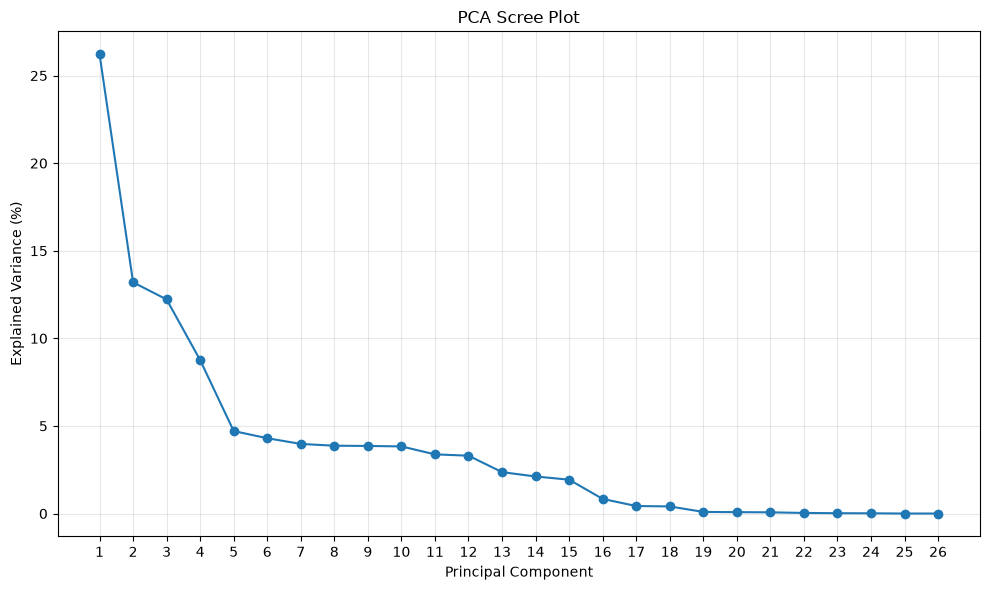

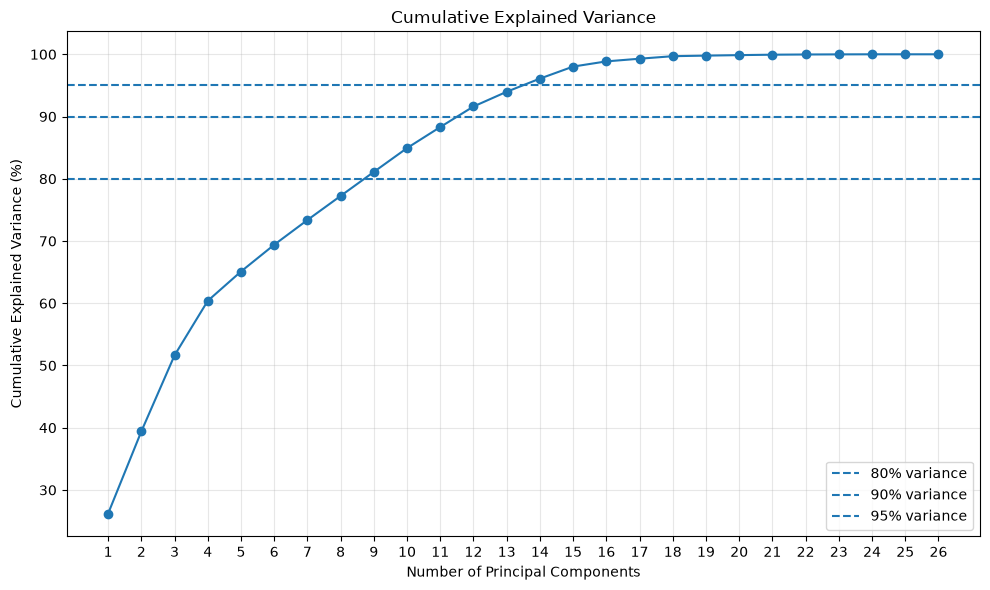

In [19]:
component_numbers = np.arange(
    1,
    len(explained_variance_ratio) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    component_numbers,
    explained_variance_ratio * 100,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("PCA Scree Plot")

plt.xticks(component_numbers)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.plot(
    component_numbers,
    cumulative_explained_variance * 100,
    marker="o"
)

plt.axhline(
    80,
    linestyle="--",
    label="80% variance"
)

plt.axhline(
    90,
    linestyle="--",
    label="90% variance"
)

plt.axhline(
    95,
    linestyle="--",
    label="95% variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance")

plt.xticks(component_numbers)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Scree-Plot Interpretation

The scree plot shows a large reduction in explained variance after the first few components, followed by a progressively flatter tail.

However, there is no single sharp elbow after which the remaining components become completely irrelevant.

This indicates that the dataset contains both:

- substantial redundancy, allowing meaningful dimensionality reduction,
- and several distinct sources of variation that cannot be represented accurately using only two or three dimensions.

The cumulative-variance curve therefore provides a more useful selection criterion than relying only on a visual elbow.

A 12-component representation is selected as the main reduced representation because it retains more than 90% of the total standardized variance while eliminating more than half of the original dimensions.

In [20]:
matrix_rank = np.linalg.matrix_rank(
    X_scaled
)

near_zero_components = int(
    (
        pca_full.explained_variance_ratio_
        < 1e-12
    ).sum()
)

print(
    f"Original PCA dimensions: "
    f"{X_scaled.shape[1]}"
)

print(
    f"Numerical matrix rank: "
    f"{matrix_rank}"
)

print(
    f"Essentially zero-variance "
    f"principal components: "
    f"{near_zero_components}"
)

print(
    "\nTwo known exact relationships "
    "in the engineered features are:"
)

print(
    "1. conversion_rate_range = "
    "conversion_rate_max - conversion_rate_min"
)

print(
    "2. direct_tp_share + organic_tp_share + "
    "referral_tp_share + not_set_tp_share + "
    "other_tp_share = 1"
)

Original PCA dimensions: 26
Numerical matrix rank: 24
Essentially zero-variance principal components: 2

Two known exact relationships in the engineered features are:
1. conversion_rate_range = conversion_rate_max - conversion_rate_min
2. direct_tp_share + organic_tp_share + referral_tp_share + not_set_tp_share + other_tp_share = 1


### Redundancy in the Original Feature Space

PCA confirms that the analytical feature matrix contains both strong correlations and exact linear redundancy.

The 26-dimensional standardized matrix has numerical rank **24**, meaning that two dimensions are completely redundant.

This is expected from the feature-engineering definitions.

First:

\[
\text{conversion rate range}
=
\text{conversion rate max}
-
\text{conversion rate min}
\]

Second, the five traffic-source shares always satisfy:

\[
p_{\text{direct}}
+
p_{\text{organic}}
+
p_{\text{referral}}
+
p_{\text{not set}}
+
p_{\text{other}}
=1
\]

Therefore, at least two variables can be reconstructed exactly from combinations of other variables.

The EDA also revealed strong non-exact correlations, such as the relationships between:

- mean and weighted mean conversion rates,
- path segments and unique campaigns,
- campaign entropy and campaign diversity,
- touchpoints and maximum touchpoints per segment,
- journey duration and days per touchpoint.

PCA is particularly useful in such a situation because correlated variables can contribute jointly to a smaller set of orthogonal components instead of being treated as completely independent dimensions.

The existence of redundancy does not mean that the original variables are useless. Their original units remain more interpretable. PCA instead provides a more compact representation for methods that operate on distances and high-dimensional geometry.

In [21]:
component_weights = pd.DataFrame(
    pca_full.components_.T,
    index=pca_feature_names,
    columns=[
        f"PC{i}"
        for i in range(
            1,
            pca_full.n_components_ + 1
        )
    ]
)

# Because PCA component vectors have unit length,
# squared coefficients can be expressed as percentage
# contributions to the direction of each component.
component_contribution = (
    component_weights.pow(2) * 100
)

top_contributors = []

for pc_number in range(1, 6):

    pc = f"PC{pc_number}"

    largest_features = (
        component_contribution[pc]
        .nlargest(8)
        .index
    )

    for feature in largest_features:

        top_contributors.append({
            "Principal Component": pc,
            "Feature": feature,
            "Weight": component_weights.loc[
                feature,
                pc
            ],
            "Absolute Weight": abs(
                component_weights.loc[
                    feature,
                    pc
                ]
            ),
            "Contribution (%)": (
                component_contribution.loc[
                    feature,
                    pc
                ]
            )
        })

top_contributors_df = pd.DataFrame(
    top_contributors
)

display(
    top_contributors_df.round(4)
)

,Principal Component,Feature,Weight,Absolute Weight,Contribution (%)
0,PC1,conversion_rate_min,0.3226,0.3226,10.4084
1,PC1,unique_campaigns,-0.3144,0.3144,9.8832
2,PC1,path_segments,-0.3053,0.3053,9.3227
3,PC1,campaign_entropy,-0.2918,0.2918,8.5168
4,PC1,conversion_rate_range,-0.2766,0.2766,7.6523
5,PC1,conversion_rate_std,-0.2642,0.2642,6.9791
6,PC1,conversion_rate_mean,0.2597,0.2597,6.7456
7,PC1,conversion_rate_weighted_mean,0.2567,0.2567,6.5881
8,PC2,conversion_rate_max,0.4098,0.4098,16.7963
9,PC2,other_tp_share,-0.2969,0.2969,8.8177


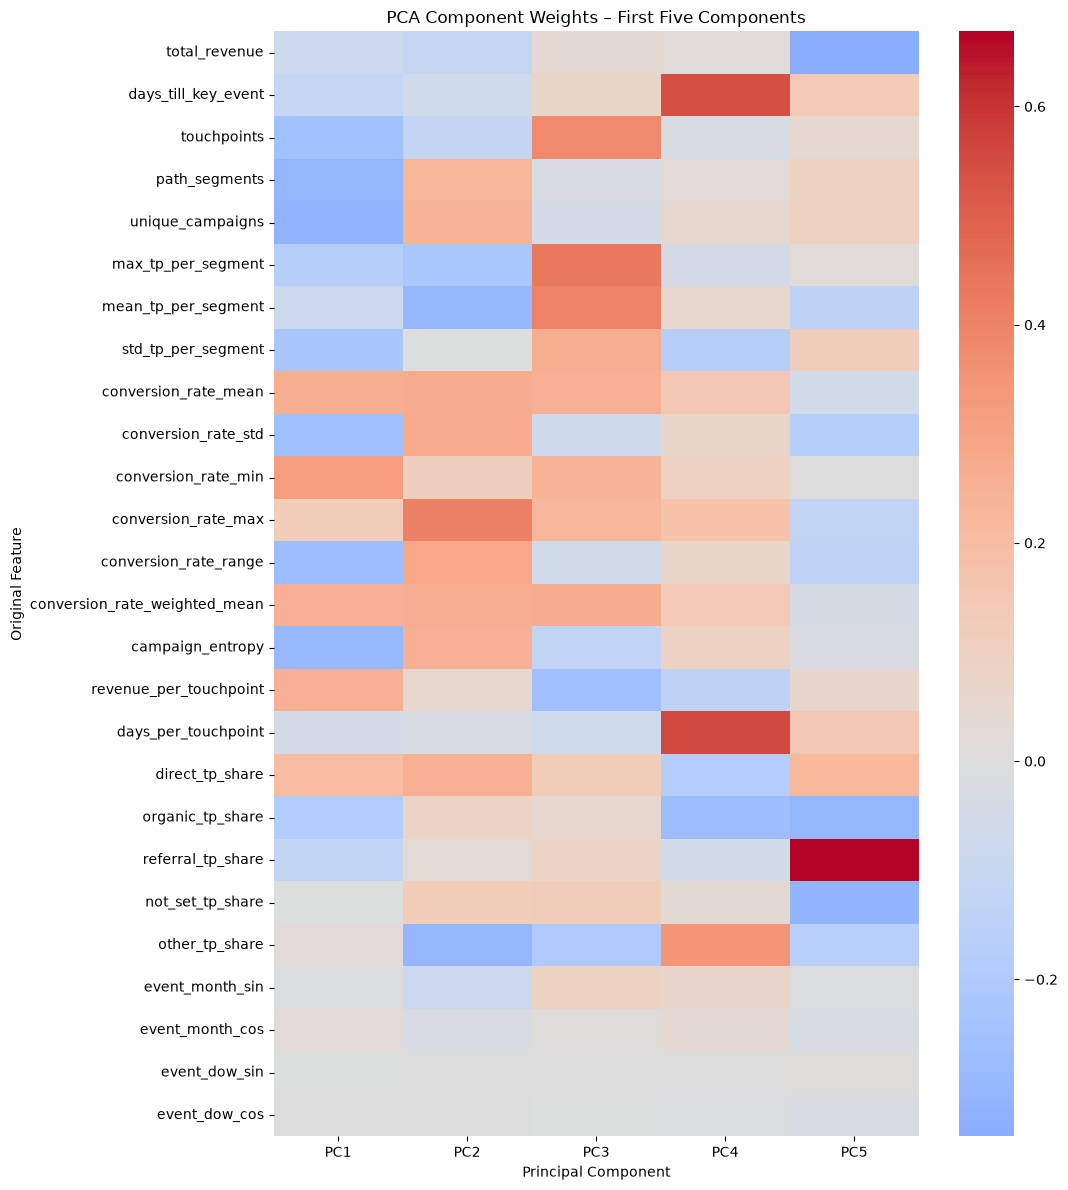

In [22]:
plt.figure(
    figsize=(11, 12)
)

sns.heatmap(
    component_weights[
        ["PC1", "PC2", "PC3", "PC4", "PC5"]
    ],
    center=0,
    cmap="coolwarm",
    annot=False
)

plt.title(
    "PCA Component Weights – First Five Components"
)

plt.xlabel(
    "Principal Component"
)

plt.ylabel(
    "Original Feature"
)

plt.tight_layout()
plt.show()

### 3.1.3 Interpretation of the Major Principal Components

The principal-component coefficients indicate which original variables contribute most strongly to each direction.

Because the sign of a PCA eigenvector is arbitrary, interpretation should focus primarily on the **magnitude and relative pattern of the weights**, rather than treating a positive or negative sign as an intrinsic property of a component.

#### PC1 – Campaign Complexity and Conversion Structure

PC1 explains approximately **26.2%** of the total variance.

Its major contributors include:

- minimum conversion rate,
- number of unique campaigns,
- number of path segments,
- campaign entropy,
- conversion-rate range,
- conversion-rate standard deviation,
- mean conversion rate,
- and weighted mean conversion rate.

PC1 therefore captures a broad contrast involving **journey/campaign complexity and conversion behavior**.

The fact that several strongly correlated variables contribute to the same component illustrates how PCA compresses redundant information.

#### PC2 – Conversion Level, Traffic Composition, and Segment Intensity

PC2 explains approximately **13.2%** of the variance.

Important contributors include:

- maximum conversion rate,
- `other` traffic-source share,
- mean touchpoints per segment,
- conversion-rate range and standard deviation,
- mean conversion rate,
- weighted conversion rate,
- and direct traffic share.

This component reflects another aspect of the relationship between **traffic-source composition, conversion characteristics, and the concentration of interactions within journey segments**.

#### PC3 – Touchpoint Intensity and Journey Activity

PC3 explains approximately **12.2%** of the variance.

Its strongest contributors include:

- maximum touchpoints per segment,
- mean touchpoints per segment,
- total touchpoints,
- touchpoint variability,
- mean and weighted conversion rates,
- and revenue per touchpoint.

PC3 can therefore be interpreted primarily as a dimension of **journey interaction intensity**.

#### PC4 – Journey Duration

PC4 explains approximately **8.8%** of the variance.

Its two dominant contributors are:

- `days_per_touchpoint`,
- `days_till_key_event`.

Together, these variables contribute most of the direction of PC4.

This makes PC4 particularly interpretable as a **time-to-conversion / journey-duration dimension**.

#### PC5 – Traffic-Source Mix and Revenue

PC5 is dominated by the referral traffic share, with additional contributions from:

- total revenue,
- `(not set)` traffic share,
- organic traffic share,
- direct traffic share,
- and conversion-rate variation.

This component therefore captures a more specific combination of **traffic-source composition and economic behavior**.

Later components explain progressively smaller fractions of the total variance and are generally more difficult to interpret individually.

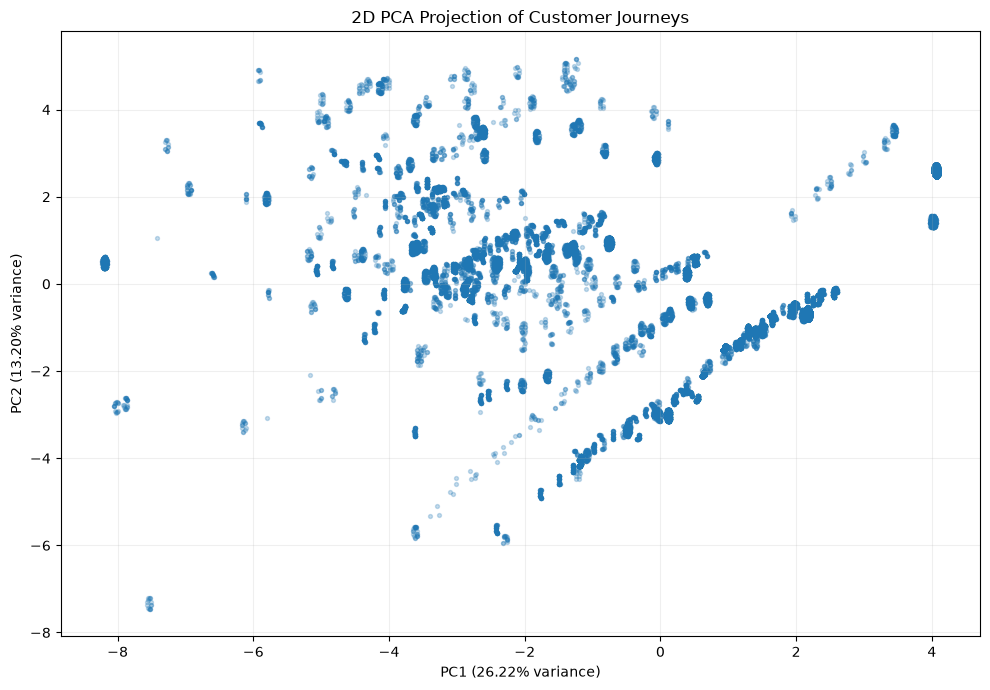

Variance retained in the 2D projection: 39.41%
Variance not represented in 2D: 60.59%


In [23]:
pca_projection = pd.DataFrame(
    X_pca_full[:, :3],
    index=X_pca_input.index,
    columns=[
        "PC1",
        "PC2",
        "PC3"
    ]
)

# PCA is fitted on the complete dataset.
# Sampling is used only to make the visualization readable
# and faster to render.
plot_2d = pca_projection.sample(
    n=min(
        25000,
        len(pca_projection)
    ),
    random_state=42
)

plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    plot_2d["PC1"],
    plot_2d["PC2"],
    s=8,
    alpha=0.25
)

plt.xlabel(
    f"PC1 ({explained_variance_ratio[0] * 100:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({explained_variance_ratio[1] * 100:.2f}% variance)"
)

plt.title(
    "2D PCA Projection of Customer Journeys"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

print(
    f"Variance retained in the 2D projection: "
    f"{cumulative_explained_variance[1] * 100:.2f}%"
)

print(
    f"Variance not represented in 2D: "
    f"{(1 - cumulative_explained_variance[1]) * 100:.2f}%"
)

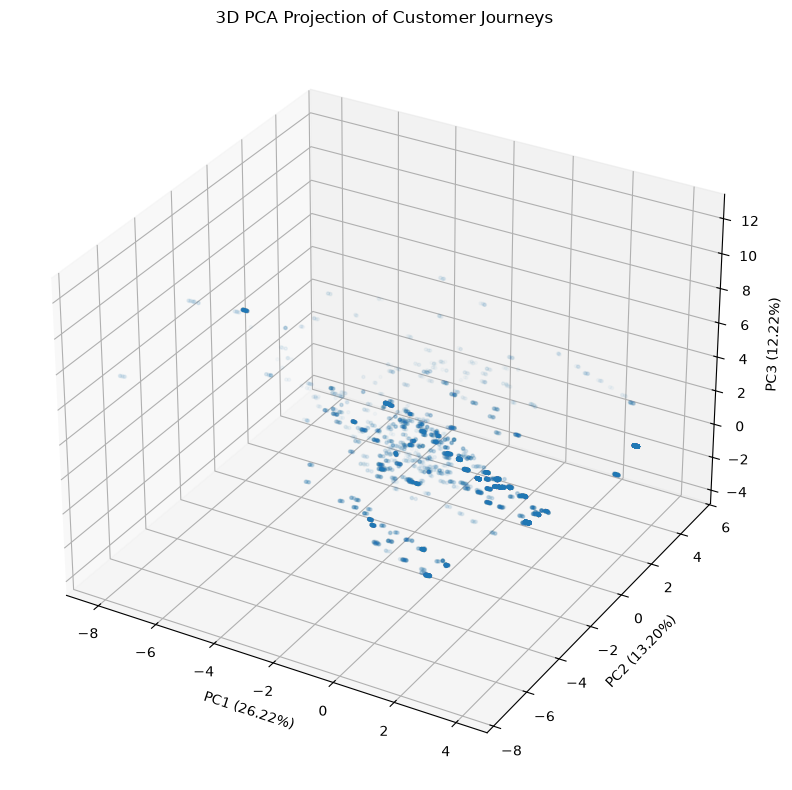

Variance retained in the 3D projection: 51.64%
Variance not represented in 3D: 48.36%


In [24]:
from mpl_toolkits.mplot3d import Axes3D

plot_3d = pca_projection.sample(
    n=min(
        15000,
        len(pca_projection)
    ),
    random_state=42
)

fig = plt.figure(
    figsize=(11, 8)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.scatter(
    plot_3d["PC1"],
    plot_3d["PC2"],
    plot_3d["PC3"],
    s=5,
    alpha=0.20
)

ax.set_xlabel(
    f"PC1 ({explained_variance_ratio[0] * 100:.2f}%)"
)

ax.set_ylabel(
    f"PC2 ({explained_variance_ratio[1] * 100:.2f}%)"
)

ax.set_zlabel(
    f"PC3 ({explained_variance_ratio[2] * 100:.2f}%)"
)

ax.set_title(
    "3D PCA Projection of Customer Journeys"
)

plt.tight_layout()
plt.show()

print(
    f"Variance retained in the 3D projection: "
    f"{cumulative_explained_variance[2] * 100:.2f}%"
)

print(
    f"Variance not represented in 3D: "
    f"{(1 - cumulative_explained_variance[2]) * 100:.2f}%"
)

### 3.1.4 Two-Dimensional and Three-Dimensional Structure

The 2D PCA projection retains approximately **39.4%** of the original standardized variance.

Adding PC3 increases the retained variance to approximately **51.6%**.

The projections reveal visible structure, including dense regions, branches, and bands of observations. However, these patterns should **not automatically be interpreted as true clusters**.

Several of the engineered features are discrete, bounded, or derived from campaign categories. Such variables can naturally produce bands or repeated geometric structures in a PCA projection.

Furthermore, almost 61% of the variance is absent from the 2D projection and approximately 48% is absent even from the 3D projection.

Consequently, two points that appear close together in the visualization may still differ substantially along dimensions that are not displayed.

Likewise, groups that visually overlap in two dimensions may be separable in higher-dimensional space.

The PCA plots should therefore be used primarily as **visual summaries** and later as a way to visualize clustering results, rather than as proof that a specific cluster structure exists.

In [25]:
rng = np.random.default_rng(
    42
)

stability_results = []

n_repeats = 5
sample_fraction = 0.70

for repeat in range(
    1,
    n_repeats + 1
):

    sample_positions = rng.choice(
        len(X_pca_input),
        size=int(
            sample_fraction *
            len(X_pca_input)
        ),
        replace=False
    )

    X_subsample = (
        X_pca_input.iloc[
            sample_positions
        ]
    )

    subsample_scaler = StandardScaler()

    X_subsample_scaled = (
        subsample_scaler.fit_transform(
            X_subsample
        )
    )

    subsample_pca = PCA(
        svd_solver="full"
    )

    subsample_pca.fit(
        X_subsample_scaled
    )

    subsample_cumulative = np.cumsum(
        subsample_pca.explained_variance_ratio_
    )

    result = {
        "Repeat": repeat,
        "PC1 Variance (%)":
            subsample_pca.explained_variance_ratio_[0] * 100,
        "PC2 Variance (%)":
            subsample_pca.explained_variance_ratio_[1] * 100,
        "PC3 Variance (%)":
            subsample_pca.explained_variance_ratio_[2] * 100,
        "Cumulative 9 PCs (%)":
            subsample_cumulative[8] * 100,
        "Cumulative 12 PCs (%)":
            subsample_cumulative[11] * 100,
        "Cumulative 14 PCs (%)":
            subsample_cumulative[13] * 100
    }

    # PCA component signs may flip without changing the solution.
    # Absolute cosine similarity removes that sign ambiguity.
    for component_index in range(5):

        cosine_similarity = abs(
            np.dot(
                subsample_pca.components_[
                    component_index
                ],
                pca_full.components_[
                    component_index
                ]
            )
        )

        result[
            f"PC{component_index + 1} "
            "Direction Similarity"
        ] = cosine_similarity

    stability_results.append(
        result
    )

stability_df = pd.DataFrame(
    stability_results
)

display(
    stability_df.round(4)
)

print("\nMean and standard deviation across subsamples:")

display(
    stability_df
    .drop(columns="Repeat")
    .agg(["mean", "std"])
    .round(5)
)

,Repeat,PC1 Variance (%),PC2 Variance (%),PC3 Variance (%),Cumulative 9 PCs (%),Cumulative 12 PCs (%),Cumulative 14 PCs (%),PC1 Direction Similarity,PC2 Direction Similarity,PC3 Direction Similarity,PC4 Direction Similarity,PC5 Direction Similarity
0,1,26.1824,13.1922,12.2255,81.0671,91.5985,96.0939,1.0000,1.0000,0.9999,0.9999,0.9995
1,2,26.2173,13.1392,12.2203,81.0753,91.5941,96.0737,1.0000,0.9997,0.9996,0.9999,0.9990
2,3,26.2205,13.1704,12.2213,81.0868,91.6142,96.0865,1.0000,0.9999,0.9999,0.9999,0.9996
3,4,26.2190,13.2032,12.2174,81.1338,91.6213,96.1053,1.0000,0.9998,0.9998,1.0000,0.9995
4,5,26.1951,13.1691,12.2692,81.0935,91.6008,96.0864,1.0000,0.9996,0.9996,0.9999,0.9994



Mean and standard deviation across subsamples:


,PC1 Variance (%),PC2 Variance (%),PC3 Variance (%),Cumulative 9 PCs (%),Cumulative 12 PCs (%),Cumulative 14 PCs (%),PC1 Direction Similarity,PC2 Direction Similarity,PC3 Direction Similarity,PC4 Direction Similarity,PC5 Direction Similarity
mean,26.2069,13.1748,12.2308,81.0913,91.6058,96.0892,1.0000,0.9998,0.9998,0.9999,0.9994
std,0.0172,0.0246,0.0217,0.0259,0.0115,0.0116,0.0000,0.0001,0.0001,0.0000,0.0003


### 3.1.5 Stability

PCA was repeated on five independent random subsamples, each containing 70% of the journeys.

The explained-variance ratios remain almost unchanged across the subsamples.

The directions of the first five components also show extremely high absolute cosine similarity with the full-data PCA solution, approximately **0.999 or higher**.

This indicates that the major PCA structure is highly stable with respect to random changes in the sample.

The strong stability is partly supported by the large number of observations relative to the number of variables: the dataset contains more than 93,000 journeys but only 26 primary PCA features.

Stability of PCA does not, however, imply that any future clustering solution will necessarily be equally stable. PCA measures variance structure, whereas clustering introduces additional assumptions about groups, distances, densities, and hyperparameters.

In [26]:
target_variance = 0.90

n_components_selected = (
    np.argmax(
        cumulative_explained_variance
        >= target_variance
    )
    + 1
)

X_pca_selected = pd.DataFrame(
    X_pca_full[
        :,
        :n_components_selected
    ],
    index=X_pca_input.index,
    columns=[
        f"PC{i}"
        for i in range(
            1,
            n_components_selected + 1
        )
    ]
)

retained_variance = (
    cumulative_explained_variance[
        n_components_selected - 1
    ]
)

print(
    f"Selected PCA representation: "
    f"{n_components_selected} components"
)

print(
    f"Original dimensionality: "
    f"{X_pca_input.shape[1]}"
)

print(
    f"Reduced dimensionality: "
    f"{X_pca_selected.shape[1]}"
)

print(
    f"Dimensionality reduction: "
    f"{(
        1 -
        X_pca_selected.shape[1]
        / X_pca_input.shape[1]
    ) * 100:.2f}%"
)

print(
    f"Variance retained: "
    f"{retained_variance * 100:.2f}%"
)

print(
    f"Variance lost: "
    f"{(1 - retained_variance) * 100:.2f}%"
)

display(
    X_pca_selected.head()
)

Selected PCA representation: 12 components
Original dimensionality: 26
Reduced dimensionality: 12
Dimensionality reduction: 53.85%
Variance retained: 91.61%
Variance lost: 8.39%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
Path ID,,,,,,,,,,,,
842,4.0578,2.4756,1.3518,-1.1126,0.7807,1.1889,-0.4834,-1.1438,0.2857,1.2430,0.8711,0.1333
843,4.0824,2.6877,1.1113,-1.2520,0.7808,0.5400,0.5744,0.8860,-0.8942,-1.1517,-0.3916,-0.5223
844,4.0737,2.4758,1.3373,-1.0996,0.7369,1.4059,-0.6238,-0.4751,-1.3509,-0.2274,0.9681,0.0256
845,4.0439,2.5069,1.3270,-1.1534,0.8025,0.7888,-0.3787,-1.5567,0.2863,1.2567,0.4758,0.2184
846,4.0845,2.6891,1.1122,-1.2618,0.7625,0.6407,0.4896,0.7745,-1.0370,1.0479,-0.3411,-0.6072


In [27]:
import time

start_time = time.perf_counter()

benchmark_scaled = StandardScaler().fit_transform(
    X_pca_input
)

benchmark_pca = PCA(
    svd_solver="full"
)

benchmark_pca.fit_transform(
    benchmark_scaled
)

elapsed_time = (
    time.perf_counter()
    - start_time
)

scaled_memory_mb = (
    X_scaled.nbytes
    / (1024 ** 2)
)

print(
    f"Standardization + full PCA runtime: "
    f"{elapsed_time:.4f} seconds"
)

print(
    f"Approximate memory used by the "
    f"standardized matrix: "
    f"{scaled_memory_mb:.2f} MB"
)

print(
    f"Observations: "
    f"{X_pca_input.shape[0]:,}"
)

print(
    f"Features: "
    f"{X_pca_input.shape[1]}"
)

Standardization + full PCA runtime: 0.0624 seconds
Approximate memory used by the standardized matrix: 18.57 MB
Observations: 93,629
Features: 26


### 3.1.6 Critical Discussion of the PCA Representation

#### How Many Components Are Needed?

There is no unique correct number of components because dimensionality reduction involves a trade-off between compression and information preservation.

For this analysis:

- 9 components retain approximately 81% of the variance.
- 12 components retain approximately 92%.
- 14 components retain approximately 96%.

A **12-component representation** is selected as the primary reduced representation because it removes approximately 54% of the original dimensions while retaining more than 90% of the variance.

The 14-component version could be preferred when preserving additional information is more important than dimensionality reduction.

#### Information Loss

Reducing the data to 12 components removes approximately **8.4% of the standardized variance**.

In comparison:

- a 2D visualization loses approximately 60.6%,
- a 3D visualization loses approximately 48.4%.

Therefore, the low-dimensional visualizations are useful for interpretation but should not replace the higher-dimensional representation in quantitative analysis.

#### Correlated Variables and PCA

The original feature space contains substantial correlation and redundancy.

Strongly related variables tend to contribute to the same principal components. PCA combines these overlapping signals into orthogonal directions.

This prevents multiple highly correlated variables from being interpreted as completely independent dimensions of the customer journey.

The analysis also identified two exact linear dependencies, reducing the numerical rank of the 26-feature matrix to 24.

#### Global vs Local Structure

PCA is fundamentally a **global linear method**.

It identifies directions that maximize variance across the entire dataset. It does not explicitly attempt to preserve local neighborhoods, nonlinear manifolds, or local density.

Consequently, PCA may preserve the broad global geometry of the customer journeys while distorting smaller local structures.

This distinction will be important for algorithms such as DBSCAN and LOF, whose results depend strongly on local distances and neighborhood density.

#### Cluster Separation

Visible groups, branches, or dense regions appear in the PCA projections, but PCA itself does not prove that meaningful clusters exist.

PCA maximizes variance rather than cluster separation.

Furthermore, the 2D and 3D projections discard a substantial amount of information.

Therefore, clustering quality will later be assessed using clustering algorithms and quantitative metrics in addition to visualization on PCA coordinates.

#### Stability

Repeated PCA fitting on random 70% subsamples produces almost identical explained-variance profiles and highly similar directions for the major components.

This indicates that the main PCA structure is stable and is unlikely to be caused by a small accidental subset of observations.

#### Computational Cost

The dataset has many observations but relatively few features.

For a matrix with \(n\) observations and \(p\) variables, with \(n \gg p\), classical PCA is computationally manageable because the dimensional component of the calculation is relatively small.

The measured runtime confirms that PCA is practical for this dataset on an ordinary computer.

Reducing the representation from 26 to 12 dimensions can also reduce the computational cost of later distance calculations and clustering methods.

This can become particularly useful for methods such as hierarchical clustering or neighborhood-based anomaly detection.

#### Interpretability

The original variables are directly interpretable in business terms, whereas principal components are combinations of multiple original variables.

The first components remain reasonably interpretable because they are dominated by coherent groups of related variables, such as journey complexity, touchpoint intensity, duration, and traffic composition.

Later components become progressively more difficult to explain.

Therefore, PCA improves compactness but introduces an interpretability cost.

#### Redundancy

The original feature matrix contains substantial redundancy, including both strong correlations and exact linear dependencies.

The PCA results show that most of the standardized variance can be represented using considerably fewer than 26 dimensions.

This confirms that the original representation contains overlapping information.

### Does PCA Provide a More Effective Representation?

The answer depends on the purpose.

For visual interpretation, the 2D and 3D PCA projections are useful summaries but are **not sufficiently complete representations** because they discard too much variance.

For computational analysis, the 12-dimensional PCA representation provides an effective compromise: it removes more than half of the dimensions while preserving approximately 91.6% of the variance and eliminating correlated coordinate directions.

However, PCA should not completely replace the original feature space.

The original standardized variables remain important because:

- they are more interpretable,
- PCA may distort local distances,
- and some low-variance dimensions may still contain useful information for anomaly detection.

Therefore, later analyses can compare results obtained from the original standardized space with results obtained from the reduced PCA space rather than assuming in advance that one representation is always superior.

### 3.1.7 PCA Conclusions

The PCA analysis produced the following main conclusions:

1. The journey-level feature space contains substantial redundancy and correlation.

2. The first principal component explains approximately **26.2%** of the total standardized variance.

3. The first two and three components retain approximately **39.4%** and **51.6%**, respectively. They are therefore useful for visualization but not sufficient to represent the complete dataset.

4. **12 principal components retain approximately 91.6% of the variance**, reducing the dimensionality from 26 to 12.

5. A more conservative 14-component representation retains approximately 96.1%.

6. Two dimensions contain essentially zero independent variance because of exact linear relationships between engineered features.

7. The major components have meaningful interpretations related to:
   - campaign and conversion structure,
   - traffic-source composition,
   - touchpoint intensity,
   - journey duration,
   - and economic behavior.

8. PCA is highly stable across large random subsamples of the dataset.

9. PCA provides a useful global and computationally efficient representation, but it does not guarantee preservation of local structure or meaningful cluster separation.

10. The **12-component PCA representation (`X_pca_selected`)** will be retained for comparison with the original standardized feature space in subsequent unsupervised-learning analyses.

Overall, PCA provides a meaningful reduction of the dataset while also revealing the degree of redundancy and the major dimensions of variation in customer-journey behavior.

## 4. Clustering Analysis

The purpose of clustering is to investigate whether the customer journeys naturally form groups with similar behavioral characteristics.

Three substantially different clustering approaches are compared:

1. **K-Means** – a centroid-based method that favors compact, approximately spherical clusters.
2. **DBSCAN** – a density-based method that can discover irregularly shaped dense regions and explicitly identify sparse observations as noise.
3. **Agglomerative Hierarchical Clustering** – a hierarchical method that progressively merges similar observations.

The algorithms make different assumptions about what constitutes a cluster. Therefore, disagreement between them is not necessarily a failure; it can reveal important properties of the geometry of the dataset.

The primary clustering space is the **12-dimensional PCA representation** created in the previous section. It retains approximately 91.6% of the standardized variance while reducing the dimensionality from 26 to 12.

This reduces redundancy and computational cost while preserving most of the global structure.

For scalability:

- K-Means is fitted to the complete set of 93,629 journeys.
- DBSCAN and classical agglomerative clustering are evaluated on a fixed reproducible sample of 10,000 journeys.
- All three methods are additionally compared on that same sample.

This sampling decision is explicitly reported because computational scalability is itself an important limitation of clustering methods.

In [28]:
from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)

from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

if "X_pca_selected" not in globals():
    raise NameError(
        "X_pca_selected is not defined. "
        "Run the notebook from the beginning."
    )

# Complete 12-dimensional PCA clustering space.
X_cluster_space = X_pca_selected.to_numpy()

# Fixed sample used for computationally expensive methods
# and for fair comparison between algorithms.
rng = np.random.default_rng(42)

cluster_sample_positions = np.sort(
    rng.choice(
        len(X_cluster_space),
        size=min(10000, len(X_cluster_space)),
        replace=False
    )
)

X_cluster_sample = (
    X_cluster_space[
        cluster_sample_positions
    ]
)

cluster_sample_paths = (
    X_pca_selected.index[
        cluster_sample_positions
    ]
)

print(
    f"Complete clustering dataset: "
    f"{len(X_cluster_space):,} journeys"
)

print(
    f"Common comparison sample: "
    f"{len(X_cluster_sample):,} journeys"
)

print(
    f"Clustering dimensions: "
    f"{X_cluster_space.shape[1]}"
)

Complete clustering dataset: 93,629 journeys
Common comparison sample: 10,000 journeys
Clustering dimensions: 12


In [29]:
def clustering_quality(
    X,
    labels,
    ignore_noise=False,
    silhouette_sample_size=3000
):
    """
    Calculate several clustering-quality metrics.

    For DBSCAN, label -1 can optionally be excluded because it
    represents noise rather than an ordinary cluster.
    """

    labels = np.asarray(labels)

    mask = np.ones(
        len(labels),
        dtype=bool
    )

    if ignore_noise:
        mask = labels != -1

    X_eval = X[mask]
    labels_eval = labels[mask]

    unique_clusters = np.unique(
        labels_eval
    )

    if len(unique_clusters) < 2:
        return {
            "Silhouette": np.nan,
            "Calinski-Harabasz": np.nan,
            "Davies-Bouldin": np.nan,
            "Global Avg Variance": np.nan,
            "Weighted Within Avg Variance": np.nan,
            "Within / Global Variance": np.nan
        }

    silhouette = silhouette_score(
        X_eval,
        labels_eval,
        sample_size=min(
            silhouette_sample_size,
            len(X_eval)
        ),
        random_state=42
    )

    ch = calinski_harabasz_score(
        X_eval,
        labels_eval
    )

    db = davies_bouldin_score(
        X_eval,
        labels_eval
    )

    global_variance = (
        np.var(
            X_eval,
            axis=0,
            ddof=0
        ).mean()
    )

    weighted_within_variance = 0

    for cluster in unique_clusters:

        cluster_mask = (
            labels_eval == cluster
        )

        cluster_size = (
            cluster_mask.sum()
        )

        cluster_variance = (
            np.var(
                X_eval[cluster_mask],
                axis=0,
                ddof=0
            ).mean()
        )

        weighted_within_variance += (
            cluster_size
            / len(X_eval)
            * cluster_variance
        )

    return {
        "Silhouette": silhouette,
        "Calinski-Harabasz": ch,
        "Davies-Bouldin": db,
        "Global Avg Variance": global_variance,
        "Weighted Within Avg Variance":
            weighted_within_variance,
        "Within / Global Variance":
            weighted_within_variance
            / global_variance
    }


def cluster_variance_table(
    X,
    labels,
    exclude_noise=False
):
    """
    Compare the average variance inside every cluster
    with the global average variance.
    """

    labels = np.asarray(labels)

    if exclude_noise:
        global_mask = labels != -1
    else:
        global_mask = np.ones(
            len(labels),
            dtype=bool
        )

    global_variance = (
        np.var(
            X[global_mask],
            axis=0,
            ddof=0
        ).mean()
    )

    rows = []

    for cluster in sorted(
        np.unique(labels)
    ):

        if (
            exclude_noise
            and cluster == -1
        ):
            continue

        mask = labels == cluster

        cluster_variance = (
            np.var(
                X[mask],
                axis=0,
                ddof=0
            ).mean()
        )

        rows.append({
            "Cluster": cluster,
            "Size": int(mask.sum()),
            "Average Within-Cluster Variance":
                cluster_variance,
            "Global Average Variance":
                global_variance,
            "Cluster / Global Variance":
                cluster_variance
                / global_variance
        })

    return pd.DataFrame(rows)

### 4.1 K-Means Clustering

K-Means partitions observations into \(K\) clusters by assigning each observation to the nearest cluster centroid.

Its objective is to minimize the within-cluster sum of squared Euclidean distances:

\[
J =
\sum_{k=1}^{K}
\sum_{x_i \in C_k}
\|x_i-\mu_k\|^2
\]

where \(C_k\) is cluster \(k\) and \(\mu_k\) is its centroid.

The algorithm repeatedly performs two steps:

1. assign every observation to its closest centroid,
2. recompute each centroid as the mean of the observations assigned to it.

The process continues until the assignments or centroids stabilize.

#### Main Assumptions

K-Means works best when:

- clusters are reasonably compact,
- Euclidean distance is meaningful,
- clusters have approximately centroid-like geometry,
- and extremely different cluster densities or highly irregular cluster shapes are absent.

#### Strengths

- Computationally efficient and scalable.
- Easy to understand and reproduce.
- Works well with large datasets.
- Produces explicit cluster centers.
- Has a direct relationship with within-cluster variance.

#### Weaknesses

- The number of clusters \(K\) must be selected in advance.
- Results can depend on initialization.
- Sensitive to scaling and extreme observations.
- Prefers approximately spherical clusters.
- Cannot explicitly identify noise.
- May divide a continuous distribution into artificial groups even when no natural clusters exist.

In [30]:
kmeans_results = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(
        X_cluster_space
    )

    quality = clustering_quality(
        X_cluster_space,
        labels,
        silhouette_sample_size=3000
    )

    kmeans_results.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette":
            quality["Silhouette"],
        "Calinski-Harabasz":
            quality["Calinski-Harabasz"],
        "Davies-Bouldin":
            quality["Davies-Bouldin"],
        "Within / Global Variance":
            quality["Within / Global Variance"]
    })

kmeans_selection = pd.DataFrame(
    kmeans_results
)

display(
    kmeans_selection.round(4)
)

best_k_by_silhouette = int(
    kmeans_selection.loc[
        kmeans_selection[
            "Silhouette"
        ].idxmax(),
        "K"
    ]
)

# K=4 is retained as the final solution because the
# difference in Silhouette relative to K=5 is very small,
# while the four-cluster solution is more parsimonious and
# has stronger Calinski-Harabasz and Davies-Bouldin results.
selected_k = 4

best_silhouette = float(
    kmeans_selection.loc[
        kmeans_selection["K"]
        == best_k_by_silhouette,
        "Silhouette"
    ].iloc[0]
)

selected_silhouette = float(
    kmeans_selection.loc[
        kmeans_selection["K"]
        == selected_k,
        "Silhouette"
    ].iloc[0]
)

print(
    f"Highest tested Silhouette score: "
    f"K = {best_k_by_silhouette} "
    f"({best_silhouette:.4f})"
)

print(
    f"Selected K for the final model: "
    f"K = {selected_k} "
    f"({selected_silhouette:.4f})"
)

print(
    f"Silhouette difference: "
    f"{best_silhouette - selected_silhouette:.4f}"
)

,K,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin,Within / Global Variance
0,2,"1,747,391.6698",0.2385,"25,870.7449",1.7084,0.7835
1,3,"1,503,719.0924",0.2449,"22,617.2333",1.5148,0.6742
2,4,"1,364,257.6851",0.2485,"19,809.6250",1.5335,0.6117
3,5,"1,240,342.1439",0.2525,"18,679.7459",1.5725,0.5562
4,6,"1,157,222.5778",0.2102,"17,361.8875",1.5850,0.5189
5,7,"1,069,017.1679",0.2197,"16,949.3238",1.5672,0.4793
6,8,"990,347.7183",0.2306,"16,744.2862",1.4639,0.4441
7,9,"939,830.2123",0.2182,"16,067.6427",1.3827,0.4214
8,10,"901,209.5902",0.2162,"15,340.0246",1.4212,0.4041


Highest tested Silhouette score: K = 5 (0.2525)
Selected K for the final model: K = 4 (0.2485)
Silhouette difference: 0.0040


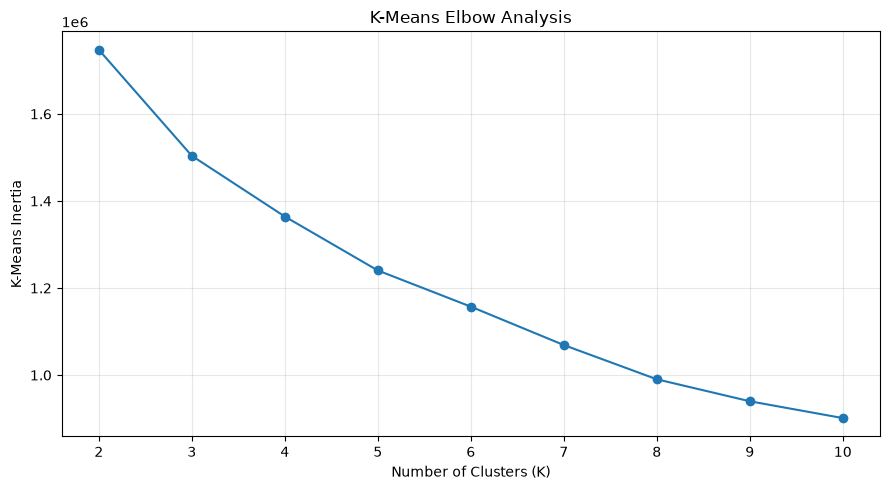

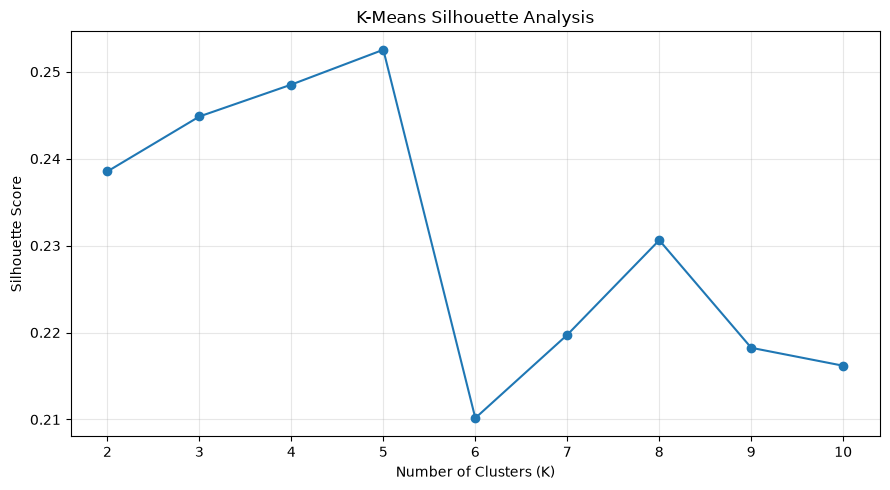

In [31]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    kmeans_selection["K"],
    kmeans_selection["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("K-Means Inertia")
plt.title("K-Means Elbow Analysis")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


plt.figure(
    figsize=(9, 5)
)

plt.plot(
    kmeans_selection["K"],
    kmeans_selection["Silhouette"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Analysis")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Selection of K

Several values of \(K\) were evaluated instead of selecting the number of clusters arbitrarily.

The analysis considered:

- inertia,
- Silhouette score,
- Calinski–Harabasz score,
- Davies–Bouldin index,
- and within-cluster variance relative to global variance.

The Silhouette score is defined conceptually using:

- \(a(i)\): the average distance between observation \(i\) and observations in its own cluster,
- \(b(i)\): the smallest average distance between observation \(i\) and observations in another cluster.

\[
s(i)=
\frac{b(i)-a(i)}
{\max(a(i),b(i))}
\]

Values closer to 1 indicate better separation, values close to zero indicate overlapping clusters, and negative values indicate potentially inappropriate assignments.

In the tested range, **K = 5 produces the highest sampled Silhouette score (approximately 0.2525)**, while **K = 4 produces a very similar score (approximately 0.2485)**.

The difference is only about 0.004.

Importantly, the four-cluster solution also has a higher Calinski–Harabasz score and a lower Davies–Bouldin index than the five-cluster solution, while providing a simpler and more interpretable segmentation.

Therefore, **K = 4 is selected as a parsimonious compromise between separation, compactness, and real-world interpretability rather than simply selecting the value that maximizes one metric**.

The moderate Silhouette values are also important. They suggest that the customer journeys do not form perfectly separated natural groups, and the selected clusters should therefore be interpreted as useful behavioral summaries rather than objectively correct customer classes.

In [32]:
kmeans_model = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=20
)

kmeans_labels = (
    kmeans_model.fit_predict(
        X_cluster_space
    )
)

kmeans_counts = (
    pd.Series(
        kmeans_labels
    )
    .value_counts()
    .sort_index()
    .rename("Journeys")
)

kmeans_counts = pd.DataFrame(
    kmeans_counts
)

kmeans_counts["Percentage (%)"] = (
    kmeans_counts["Journeys"]
    / len(kmeans_labels)
    * 100
)

display(
    kmeans_counts.round(2)
)

display(
    cluster_variance_table(
        X_cluster_space,
        kmeans_labels
    ).round(4)
)

,Journeys,Percentage (%)
0,28920,30.8900
1,46135,49.2700
2,7548,8.0600
3,11026,11.7800


,Cluster,Size,Average Within-Cluster Variance,Global Average Variance,Cluster / Global Variance
0,0,28920,1.2275,1.9850,0.6184
1,1,46135,1.0005,1.9850,0.5041
2,2,7548,3.0338,1.9850,1.5284
3,3,11026,0.8279,1.9850,0.4171


In [33]:
profile_features = [
    "total_revenue",
    "days_till_key_event",
    "touchpoints",
    "path_segments",
    "unique_campaigns",
    "conversion_rate_mean",
    "campaign_entropy",
    "revenue_per_touchpoint",
    "direct_tp_share",
    "organic_tp_share",
    "referral_tp_share",
    "other_tp_share"
]

kmeans_profiles = (
    journey_df
    .loc[
        X_pca_selected.index,
        profile_features
    ]
    .copy()
)

kmeans_profiles["Cluster"] = (
    kmeans_labels
)

kmeans_mean_profiles = (
    kmeans_profiles
    .groupby("Cluster")
    [profile_features]
    .mean()
)

kmeans_median_profiles = (
    kmeans_profiles
    .groupby("Cluster")
    [profile_features]
    .median()
)

print("Mean cluster profiles:")
display(
    kmeans_mean_profiles.round(3)
)

print("Median cluster profiles:")
display(
    kmeans_median_profiles.round(3)
)

Mean cluster profiles:


,total_revenue,days_till_key_event,touchpoints,path_segments,unique_campaigns,conversion_rate_mean,campaign_entropy,revenue_per_touchpoint,direct_tp_share,organic_tp_share,referral_tp_share,other_tp_share
Cluster,,,,,,,,,,,,
0,189.2860,23.9030,3.7470,2.4840,2.3220,0.0250,0.7620,60.5250,0.0000,0.3230,0.0660,0.5930
1,187.7880,20.6490,2.6440,1.0820,1.0820,0.0280,0.0550,104.6370,0.0000,0.0280,0.0200,0.9520
2,211.9830,28.2280,11.7750,2.2840,2.0870,0.0250,0.4200,19.4400,0.0000,0.4140,0.1640,0.4110
3,147.9860,0.4200,1.0750,1.0000,1.0000,0.0350,0.0000,145.1380,0.8770,0.0000,0.0000,0.0850


Median cluster profiles:


,total_revenue,days_till_key_event,touchpoints,path_segments,unique_campaigns,conversion_rate_mean,campaign_entropy,revenue_per_touchpoint,direct_tp_share,organic_tp_share,referral_tp_share,other_tp_share
Cluster,,,,,,,,,,,,
0,190.1220,14.0000,3.0000,2.0000,2.0000,0.0270,0.6930,62.9580,0.0000,0.3330,0.0000,0.5000
1,190.5350,8.0000,2.0000,1.0000,1.0000,0.0300,-0.0000,94.7540,0.0000,0.0000,0.0000,1.0000
2,190.3860,24.0000,10.0000,2.0000,2.0000,0.0250,0.5300,19.0390,0.0000,0.6000,0.0000,0.2500
3,144.4460,0.0000,1.0000,1.0000,1.0000,0.0350,-0.0000,144.4460,1.0000,0.0000,0.0000,0.0000


In [34]:
remaining_clusters = set(
    kmeans_mean_profiles.index
)

direct_cluster = (
    kmeans_mean_profiles[
        "direct_tp_share"
    ].idxmax()
)

remaining_clusters.remove(
    direct_cluster
)

high_touch_cluster = (
    kmeans_mean_profiles
    .loc[
        list(remaining_clusters),
        "touchpoints"
    ]
    .idxmax()
)

remaining_clusters.remove(
    high_touch_cluster
)

diverse_cluster = (
    kmeans_mean_profiles
    .loc[
        list(remaining_clusters),
        "campaign_entropy"
    ]
    .idxmax()
)

remaining_clusters.remove(
    diverse_cluster
)

simple_cluster = (
    list(remaining_clusters)[0]
)

kmeans_semantic_names = {
    direct_cluster:
        "Direct same-day journeys",

    high_touch_cluster:
        "High-touch complex journeys",

    diverse_cluster:
        "Multi-campaign journeys",

    simple_cluster:
        "Simple non-direct journeys"
}

print(
    "Semantic interpretation of K-Means clusters:"
)

for cluster, meaning in (
    kmeans_semantic_names.items()
):
    print(
        f"Cluster {cluster}: {meaning}"
    )

Semantic interpretation of K-Means clusters:
Cluster 3: Direct same-day journeys
Cluster 2: High-touch complex journeys
Cluster 0: Multi-campaign journeys
Cluster 1: Simple non-direct journeys


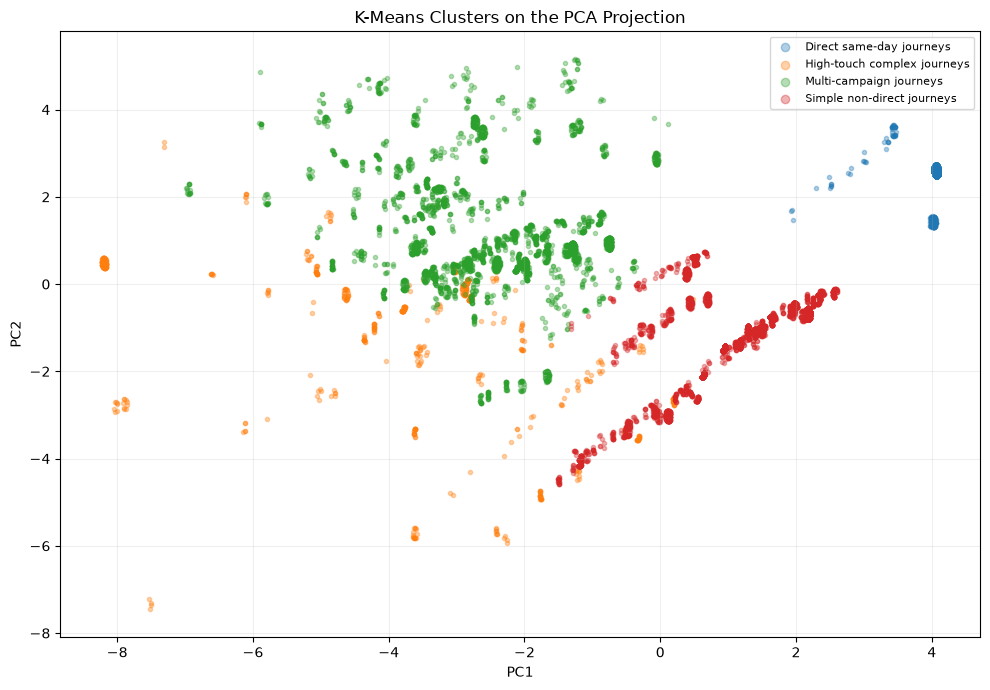

In [35]:
kmeans_plot = (
    pca_projection
    .loc[
        cluster_sample_paths
    ]
    .copy()
)

kmeans_sample_labels = (
    kmeans_model.predict(
        X_cluster_sample
    )
)

kmeans_plot["Cluster"] = [
    kmeans_semantic_names[label]
    for label in kmeans_sample_labels
]

plt.figure(
    figsize=(10, 7)
)

for cluster_name, group in (
    kmeans_plot.groupby("Cluster")
):

    plt.scatter(
        group["PC1"],
        group["PC2"],
        s=9,
        alpha=0.35,
        label=cluster_name
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "K-Means Clusters on the PCA Projection"
)

plt.legend(
    markerscale=2,
    fontsize=8
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### K-Means Interpretation

The four-cluster solution produces groups with recognizable behavioral profiles.

#### Direct Same-Day Journeys

One cluster is dominated by journeys with:

- approximately one touchpoint,
- one path segment,
- one campaign,
- almost entirely direct traffic,
- and a key event occurring on or very close to the same day.

This represents the simplest and most direct conversion path.

#### Simple Non-Direct Journeys

A much larger group contains relatively short journeys dominated by one non-direct campaign or traffic source.

These journeys have low campaign diversity and relatively few interactions.

#### Multi-Campaign Journeys

Another cluster contains journeys involving several campaign or traffic-source segments.

It has greater campaign entropy and more complex acquisition paths than the simple-journey clusters.

This group can be interpreted as customers who require interaction through several marketing channels before the key event.

#### High-Touch Complex Journeys

The smallest major K-Means cluster contains substantially more touchpoints than the others.

These journeys also tend to have lower revenue per touchpoint because the customer interacts many times before the key event.

This group may represent customers with longer or more complicated conversion processes.

### Are the K-Means Clusters Meaningful?

The clusters have plausible real-world interpretations, but they should not be treated as objectively correct customer types.

K-Means must divide every observation into one of four groups even if the underlying customer behavior forms a continuum rather than genuinely separate populations.

The moderate Silhouette score supports this caution.

### 4.2 DBSCAN

DBSCAN (**Density-Based Spatial Clustering of Applications with Noise**) defines clusters as connected regions containing sufficiently high local point density.

Two important hyperparameters control the algorithm:

- \(\varepsilon\) (`eps`) – the neighborhood radius.
- `min_samples` – the minimum number of neighboring observations required for an observation to be considered a core point.

An observation is a **core point** when its \(\varepsilon\)-neighborhood contains enough observations.

Clusters are formed by connecting density-reachable core points.

Observations that are not density-reachable from a cluster are assigned the label **-1** and treated as noise.

#### Main Assumptions

DBSCAN assumes that:

- the chosen distance measure provides a meaningful representation of similarity,
- variables have been represented on compatible scales,
- meaningful clusters correspond to relatively dense connected regions separated by lower-density areas,
- a single global neighborhood radius (`eps`) is reasonably appropriate for the dataset,
- and the selected feature representation preserves enough local structure for neighborhood relationships to remain informative.

These assumptions are important because DBSCAN can struggle when different clusters have very different densities or when distances become less meaningful in high-dimensional spaces.

The use of the 12-dimensional PCA representation reduces redundancy and computational cost, but PCA is a global linear transformation and may still alter some local neighborhood relationships.

#### Strengths

- Does not require the number of clusters in advance.
- Can discover non-spherical cluster shapes.
- Explicitly identifies sparse observations.
- Useful when clusters correspond to dense regions separated by low-density areas.

#### Weaknesses

- Highly sensitive to `eps` and `min_samples`.
- Difficult to tune in high-dimensional spaces.
- Performs poorly when different clusters have substantially different densities.
- Distance becomes less informative as dimensionality increases.
- Neighborhood searches can become computationally expensive on large datasets.

For these reasons, DBSCAN is evaluated on the fixed reproducible 10,000-journey sample.

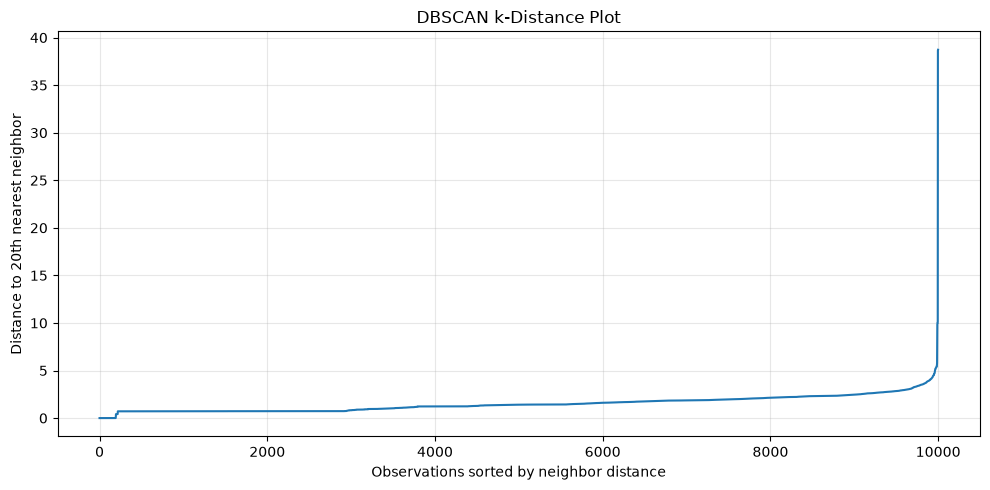

Selected k-distance quantiles:


,Distance
0.5000,1.4059
0.7500,1.9650
0.9000,2.4561
0.9500,2.8405
0.9700,3.1985
0.9900,3.9917


In [36]:
dbscan_min_samples = 20

neighbors = NearestNeighbors(
    n_neighbors=dbscan_min_samples,
    n_jobs=-1
)

neighbors.fit(
    X_cluster_sample
)

neighbor_distances, _ = (
    neighbors.kneighbors(
        X_cluster_sample
    )
)

k_distances = (
    neighbor_distances[:, -1]
)

sorted_k_distances = np.sort(
    k_distances
)

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    sorted_k_distances
)

plt.xlabel(
    "Observations sorted by neighbor distance"
)

plt.ylabel(
    f"Distance to {dbscan_min_samples}th nearest neighbor"
)

plt.title(
    "DBSCAN k-Distance Plot"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


print(
    "Selected k-distance quantiles:"
)

display(
    pd.Series(
        k_distances
    )
    .quantile(
        [
            0.50,
            0.75,
            0.90,
            0.95,
            0.97,
            0.99
        ]
    )
    .rename("Distance")
    .to_frame()
)

In [37]:
dbscan_sensitivity_results = []

eps_candidates = [
    2.3,
    2.5,
    2.7,
    2.9,
    3.1,
    3.3
]

for eps in eps_candidates:

    model = DBSCAN(
        eps=eps,
        min_samples=20,
        n_jobs=-1
    )

    labels = model.fit_predict(
        X_cluster_sample
    )

    cluster_labels = [
        label
        for label in np.unique(labels)
        if label != -1
    ]

    n_clusters = len(
        cluster_labels
    )

    noise_percentage = (
        (labels == -1).mean()
        * 100
    )

    cluster_sizes = (
        pd.Series(
            labels[
                labels != -1
            ]
        )
        .value_counts()
    )

    if len(cluster_sizes) > 0:
        largest_cluster_percentage = (
            cluster_sizes.max()
            / len(labels)
            * 100
        )
    else:
        largest_cluster_percentage = np.nan

    quality = clustering_quality(
        X_cluster_sample,
        labels,
        ignore_noise=True
    )

    dbscan_sensitivity_results.append({
        "eps": eps,
        "Clusters": n_clusters,
        "Noise (%)":
            noise_percentage,
        "Largest Cluster (%)":
            largest_cluster_percentage,
        "Silhouette":
            quality["Silhouette"],
        "Davies-Bouldin":
            quality["Davies-Bouldin"]
    })

dbscan_sensitivity = pd.DataFrame(
    dbscan_sensitivity_results
)

display(
    dbscan_sensitivity.round(4)
)

,eps,Clusters,Noise (%),Largest Cluster (%),Silhouette,Davies-Bouldin
0,2.3000,13,7.1300,75.1300,-0.0200,1.3436
1,2.5000,5,4.3100,82.3800,0.1180,1.0493
2,2.7000,6,3.3000,83.1300,0.0408,1.0440
3,2.9000,3,2.6200,86.2500,0.2353,0.8948
4,3.1000,4,1.7800,86.6800,0.2378,0.8057
5,3.3000,3,1.4900,97.1100,0.4702,0.5744


### DBSCAN Hyperparameter Selection

DBSCAN demonstrates considerably greater hyperparameter sensitivity than K-Means.

Small changes in `eps` can:

- merge previously separate dense regions,
- divide one density region into several clusters,
- or change many observations from noise to ordinary cluster members.

An `eps` value around **2.9**, with `min_samples = 20`, is selected for the main analysis.

This solution produces approximately:

- three density clusters,
- about 2–3% noise,
- one large general population cluster,
- one clear direct/same-day group,
- and one much smaller high-touch density group.

A larger value such as `eps = 3.3` can produce a numerically high Silhouette score, but almost all observations collapse into one giant cluster with only tiny secondary groups.

This demonstrates an important methodological point: **the hyperparameter producing the numerically best single metric is not automatically the most informative clustering solution**.

Cluster size, stability, interpretability, and geometry must also be considered.

In [38]:
dbscan_model = DBSCAN(
    eps=2.9,
    min_samples=20,
    n_jobs=-1
)

dbscan_labels = (
    dbscan_model.fit_predict(
        X_cluster_sample
    )
)

dbscan_counts = (
    pd.Series(
        dbscan_labels
    )
    .value_counts()
    .sort_index()
    .rename("Journeys")
    .to_frame()
)

dbscan_counts[
    "Percentage (%)"
] = (
    dbscan_counts["Journeys"]
    / len(dbscan_labels)
    * 100
)

display(
    dbscan_counts.round(2)
)

print(
    "DBSCAN label -1 represents noise."
)

display(
    cluster_variance_table(
        X_cluster_sample,
        dbscan_labels,
        exclude_noise=True
    ).round(4)
)

,Journeys,Percentage (%)
-1,262,2.6200
0,1020,10.2000
1,8625,86.2500
2,93,0.9300


DBSCAN label -1 represents noise.


,Cluster,Size,Average Within-Cluster Variance,Global Average Variance,Cluster / Global Variance
0,0,1020,0.3277,1.7316,0.1893
1,1,8625,1.5054,1.7316,0.8694
2,2,93,0.3936,1.7316,0.2273


In [39]:
dbscan_profiles = (
    journey_df
    .loc[
        cluster_sample_paths,
        profile_features
    ]
    .copy()
)

dbscan_profiles[
    "Cluster"
] = dbscan_labels

dbscan_mean_profiles = (
    dbscan_profiles
    .groupby("Cluster")
    [profile_features]
    .mean()
)

display(
    dbscan_mean_profiles.round(3)
)

,total_revenue,days_till_key_event,touchpoints,path_segments,unique_campaigns,conversion_rate_mean,campaign_entropy,revenue_per_touchpoint,direct_tp_share,organic_tp_share,referral_tp_share,other_tp_share
Cluster,,,,,,,,,,,,
-1,228.9220,20.5990,8.7860,2.1300,1.8090,0.0290,0.3940,44.3810,0.0000,0.4320,0.0710,0.1110
0,144.4460,0.0000,1.0000,1.0000,1.0000,0.0350,0.0000,144.4460,1.0000,0.0000,0.0000,0.0000
1,188.6680,22.0690,3.4790,1.6170,1.5630,0.0270,0.3260,84.5200,0.0000,0.1610,0.0380,0.8010
2,190.9330,12.5160,19.5050,4.7850,3.8920,0.0230,0.5820,9.8580,0.0000,0.0000,0.8490,0.1510


In [40]:
dbscan_cluster_ids = [
    cluster
    for cluster in (
        dbscan_mean_profiles.index
    )
    if cluster != -1
]

dbscan_semantic_names = {
    -1: "Noise / sparse observations"
}

remaining = set(
    dbscan_cluster_ids
)

db_direct_cluster = (
    dbscan_mean_profiles
    .loc[
        list(remaining),
        "direct_tp_share"
    ]
    .idxmax()
)

dbscan_semantic_names[
    db_direct_cluster
] = "Direct same-day density"

remaining.remove(
    db_direct_cluster
)

if remaining:

    db_high_touch_cluster = (
        dbscan_mean_profiles
        .loc[
            list(remaining),
            "touchpoints"
        ]
        .idxmax()
    )

    dbscan_semantic_names[
        db_high_touch_cluster
    ] = "High-touch density"

    remaining.remove(
        db_high_touch_cluster
    )

for cluster in remaining:

    dbscan_semantic_names[
        cluster
    ] = "Main customer-journey density"

print(
    "DBSCAN cluster interpretation:"
)

for cluster, meaning in (
    dbscan_semantic_names.items()
):
    print(
        f"{cluster}: {meaning}"
    )

DBSCAN cluster interpretation:
-1: Noise / sparse observations
0: Direct same-day density
2: High-touch density
1: Main customer-journey density


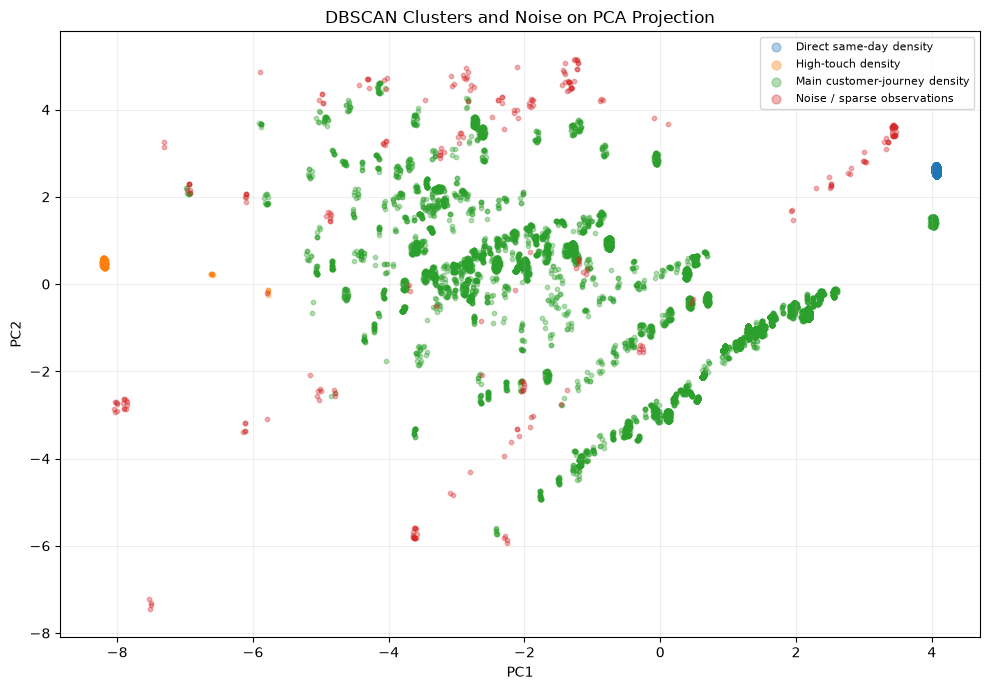

In [41]:
dbscan_plot = (
    pca_projection
    .loc[
        cluster_sample_paths
    ]
    .copy()
)

dbscan_plot["Cluster"] = [
    dbscan_semantic_names.get(
        label,
        f"Density cluster {label}"
    )
    for label in dbscan_labels
]

plt.figure(
    figsize=(10, 7)
)

for cluster_name, group in (
    dbscan_plot.groupby("Cluster")
):

    plt.scatter(
        group["PC1"],
        group["PC2"],
        s=10,
        alpha=0.35,
        label=cluster_name
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "DBSCAN Clusters and Noise on PCA Projection"
)

plt.legend(
    markerscale=2,
    fontsize=8
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### DBSCAN Interpretation

DBSCAN produces a substantially different view of the data from K-Means.

The dominant DBSCAN cluster contains the majority of customer journeys, suggesting that much of the dataset may form a broad connected density rather than several strongly separated populations.

A second dense region corresponds closely to **direct, one-touch, same-day journeys**.

A much smaller density cluster contains journeys with extremely high numbers of touchpoints and a strong referral component.

DBSCAN also labels a small percentage of observations as **noise**.

The noise observations tend to have unusual combinations of features, but the noise label should not automatically be interpreted as fraud, error, or a true anomaly. In DBSCAN, noise simply means that the observation does not belong to a sufficiently dense region under the selected parameter values.

The result is important because it challenges the four-cluster K-Means interpretation.

K-Means must divide the large customer population into several centroid-based groups, whereas DBSCAN indicates that much of that population may instead form one connected density.

This disagreement illustrates how the definition of a "cluster" depends on the algorithm.

### 4.3 Agglomerative Hierarchical Clustering

Agglomerative hierarchical clustering begins with every observation as its own cluster.

At each step, the two most compatible clusters are merged.

This produces a hierarchy of nested cluster solutions rather than a single flat partition.

For the main analysis, **Ward linkage** is used.

Ward's method selects the merge that causes the smallest increase in within-cluster squared error.

Conceptually, if clusters \(A\) and \(B\) are merged, Ward's method evaluates how much the merge increases within-cluster variation and prefers the smallest increase.

#### Strengths

- Provides a hierarchical interpretation of the dataset.
- Does not require centroid-based cluster geometry.
- Different linkage rules can reveal different structures.
- A dendrogram can visualize the hierarchy.

#### Weaknesses

- Classical agglomerative clustering scales poorly to very large datasets.
- Results are sensitive to the linkage criterion and distance metric.
- Once two clusters are merged, the decision cannot later be reversed.
- Cutting the hierarchy at a particular number of clusters still requires a methodological choice.

Because the dataset contains 93,629 journeys, classical hierarchical clustering on the complete dataset would be unnecessarily expensive.

Therefore, the same reproducible 10,000-journey sample used for DBSCAN is used for the main hierarchical analysis.

In [42]:
# Use a genuinely random and reproducible subset for
# hierarchical hyperparameter selection.
hierarchical_rng = np.random.default_rng(
    42
)

hierarchical_selection_positions = np.sort(
    hierarchical_rng.choice(
        len(X_cluster_sample),
        size=min(
            4000,
            len(X_cluster_sample)
        ),
        replace=False
    )
)

hierarchical_selection_X = (
    X_cluster_sample[
        hierarchical_selection_positions
    ]
)

hierarchical_k_results = []

for k in range(2, 7):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(
        hierarchical_selection_X
    )

    quality = clustering_quality(
        hierarchical_selection_X,
        labels
    )

    hierarchical_k_results.append({
        "Clusters": k,
        "Silhouette":
            quality["Silhouette"],
        "Calinski-Harabasz":
            quality["Calinski-Harabasz"],
        "Davies-Bouldin":
            quality["Davies-Bouldin"],
        "Within / Global Variance":
            quality[
                "Within / Global Variance"
            ]
    })

hierarchical_k_table = pd.DataFrame(
    hierarchical_k_results
)

display(
    hierarchical_k_table.round(4)
)

best_hierarchical_k_by_silhouette = int(
    hierarchical_k_table.loc[
        hierarchical_k_table[
            "Silhouette"
        ].idxmax(),
        "Clusters"
    ]
)

# Six clusters are retained for the main hierarchical
# interpretation because they provide useful finer-grained
# structure while remaining interpretable.
selected_hierarchical_k = 6

print(
    f"Highest tested Ward Silhouette: "
    f"K = {best_hierarchical_k_by_silhouette}"
)

print(
    f"Selected hierarchical cut: "
    f"K = {selected_hierarchical_k}"
)

,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin,Within / Global Variance
0,2,0.2261,"1,006.6256",1.8024,0.7989
1,3,0.2342,922.4055,1.5628,0.6842
2,4,0.2305,794.9870,1.4601,0.6262
3,5,0.2402,742.2632,1.5952,0.5737
4,6,0.2383,689.2828,1.6983,0.5368


Highest tested Ward Silhouette: K = 5
Selected hierarchical cut: K = 6


In [43]:
linkage_results = []

for linkage_method in [
    "ward",
    "complete",
    "average",
    "single"
]:

    model = AgglomerativeClustering(
        n_clusters=selected_hierarchical_k,
        linkage=linkage_method,
        metric="euclidean"
    )

    labels = model.fit_predict(
        hierarchical_selection_X
    )

    quality = clustering_quality(
        hierarchical_selection_X,
        labels
    )

    cluster_sizes = (
        pd.Series(labels)
        .value_counts()
    )

    linkage_results.append({
        "Linkage": linkage_method,
        "Silhouette":
            quality["Silhouette"],
        "Calinski-Harabasz":
            quality["Calinski-Harabasz"],
        "Davies-Bouldin":
            quality["Davies-Bouldin"],
        "Largest Cluster (%)":
            cluster_sizes.max()
            / len(labels)
            * 100,
        "Smallest Cluster":
            cluster_sizes.min()
    })

linkage_comparison = pd.DataFrame(
    linkage_results
)

display(
    linkage_comparison.round(4)
)

,Linkage,Silhouette,Calinski-Harabasz,Davies-Bouldin,Largest Cluster (%),Smallest Cluster
0,ward,0.2383,689.2828,1.6983,40.0250,340
1,complete,0.2327,169.8563,0.9748,94.3250,2
2,average,0.4564,131.1352,0.5191,98.1500,2
3,single,0.4515,116.2578,0.4628,98.4500,2


### Hierarchical Hyperparameter Selection

Both the number of clusters and the linkage criterion affect hierarchical clustering.

The metric-best number of Ward clusters in the reproducible selection sample is reported above rather than being hidden.

However, the clustering decision is not based on Silhouette score alone.

A **six-cluster Ward solution** is retained for the main analysis because it provides a useful finer-grained hierarchy while remaining interpretable in the context of customer journeys.

The linkage comparison also demonstrates why a single clustering metric can be misleading.

For example, **single linkage may produce an attractive Silhouette value while assigning almost the entire sample to one dominant cluster and leaving extremely small clusters containing only a few observations**.

Such a solution has poor practical value despite its numerical score.

Ward linkage is therefore preferred because:

- it produces substantially more balanced groups,
- it is directly related to within-cluster variance,
- and its resulting structure is more useful for interpreting customer-journey behavior.

The six-cluster solution should still not be interpreted as proof that exactly six objectively correct customer types exist. Hierarchical clustering is more appropriately interpreted as revealing several possible levels of organization in the data.

In [44]:
hierarchical_model = (
    AgglomerativeClustering(
        n_clusters=selected_hierarchical_k,
        linkage="ward"
    )
)

hierarchical_labels = (
    hierarchical_model.fit_predict(
        X_cluster_sample
    )
)

hierarchical_counts = (
    pd.Series(
        hierarchical_labels
    )
    .value_counts()
    .sort_index()
    .rename("Journeys")
    .to_frame()
)

hierarchical_counts[
    "Percentage (%)"
] = (
    hierarchical_counts["Journeys"]
    / len(hierarchical_labels)
    * 100
)

display(
    hierarchical_counts.round(2)
)

display(
    cluster_variance_table(
        X_cluster_sample,
        hierarchical_labels
    ).round(4)
)

,Journeys,Percentage (%)
0,3982,39.8200
1,189,1.8900
2,1192,11.9200
3,881,8.8100
4,2627,26.2700
5,1129,11.2900


,Cluster,Size,Average Within-Cluster Variance,Global Average Variance,Cluster / Global Variance
0,0,3982,0.7991,1.9560,0.4085
1,1,189,5.0823,1.9560,2.5983
2,2,1192,1.0157,1.9560,0.5193
3,3,881,0.7295,1.9560,0.3730
4,4,2627,1.1262,1.9560,0.5758
5,5,1129,1.2415,1.9560,0.6347


In [45]:
hierarchical_profiles = (
    journey_df
    .loc[
        cluster_sample_paths,
        profile_features
    ]
    .copy()
)

hierarchical_profiles[
    "Cluster"
] = hierarchical_labels

hierarchical_mean_profiles = (
    hierarchical_profiles
    .groupby("Cluster")
    [profile_features]
    .mean()
)

hierarchical_median_profiles = (
    hierarchical_profiles
    .groupby("Cluster")
    [profile_features]
    .median()
)

print("Mean profiles:")
display(
    hierarchical_mean_profiles.round(3)
)

print("Median profiles:")
display(
    hierarchical_median_profiles.round(3)
)

Mean profiles:


,total_revenue,days_till_key_event,touchpoints,path_segments,unique_campaigns,conversion_rate_mean,campaign_entropy,revenue_per_touchpoint,direct_tp_share,organic_tp_share,referral_tp_share,other_tp_share
Cluster,,,,,,,,,,,,
0,189.2620,23.2090,2.8960,1.0990,1.0990,0.0290,0.0680,100.0690,0.0000,0.0000,0.0000,1.0000
1,262.1410,17.6780,18.0370,3.3280,2.8520,0.0240,0.4240,14.6610,0.0000,0.4270,0.4330,0.1350
2,148.3700,0.5700,1.1840,1.0000,1.0000,0.0350,0.0000,144.6220,0.8560,0.0000,0.0000,0.0960
3,186.4070,14.2910,2.8720,1.1190,1.1190,0.0190,0.0760,108.7270,0.0000,0.0000,0.0000,1.0000
4,188.3130,18.2390,4.6220,2.1180,2.0130,0.0250,0.5970,57.0430,0.0000,0.4580,0.1210,0.4210
5,188.9810,35.3980,3.6530,2.8560,2.6120,0.0270,0.8720,61.6360,0.0000,0.1890,0.0260,0.7440


Median profiles:


,total_revenue,days_till_key_event,touchpoints,path_segments,unique_campaigns,conversion_rate_mean,campaign_entropy,revenue_per_touchpoint,direct_tp_share,organic_tp_share,referral_tp_share,other_tp_share
Cluster,,,,,,,,,,,,
0,190.5730,8.0000,3.0000,1.0000,1.0000,0.0300,-0.0000,63.5400,0.0000,0.0000,0.0000,1.0000
1,190.6380,6.0000,20.0000,3.0000,3.0000,0.0230,0.5620,9.5320,0.0000,0.0000,0.8120,0.1500
2,144.4460,0.0000,1.0000,1.0000,1.0000,0.0350,-0.0000,144.4460,1.0000,0.0000,0.0000,0.0000
3,190.1430,2.5000,2.0000,1.0000,1.0000,0.0200,-0.0000,95.3150,0.0000,0.0000,0.0000,1.0000
4,190.1720,9.0000,4.0000,2.0000,2.0000,0.0250,0.6370,47.7580,0.0000,0.5000,0.0000,0.4000
5,190.1160,32.0000,3.0000,3.0000,2.0000,0.0260,0.6930,62.8350,0.0000,0.0000,0.0000,1.0000


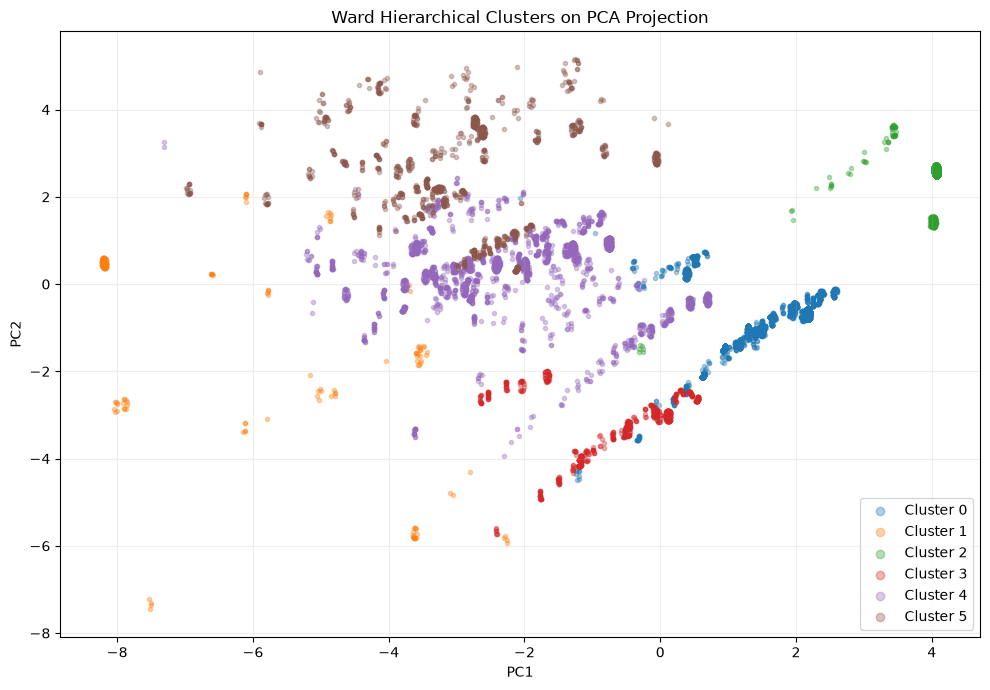

In [46]:
hierarchical_plot = (
    pca_projection
    .loc[
        cluster_sample_paths
    ]
    .copy()
)

hierarchical_plot[
    "Cluster"
] = hierarchical_labels

plt.figure(
    figsize=(10, 7)
)

for cluster, group in (
    hierarchical_plot.groupby(
        "Cluster"
    )
):

    plt.scatter(
        group["PC1"],
        group["PC2"],
        s=9,
        alpha=0.35,
        label=f"Cluster {cluster}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Ward Hierarchical Clusters on PCA Projection"
)

plt.legend(
    markerscale=2
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

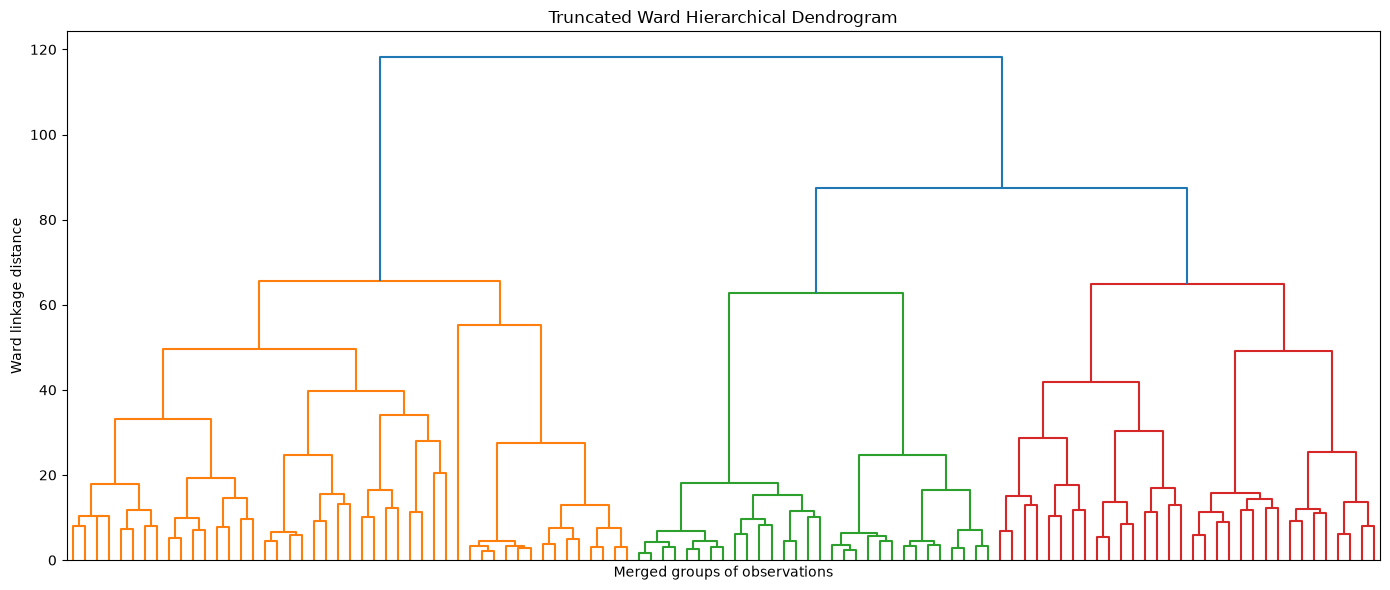

In [47]:
from scipy.cluster.hierarchy import (
    linkage,
    dendrogram
)

# Use a random reproducible subset only for visualizing
# the dendrogram. The full 10,000-sample clustering remains unchanged.
dendrogram_rng = np.random.default_rng(
    43
)

dendrogram_positions = np.sort(
    dendrogram_rng.choice(
        len(X_cluster_sample),
        size=min(
            1500,
            len(X_cluster_sample)
        ),
        replace=False
    )
)

dendrogram_X = (
    X_cluster_sample[
        dendrogram_positions
    ]
)

linkage_matrix = linkage(
    dendrogram_X,
    method="ward"
)

plt.figure(
    figsize=(14, 6)
)

dendrogram(
    linkage_matrix,
    truncate_mode="level",
    p=6,
    no_labels=True
)

plt.title(
    "Truncated Ward Hierarchical Dendrogram"
)

plt.xlabel(
    "Merged groups of observations"
)

plt.ylabel(
    "Ward linkage distance"
)

plt.tight_layout()
plt.show()

### Hierarchical-Clustering Interpretation

The Ward solution reveals a more detailed subdivision of the journey population than K-Means.

The resulting groups include patterns corresponding approximately to:

- very simple direct/same-day journeys,
- relatively simple single-source journeys,
- single-source journeys with different conversion characteristics,
- moderately complex multi-source journeys,
- long and diverse multi-campaign journeys,
- and a small group of very high-touch journeys.

This suggests that some of the broad groups produced by K-Means contain meaningful internal substructure.

However, increasing the number of clusters inevitably produces more specific groups. This does not prove that six objectively correct customer types exist.

Hierarchical clustering is better interpreted as showing **multiple possible levels of organization**.

At a high level, journeys may form a few broad behavioral families. At a lower level, those families can be divided into more specialized patterns.

In [48]:
# K-Means assignments for exactly the same
# 10,000 observations used by DBSCAN and hierarchical clustering.
kmeans_comparison_labels = (
    kmeans_model.predict(
        X_cluster_sample
    )
)

comparison_rows = []

methods = [
    (
        "K-Means",
        kmeans_comparison_labels,
        False
    ),
    (
        "DBSCAN",
        dbscan_labels,
        True
    ),
    (
        "Hierarchical (Ward)",
        hierarchical_labels,
        False
    )
]

for method_name, labels, ignore_noise in methods:

    quality = clustering_quality(
        X_cluster_sample,
        labels,
        ignore_noise=ignore_noise
    )

    comparison_rows.append({
        "Method": method_name,
        "Number of Clusters":
            len(
                set(labels)
                - {-1}
            ),
        "Noise (%)":
            (
                (labels == -1).mean()
                * 100
            ),
        "Silhouette":
            quality["Silhouette"],
        "Calinski-Harabasz":
            quality["Calinski-Harabasz"],
        "Davies-Bouldin":
            quality["Davies-Bouldin"],
        "Within / Global Variance":
            quality[
                "Within / Global Variance"
            ]
    })

clustering_comparison = pd.DataFrame(
    comparison_rows
)

display(
    clustering_comparison.round(4)
)

,Method,Number of Clusters,Noise (%),Silhouette,Calinski-Harabasz,Davies-Bouldin,Within / Global Variance
0,K-Means,4,0.0000,0.2512,"2,123.5069",1.5199,0.6108
1,DBSCAN,3,2.6200,0.2353,"1,278.3806",0.8948,0.7920
2,Hierarchical (Ward),6,0.0000,0.2520,"1,776.3817",1.5803,0.5295


In [49]:
agreement_table = pd.DataFrame({
    "Method Pair": [
        "K-Means vs DBSCAN",
        "K-Means vs Hierarchical",
        "DBSCAN vs Hierarchical"
    ],

    "Adjusted Rand Index": [
        adjusted_rand_score(
            kmeans_comparison_labels,
            dbscan_labels
        ),
        adjusted_rand_score(
            kmeans_comparison_labels,
            hierarchical_labels
        ),
        adjusted_rand_score(
            dbscan_labels,
            hierarchical_labels
        )
    ],

    "Normalized Mutual Information": [
        normalized_mutual_info_score(
            kmeans_comparison_labels,
            dbscan_labels
        ),
        normalized_mutual_info_score(
            kmeans_comparison_labels,
            hierarchical_labels
        ),
        normalized_mutual_info_score(
            dbscan_labels,
            hierarchical_labels
        )
    ]
})

display(
    agreement_table.round(4)
)

,Method Pair,Adjusted Rand Index,Normalized Mutual Information
0,K-Means vs DBSCAN,0.2619,0.4039
1,K-Means vs Hierarchical,0.5918,0.6444
2,DBSCAN vs Hierarchical,0.1836,0.3682


### 4.4 Comparison of the Three Clustering Methods

The three algorithms do not produce identical partitions.

This disagreement is expected because each method defines a cluster differently.

#### K-Means

K-Means searches for compact groups around centroids.

It therefore divides the complete population into a fixed number of regions even if boundaries between those regions are gradual.

#### DBSCAN

DBSCAN searches for density-connected regions.

The results indicate that a large fraction of the customer journeys may form one broad connected density, together with a clearly identifiable direct/same-day density and a small high-touch density.

Sparse observations are left unassigned as noise.

#### Hierarchical Clustering

Ward hierarchical clustering constructs nested groups by repeatedly minimizing the increase in within-cluster variation.

Its six-cluster solution provides finer subdivisions of some of the broader K-Means groups.

### Agreement Between Methods

The Adjusted Rand Index shows substantially greater agreement between K-Means and Ward hierarchical clustering than between either of those methods and DBSCAN.

This is reasonable because both K-Means and Ward linkage favor compact, variance-minimizing groups.

DBSCAN uses a fundamentally different density-based definition of cluster membership.

The disagreement between the algorithms therefore provides information about the geometry of the dataset rather than simply indicating that one method is wrong.

### 4.5 Average Within-Cluster Variance vs Global Variance

The assignment asks for comparison between the average variance within clusters and the global variance.

For \(K\) clusters, a weighted average within-cluster variance can be defined as:

\[
V_W =
\sum_{k=1}^{K}
\frac{n_k}{n}
\left[
\frac{1}{p}
\sum_{j=1}^{p}
Var(X_j \mid C_k)
\right]
\]

while the corresponding global average variance is:

\[
V_G =
\frac{1}{p}
\sum_{j=1}^{p}
Var(X_j)
\]

The ratio

\[
R =
\frac{V_W}{V_G}
\]

provides a measure of cluster compactness.

A smaller ratio means that observations within clusters vary less than the complete population.

### Is This Metric Suitable?

For **K-Means**, this measure is highly relevant because minimizing within-cluster squared variation is closely related to the actual objective of the algorithm.

It is also relevant to **Ward hierarchical clustering**, because Ward linkage explicitly selects merges according to increases in within-cluster squared variation.

For **DBSCAN**, however, variance is less appropriate as a primary metric.

A valid DBSCAN cluster may:

- be elongated,
- curved,
- irregularly shaped,
- or contain relatively high variance while remaining density-connected.

Furthermore, DBSCAN explicitly excludes noise observations, which changes the population used to calculate within-cluster variation.

Therefore, variance is reported as required but is complemented by:

- **Silhouette score** – higher is generally better,
- **Calinski–Harabasz index** – higher is generally better,
- **Davies–Bouldin index** – lower is generally better,
- cluster-size distributions,
- visual inspection,
- and real-world interpretability.

No single metric is treated as definitive.

### 4.6 Cluster Geometry, Hyperparameter Sensitivity, and Failure Modes

#### Cluster Geometry

K-Means implicitly favors approximately spherical or convex clusters around centroids.

Ward hierarchical clustering also favors relatively compact groups because its merging criterion is based on within-cluster variance.

DBSCAN does not require spherical clusters. It can identify arbitrarily shaped density-connected regions.

This difference explains why DBSCAN combines many observations that K-Means divides into separate centroid regions.

#### Hyperparameter Sensitivity

All three methods contain important methodological choices.

**K-Means**
- sensitive to the chosen value of \(K\),
- potentially sensitive to centroid initialization,
- although multiple initializations (`n_init=20`) reduce this problem.

**DBSCAN**
- highly sensitive to `eps`,
- sensitive to `min_samples`,
- particularly difficult to tune in moderately high-dimensional data.

**Hierarchical clustering**
- sensitive to the number of clusters selected from the hierarchy,
- sensitive to linkage method,
- and sensitive to distance definition.

The experiments with Ward, complete, average, and single linkage demonstrate that alternative linkage rules can create substantially different partitions.

#### Density-Based vs Centroid-Based Clustering

The contrast between DBSCAN and K-Means illustrates two fundamentally different concepts of clustering.

A centroid-based approach asks:

> Which representative center is each observation closest to?

A density-based approach asks:

> Is this observation part of a sufficiently dense connected region?

Neither definition is universally superior.

The appropriate definition depends on the structure and meaning of the real-world problem.

#### Situations Where Clustering May Fail

Clustering may provide misleading results when:

- the data contain no genuine group structure,
- behavior varies continuously rather than forming categories,
- distances become unreliable in high dimensions,
- features are poorly scaled,
- clusters have strongly different densities,
- extreme observations distort centroids,
- categorical or discrete structures produce artificial geometric patterns,
- or hyperparameters are chosen merely to obtain visually attractive results.

For this dataset, the moderate Silhouette scores and algorithm disagreement suggest that customer behavior is not composed of perfectly separated natural populations.

The clusters are therefore best interpreted as useful behavioral summaries rather than absolute customer classes.

### 4.7 Clustering the Feature Space

Until this point, clustering has grouped **customer journeys**.

The assignment also requires clustering the **features themselves**.

If the ordinary data matrix has the form

\[
X \in \mathbb{R}^{n \times p}
\]

where rows represent observations and columns represent features, feature clustering operates on:

\[
X^T \in \mathbb{R}^{p \times n}
\]

Therefore:

- ordinary clustering asks which **journeys behave similarly**,
- feature-space clustering asks which **variables behave similarly across journeys**.

The standardized original 26-feature matrix is transposed, producing 26 observations whose coordinates are the 93,629 customer journeys.

Because every original feature was standardized to approximately zero mean and unit variance, cosine similarity between two transposed feature vectors is closely related to their Pearson correlation.

Consequently, cosine-distance hierarchical clustering provides a natural way to identify groups of correlated or behaviorally related variables.

In [50]:
# Rows are now FEATURES and columns are JOURNEYS.
X_feature_space = (
    X_scaled.T
)

print(
    f"Original matrix: "
    f"{X_scaled.shape}"
)

print(
    f"Transposed feature matrix: "
    f"{X_feature_space.shape}"
)

Original matrix: (93629, 26)
Transposed feature matrix: (26, 93629)


,Number of Feature Clusters,Silhouette Score,Singleton Clusters,Smallest Cluster Size,Largest Cluster Size
0,2,0.2751,0,9,17
1,3,0.2728,0,5,12
2,4,0.2616,1,1,12
3,5,0.2776,2,1,12
4,6,0.2801,3,1,12
5,7,0.2834,4,1,12
6,8,0.2848,5,1,12
7,9,0.2763,6,1,11
8,10,0.3656,6,1,6
9,11,0.3794,7,1,6


Highest tested feature-space Silhouette: K = 14
Selected interpretable feature-space cut: K = 10


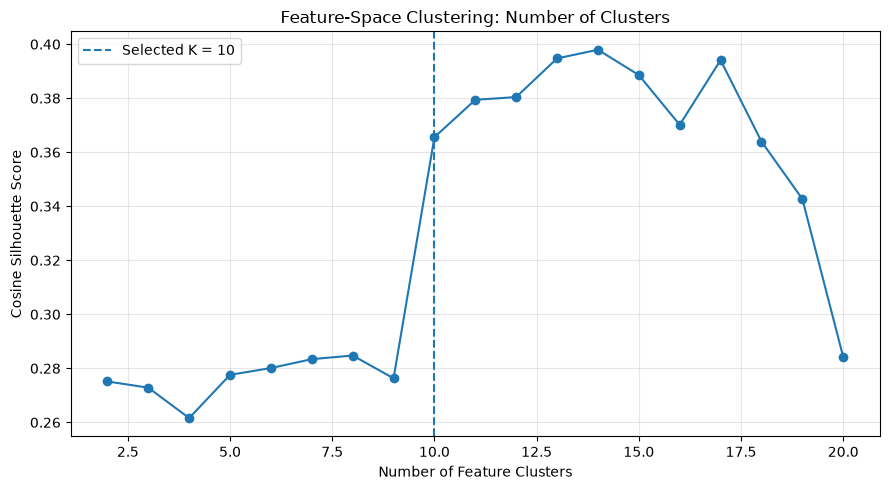

In [51]:
feature_clustering_results = []

# A wider range is examined because the original test stopped
# exactly at K=10, where the Silhouette score was still increasing.
for k in range(2, 21):

    model = AgglomerativeClustering(
        n_clusters=k,
        metric="cosine",
        linkage="average"
    )

    labels = model.fit_predict(
        X_feature_space
    )

    silhouette = silhouette_score(
        X_feature_space,
        labels,
        metric="cosine"
    )

    cluster_sizes = (
        pd.Series(labels)
        .value_counts()
    )

    feature_clustering_results.append({
        "Number of Feature Clusters": k,
        "Silhouette Score": silhouette,
        "Singleton Clusters":
            int(
                (cluster_sizes == 1).sum()
            ),
        "Smallest Cluster Size":
            int(cluster_sizes.min()),
        "Largest Cluster Size":
            int(cluster_sizes.max())
    })

feature_cluster_selection = pd.DataFrame(
    feature_clustering_results
)

display(
    feature_cluster_selection.round(4)
)

best_feature_k_by_silhouette = int(
    feature_cluster_selection.loc[
        feature_cluster_selection[
            "Silhouette Score"
        ].idxmax(),
        "Number of Feature Clusters"
    ]
)

# A 10-cluster cut is retained for interpretation.
# Very large K values can improve Silhouette partly by
# creating many singleton or very small feature clusters.
selected_feature_k = 10

print(
    f"Highest tested feature-space Silhouette: "
    f"K = {best_feature_k_by_silhouette}"
)

print(
    f"Selected interpretable feature-space cut: "
    f"K = {selected_feature_k}"
)


plt.figure(
    figsize=(9, 5)
)

plt.plot(
    feature_cluster_selection[
        "Number of Feature Clusters"
    ],
    feature_cluster_selection[
        "Silhouette Score"
    ],
    marker="o"
)

plt.axvline(
    selected_feature_k,
    linestyle="--",
    label="Selected K = 10"
)

plt.xlabel(
    "Number of Feature Clusters"
)

plt.ylabel(
    "Cosine Silhouette Score"
)

plt.title(
    "Feature-Space Clustering: Number of Clusters"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Feature-Space Cluster-Cut Selection

The feature-space analysis contains only **26 feature vectors**, rather than tens of thousands of customer observations.

This changes the interpretation of clustering metrics.

As the requested number of feature clusters becomes large, the hierarchy begins to produce many very small or singleton clusters.

Such fine partitions can sometimes improve the Silhouette score because isolated features receive their own groups, but they become less useful for the primary purpose of this analysis: identifying meaningful **families of related variables**.

Therefore, the Silhouette-maximizing cut is reported above but is not selected automatically.

A **10-cluster cut** is retained as an interpretable compromise.

At this level, the hierarchy still reveals coherent groups involving:

- touchpoint intensity,
- campaign complexity,
- conversion behavior,
- journey duration,
- and traffic-source composition,

while also identifying several genuinely isolated variables.

The dendrogram is retained as the more complete representation of the hierarchy because it allows the reader to inspect alternative cuts rather than implying that one number of feature clusters is uniquely correct.

In [52]:
feature_cluster_model = (
    AgglomerativeClustering(
        n_clusters=selected_feature_k,
        metric="cosine",
        linkage="average"
    )
)

feature_cluster_labels = (
    feature_cluster_model.fit_predict(
        X_feature_space
    )
)

feature_cluster_table = pd.DataFrame({
    "Feature": pca_feature_names,
    "Feature Cluster":
        feature_cluster_labels
})

feature_cluster_table = (
    feature_cluster_table
    .sort_values(
        [
            "Feature Cluster",
            "Feature"
        ]
    )
)

display(
    feature_cluster_table
)

print(
    "\nFeatures grouped by cluster:"
)

for cluster in sorted(
    feature_cluster_table[
        "Feature Cluster"
    ].unique()
):

    features = (
        feature_cluster_table.loc[
            feature_cluster_table[
                "Feature Cluster"
            ] == cluster,
            "Feature"
        ]
        .tolist()
    )

    print(
        f"\nFeature Cluster {cluster}:"
    )

    for feature in features:
        print(
            f"  - {feature}"
        )

,Feature,Feature Cluster
5,max_tp_per_segment,0
6,mean_tp_per_segment,0
19,referral_tp_share,0
7,std_tp_per_segment,0
2,touchpoints,0
16,days_per_touchpoint,1
1,days_till_key_event,1
21,other_tp_share,1
11,conversion_rate_max,2
8,conversion_rate_mean,2



Features grouped by cluster:

Feature Cluster 0:
  - max_tp_per_segment
  - mean_tp_per_segment
  - referral_tp_share
  - std_tp_per_segment
  - touchpoints

Feature Cluster 1:
  - days_per_touchpoint
  - days_till_key_event
  - other_tp_share

Feature Cluster 2:
  - conversion_rate_max
  - conversion_rate_mean
  - conversion_rate_min
  - conversion_rate_weighted_mean
  - direct_tp_share
  - revenue_per_touchpoint

Feature Cluster 3:
  - event_dow_cos

Feature Cluster 4:
  - campaign_entropy
  - conversion_rate_range
  - conversion_rate_std
  - organic_tp_share
  - path_segments
  - unique_campaigns

Feature Cluster 5:
  - event_month_cos

Feature Cluster 6:
  - event_month_sin

Feature Cluster 7:
  - not_set_tp_share

Feature Cluster 8:
  - total_revenue

Feature Cluster 9:
  - event_dow_sin


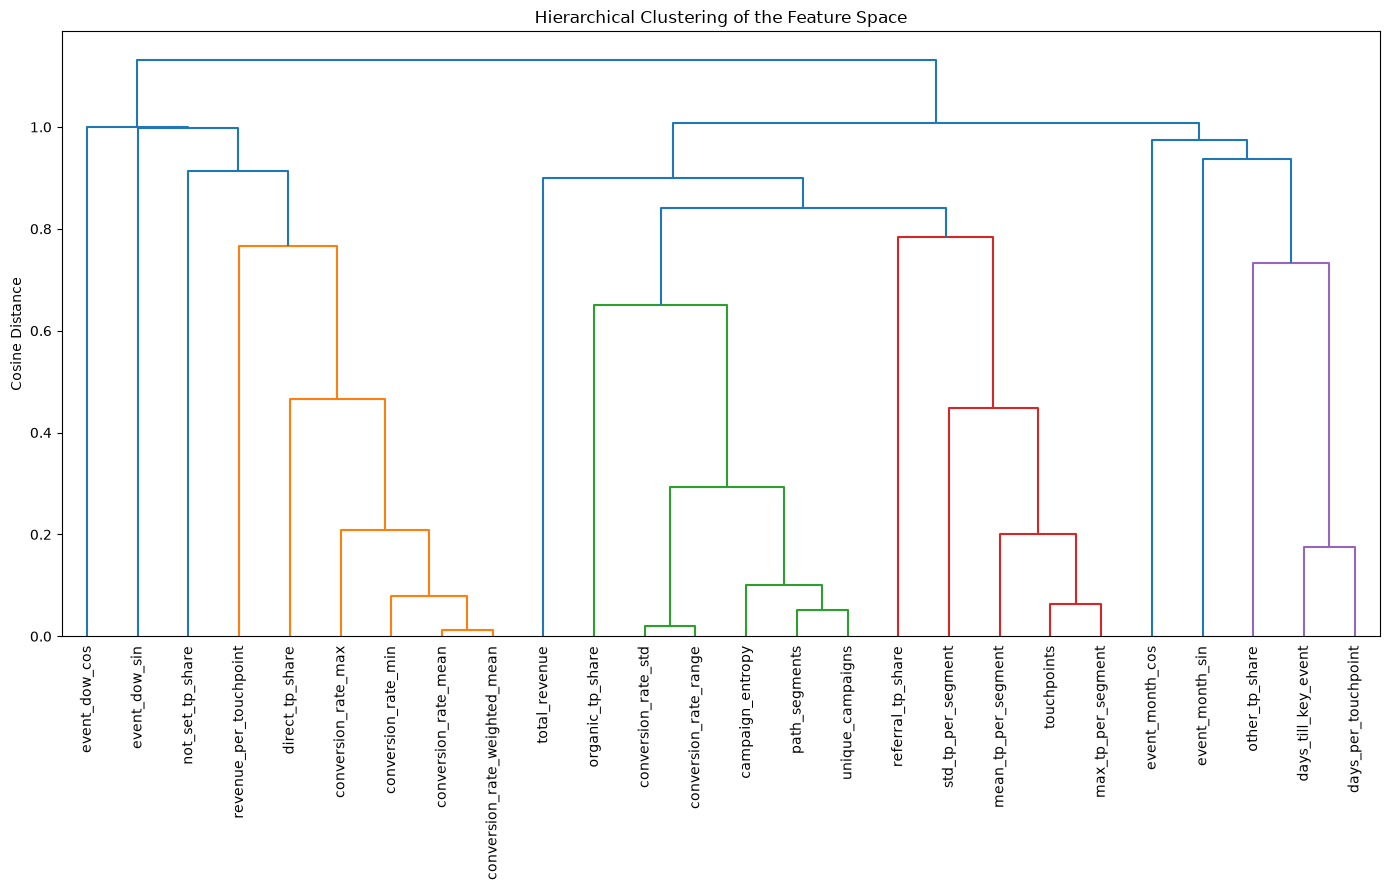

In [53]:
from scipy.cluster.hierarchy import (
    linkage,
    dendrogram
)

feature_linkage = linkage(
    X_feature_space,
    method="average",
    metric="cosine"
)

plt.figure(
    figsize=(14, 9)
)

dendrogram(
    feature_linkage,
    labels=pca_feature_names,
    leaf_rotation=90
)

plt.ylabel(
    "Cosine Distance"
)

plt.title(
    "Hierarchical Clustering of the Feature Space"
)

plt.tight_layout()
plt.show()

### 4.8 Interpretation of Feature-Space Clustering

Clustering the transposed feature matrix reveals structure that is fundamentally different from customer clustering.

Several meaningful groups of variables appear.

#### Touchpoint-Intensity Group

Variables related to interaction volume tend to cluster together, including features such as:

- total touchpoints,
- maximum touchpoints per segment,
- mean touchpoints per segment,
- touchpoint variability.

This confirms that these variables describe related aspects of journey intensity and contain partially redundant information.

#### Journey-Complexity and Campaign-Diversity Group

Another related family contains variables such as:

- path segments,
- number of unique campaigns,
- campaign entropy,
- conversion-rate variability,
- conversion-rate range,
- and some traffic-source composition variables.

These variables jointly describe how diversified and structurally complicated the acquisition journey is.

#### Conversion-Level Group

Several conversion variables strongly group together:

- mean conversion rate,
- weighted mean conversion rate,
- minimum conversion rate,
- maximum conversion rate.

This agrees with the high correlations observed during EDA and with their joint contribution to the first PCA components.

Revenue per touchpoint and direct-traffic behavior also appear relatively close to this structure because simple direct journeys tend to have distinctive conversion characteristics.

#### Duration Group

`days_till_key_event` and `days_per_touchpoint` form a closely related pair.

This is expected because both directly encode how much time is involved in the customer journey.

#### Isolated or Distinct Features

Several variables appear more isolated from the major groups.

Most notably, calendar sine/cosine variables often form isolated branches or very small groups.

This makes sense because cyclical calendar information is intentionally encoded as nearly orthogonal dimensions and does not strongly track the behavioral variables.

`total_revenue` can also become separated from the major touchpoint and complexity groups at finer levels of the hierarchy, showing that revenue contains information that cannot be fully explained by journey complexity alone.

The `(not set)` traffic share similarly behaves differently from the major acquisition-source variables.

### What Did Feature Clustering Reveal That Sample Clustering Did Not?

Customer clustering identifies common **types of journeys**.

Feature clustering instead identifies common **types of information**.

For example, sample clustering showed that high-touch journeys form a distinctive behavioral population, while feature clustering reveals that several different measurements of touchpoint intensity are themselves highly related and potentially redundant.

Likewise, clustering customers cannot directly show that mean conversion rate and weighted conversion rate contain almost the same structural information. Feature clustering makes this relationship explicit.

Therefore, feature clustering provides insight into:

- redundancy,
- dependency,
- potential feature families,
- dimensional structure,
- and possible feature hierarchies.

These findings are consistent with the earlier correlation and PCA analyses but provide a different hierarchical representation of those relationships.

### 4.9 When Is Feature Clustering Useful?

Clustering variables rather than observations can be particularly useful in high-dimensional domains.

Examples include:

#### Genomics

Thousands of genes can be grouped according to similar expression patterns, potentially revealing biological pathways or co-regulated gene groups.

#### Finance

Financial indicators or assets can be grouped according to similar behavior, helping identify redundant indicators or common market factors.

#### Sensor Systems and IoT

Sensors that measure the same physical process may produce highly similar signals. Feature clustering can reveal redundancy, malfunctioning sensors, or groups of sensors representing the same subsystem.

#### Cybersecurity

Large sets of network features can be grouped according to related activity patterns, helping identify groups of measurements associated with particular types of traffic.

#### E-Commerce

Marketing, acquisition, engagement, timing, and revenue variables can be grouped according to the behavioral processes they describe.

Feature clustering can therefore support:

- feature selection,
- dimensionality reduction,
- interpretation,
- redundancy detection,
- and the discovery of latent feature hierarchies.

### 4.10 Clustering Conclusions

The clustering analysis provides several important conclusions.

1. **K-Means** identifies four interpretable broad journey profiles, including direct same-day journeys, simple non-direct journeys, multi-campaign journeys, and high-touch complex journeys.

2. The moderate K-Means Silhouette score indicates that these groups are useful summaries but are not perfectly separated natural populations.

3. **DBSCAN** gives a substantially different representation. Much of the customer population forms one broad connected density, while a direct/same-day density and a small high-touch density are distinguishable. A small percentage of observations are classified as noise.

4. **Ward hierarchical clustering** reveals finer substructure inside the broader journey groups and demonstrates that customer behavior can be interpreted at several levels of granularity.

5. K-Means and Ward clustering agree more strongly with each other than either agrees with DBSCAN. This is consistent with their shared preference for compact, variance-based groups.

6. The algorithms disagree because they use fundamentally different definitions of cluster structure. This disagreement should be interpreted rather than hidden.

7. The within-cluster/global-variance ratio is particularly appropriate for K-Means and Ward clustering but is less suitable as a primary quality criterion for density-based clustering.

8. No single clustering metric provides definitive evidence of a correct solution. Silhouette, Calinski–Harabasz, Davies–Bouldin, cluster sizes, geometry, stability, and real-world interpretation must be considered together.

9. Classical hierarchical clustering and DBSCAN demonstrate important computational limitations on a dataset containing more than 93,000 observations. Reproducible sampling is therefore used rather than hiding the scalability problem.

10. Clustering the **transposed feature matrix** reveals groups of related variables describing touchpoint intensity, campaign complexity, conversion behavior, duration, and traffic-source composition.

11. Feature clustering also identifies relatively isolated variables and exposes redundancy that is not directly visible when clustering customer journeys.

12. The combined evidence from EDA, PCA, sample clustering, and feature clustering suggests that the dataset contains meaningful structure, but it does not support the claim that one uniquely correct clustering solution exists.

13. A major limitation of the analytical representation is the high proportion of repeated feature vectors: approximately 81.95% of journeys duplicate a previously observed 26-dimensional behavioral vector. This can affect cluster sizes and density-based interpretations because many distinct journeys occupy exactly the same location in feature space. Therefore, the clustering results should be interpreted as structure in the engineered behavioral representation rather than as evidence that every journey contributes a unique geometric observation.

This is consistent with the fundamental nature of unsupervised learning: the discovered structure depends on the representation of the data, the distance definition, the algorithm, and the modeling assumptions.

## 5. Multi-Dimensional Anomaly Detection

Anomaly detection aims to identify observations whose behavior differs substantially from the majority of the dataset.

In this project, an anomaly represents an **unusual customer journey**, not necessarily an erroneous or fraudulent observation.

This distinction is important because unusual behavior may represent:

- a legitimate but rare customer journey,
- an unusually complex conversion path,
- an extreme revenue or duration value,
- a rare combination of traffic sources,
- or a possible measurement or preprocessing artifact.

There is no ground-truth anomaly label in the dataset. Therefore, the results of the anomaly-detection algorithms cannot be interpreted as objectively correct classifications.

Three fundamentally different methods are investigated:

1. **Classical Z-Score**
2. **Isolation Forest**
3. **Local Outlier Factor (LOF)**

These methods define abnormality differently:

- Z-Score identifies extreme feature values relative to global means and standard deviations.
- Isolation Forest identifies observations that can be isolated quickly through random partitions.
- LOF identifies observations whose local density is substantially lower than the density of their neighbors.

Comparing these approaches allows us to investigate both global and local forms of abnormal behavior.

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from scipy.stats import norm

import warnings

required_objects = [
    "journey_features",
    "journey_df",
    "pca_feature_names",
    "pca_projection"
]

for object_name in required_objects:
    if object_name not in globals():
        raise NameError(
            f"{object_name} is not defined. "
            "Run the notebook from the beginning."
        )

# Use the same 26 behavioral numerical features used for PCA.
# The missing_path_step diagnostic indicator remains excluded so
# algorithms do not directly receive knowledge of the known data issue.
X_anomaly_raw = (
    journey_features[pca_feature_names]
    .astype(float)
    .copy()
)

anomaly_scaler = StandardScaler()

X_anomaly_scaled = (
    anomaly_scaler.fit_transform(
        X_anomaly_raw
    )
)

assert X_anomaly_raw.isna().sum().sum() == 0
assert np.isfinite(X_anomaly_scaled).all()

# Reuse the reproducible 10,000-observation sample from clustering
# when available. Otherwise create the same deterministic sample.
if "cluster_sample_positions" in globals():
    anomaly_sample_positions = np.asarray(
        cluster_sample_positions
    )
else:
    rng = np.random.default_rng(42)

    anomaly_sample_positions = np.sort(
        rng.choice(
            len(X_anomaly_scaled),
            size=min(
                10000,
                len(X_anomaly_scaled)
            ),
            replace=False
        )
    )

X_anomaly_sample = (
    X_anomaly_scaled[
        anomaly_sample_positions
    ]
)

anomaly_sample_paths = (
    X_anomaly_raw.index[
        anomaly_sample_positions
    ]
)

print(
    f"Complete anomaly-detection matrix: "
    f"{X_anomaly_scaled.shape[0]:,} journeys × "
    f"{X_anomaly_scaled.shape[1]} features"
)

print(
    f"Common LOF/comparison sample: "
    f"{len(X_anomaly_sample):,} journeys"
)

Complete anomaly-detection matrix: 93,629 journeys × 26 features
Common LOF/comparison sample: 10,000 journeys


### 5.0 Methodological Setup

The anomaly-detection analysis uses the same **26 behavioral numerical variables** used in the PCA analysis.

The diagnostic variable `missing_path_step` is deliberately excluded from the model input.

This is important because the EDA already identified 47 journeys containing a missing Path Step. Feeding that indicator directly into the anomaly algorithms would reveal the known data-quality issue to the algorithms and would make later evaluation circular.

Instead, the indicator is retained only for **post-hoc validation**: after fitting the anomaly models, we can check whether those suspicious journeys are independently identified as unusual based on their other behavioral characteristics.

The variables are standardized before Z-Score and LOF analysis because both methods depend directly on numerical magnitudes or distances.

The same standardized representation is also supplied to Isolation Forest to maintain a consistent analytical feature space across methods, although tree-based Isolation Forest is considerably less sensitive to linear feature scaling than distance-based methods.

### 5.1 Classical Z-Score Method

The Z-score expresses how many standard deviations an observation lies above or below the mean of a variable.

For feature \(j\):

\[
z_{ij} =
\frac{x_{ij}-\mu_j}
{\sigma_j}
\]

where:

- \(x_{ij}\) is the value of feature \(j\) for observation \(i\),
- \(\mu_j\) is the feature mean,
- \(\sigma_j\) is the feature standard deviation.

A classical rule marks a value as potentially extreme when:

\[
|z| > 3
\]

Under an ideal Gaussian distribution, only approximately 0.27% of observations should lie more than three standard deviations from the mean for a single feature.

### Feature-Wise vs Observation-Level Detection

The Z-score is inherently **feature-wise**.

It identifies whether a particular variable is extreme.

To convert this into an observation-level anomaly decision, this analysis uses the classical rule:

> A journey is marked as anomalous if at least one of its numerical features has \(|z| > 3\).

We also calculate the number of extreme features for every journey and its maximum absolute Z-score.

A multidimensional Euclidean Z-score magnitude is calculated for descriptive purposes:

\[
D_i =
\sqrt{
\sum_{j=1}^{p} z_{ij}^{2}
}
\]

However, this value is not used as a hard anomaly threshold because correlated features are counted repeatedly and the variables are not jointly Gaussian.

In [55]:
feature_means = (
    X_anomaly_raw.mean()
)

feature_std = (
    X_anomaly_raw.std(
        ddof=0
    )
)

assert (
    feature_std > 0
).all()

zscore_df = (
    X_anomaly_raw
    .sub(feature_means)
    .div(feature_std)
)

absolute_zscores = (
    zscore_df.abs()
)

z_threshold = 3.0

zscore_feature_flags = (
    absolute_zscores
    > z_threshold
)

# Observation-level classical decision:
# at least one feature exceeds |Z| > 3.
zscore_anomaly_mask = (
    zscore_feature_flags
    .any(axis=1)
)

zscore_extreme_feature_count = (
    zscore_feature_flags
    .sum(axis=1)
)

zscore_max_abs = (
    absolute_zscores
    .max(axis=1)
)

# Descriptive multivariate magnitude.
zscore_global_l2 = np.sqrt(
    np.square(
        zscore_df
    ).sum(axis=1)
)

print(
    f"Z-score threshold: |Z| > {z_threshold}"
)

print(
    f"Journeys flagged as anomalous: "
    f"{zscore_anomaly_mask.sum():,}"
)

print(
    f"Percentage flagged: "
    f"{zscore_anomaly_mask.mean() * 100:.2f}%"
)

print(
    "\nNumber of extreme features "
    "among flagged journeys:"
)

display(
    zscore_extreme_feature_count[
        zscore_anomaly_mask
    ]
    .value_counts()
    .sort_index()
    .rename("Journeys")
    .to_frame()
)

Z-score threshold: |Z| > 3.0
Journeys flagged as anomalous: 12,813
Percentage flagged: 13.68%

Number of extreme features among flagged journeys:


,Journeys
1,7788
2,3062
3,446
4,551
5,53
6,913


In [56]:
zscore_feature_summary = pd.DataFrame({
    "Extreme Values |Z| > 3":
        zscore_feature_flags.sum(),

    "Extreme Percentage (%)":
        zscore_feature_flags.mean() * 100,

    "Skewness":
        X_anomaly_raw.skew(),

    "Excess Kurtosis":
        X_anomaly_raw.kurt()
})

zscore_feature_summary = (
    zscore_feature_summary
    .sort_values(
        "Extreme Values |Z| > 3",
        ascending=False
    )
)

display(
    zscore_feature_summary.round(4)
)

# Theoretical Gaussian expectation.
single_feature_tail_probability = (
    2 * (
        1
        - norm.cdf(z_threshold)
    )
)

independent_multifeature_probability = (
    1
    - (
        1
        - single_feature_tail_probability
    ) ** X_anomaly_raw.shape[1]
)

print(
    "\nGaussian theoretical probability "
    f"for one feature beyond ±3σ: "
    f"{single_feature_tail_probability * 100:.3f}%"
)

print(
    "Approximate probability that at least one of "
    f"{X_anomaly_raw.shape[1]} independent Gaussian "
    "features exceeds ±3σ: "
    f"{independent_multifeature_probability * 100:.2f}%"
)

print(
    "Observed journey-level Z-score anomaly rate: "
    f"{zscore_anomaly_mask.mean() * 100:.2f}%"
)

,Extreme Values |Z| > 3,Extreme Percentage (%),Skewness,Excess Kurtosis
referral_tp_share,2618,2.7961,4.2499,18.2079
max_tp_per_segment,2522,2.6936,2.7326,9.8186
unique_campaigns,2486,2.6552,1.4065,1.7247
std_tp_per_segment,2396,2.5590,4.6212,29.3540
path_segments,1965,2.0987,2.1042,6.1357
mean_tp_per_segment,1933,2.0645,2.9350,13.8191
conversion_rate_range,1809,1.9321,1.7819,2.9397
touchpoints,1693,1.8082,2.5909,8.8096
organic_tp_share,1621,1.7313,1.6490,1.2924
conversion_rate_std,1541,1.6459,1.8177,3.5003



Gaussian theoretical probability for one feature beyond ±3σ: 0.270%
Approximate probability that at least one of 26 independent Gaussian features exceeds ±3σ: 6.79%
Observed journey-level Z-score anomaly rate: 13.68%


### Z-Score Results and Gaussianity

The classical Z-score method flags approximately **13.7% of the customer journeys** because at least one feature exceeds three standard deviations from its mean.

This is a relatively large percentage.

For comparison, under a Gaussian distribution, only approximately 0.27% of values should exceed \(\pm3\sigma\) for one variable.

Even if 26 features were completely independent and Gaussian, the probability that at least one feature exceeds the threshold would be only about 6–7%.

The observed rate is substantially larger.

This result is consistent with the EDA, which showed:

- strong skewness,
- heavy tails,
- bounded variables,
- zero-inflated traffic proportions,
- discrete conversion-rate values,
- and very high kurtosis for several features.

Therefore, the Gaussian assumption underlying the classical interpretation of a Z-score is weak for this dataset.

Features such as referral share, touchpoint statistics, journey complexity, and campaign variability generate considerably more extreme Z-scores than would be expected under a Gaussian model.

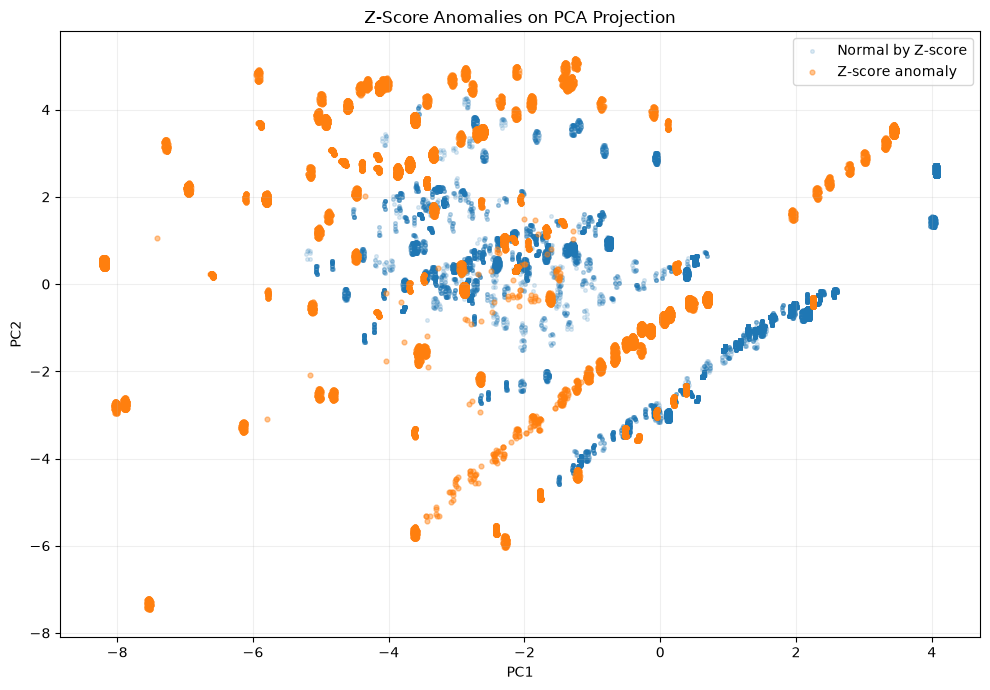

In [57]:
zscore_plot = (
    pca_projection[
        ["PC1", "PC2"]
    ]
    .copy()
)

zscore_plot[
    "Anomaly"
] = zscore_anomaly_mask

normal_z_plot = (
    zscore_plot[
        ~zscore_plot["Anomaly"]
    ]
)

# Subsample normal observations only for readability.
if len(normal_z_plot) > 20000:
    normal_z_plot = (
        normal_z_plot.sample(
            n=20000,
            random_state=42
        )
    )

anomalous_z_plot = (
    zscore_plot[
        zscore_plot["Anomaly"]
    ]
)

plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    normal_z_plot["PC1"],
    normal_z_plot["PC2"],
    s=7,
    alpha=0.15,
    label="Normal by Z-score"
)

plt.scatter(
    anomalous_z_plot["PC1"],
    anomalous_z_plot["PC2"],
    s=12,
    alpha=0.45,
    label="Z-score anomaly"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Z-Score Anomalies on PCA Projection"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [58]:
zscore_diagnostics = (
    journey_df[
        [
            "total_revenue",
            "days_till_key_event",
            "touchpoints",
            "path_segments",
            "unique_campaigns",
            "conversion_rate_mean",
            "campaign_entropy",
            "revenue_per_touchpoint",
            "missing_path_step"
        ]
    ]
    .copy()
)

zscore_diagnostics[
    "max_abs_zscore"
] = zscore_max_abs

zscore_diagnostics[
    "extreme_feature_count"
] = zscore_extreme_feature_count

print(
    "Most extreme journeys according to maximum |Z|:"
)

display(
    zscore_diagnostics
    .sort_values(
        "max_abs_zscore",
        ascending=False
    )
    .head(15)
)

known_missing_step_paths = (
    journey_features.index[
        journey_features[
            "missing_path_step"
        ] == 1
    ]
)

print(
    "\nKnown missing-Path-Step journeys:",
    len(known_missing_step_paths)
)

print(
    "Known suspicious journeys also flagged "
    "by Z-score:",
    int(
        zscore_anomaly_mask
        .loc[
            known_missing_step_paths
        ]
        .sum()
    )
)

Most extreme journeys according to maximum |Z|:


,total_revenue,days_till_key_event,touchpoints,path_segments,unique_campaigns,conversion_rate_mean,campaign_entropy,revenue_per_touchpoint,missing_path_step,max_abs_zscore,extreme_feature_count
Path ID,,,,,,,,,,,
94382,"2,811.9600",15.0000,20.0000,2,2,0.0250,0.5623,140.5980,1,41.7052,5
94399,"2,811.9600",15.0000,20.0000,2,2,0.0250,0.5623,140.5980,1,41.7052,5
94383,"2,811.9600",15.0000,20.0000,2,2,0.0250,0.5623,140.5980,1,41.7052,5
94384,"2,811.9600",15.0000,20.0000,2,2,0.0250,0.5623,140.5980,1,41.7052,5
94385,"2,811.9600",15.0000,20.0000,2,2,0.0250,0.5623,140.5980,1,41.7052,5
94386,"2,811.9600",15.0000,20.0000,2,2,0.0250,0.5623,140.5980,1,41.7052,5
94387,"2,811.9600",15.0000,20.0000,2,2,0.0250,0.5623,140.5980,1,41.7052,5
94388,"2,811.9600",15.0000,20.0000,2,2,0.0250,0.5623,140.5980,1,41.7052,5
94389,"2,811.9600",15.0000,20.0000,2,2,0.0250,0.5623,140.5980,1,41.7052,5



Known missing-Path-Step journeys: 47
Known suspicious journeys also flagged by Z-score: 47


### Why Z-Score Can Fail in High Dimensions

The Z-score method has several important limitations in this problem.

#### Multiple-Dimension Effect

With many features, there are many opportunities for at least one variable to exceed a fixed threshold.

Therefore, an observation-level rule based on:

\[
\max_j |z_{ij}| > 3
\]

becomes increasingly likely to flag observations as the number of dimensions grows.

This is one reason why approximately 13.7% of the journeys are classified as anomalous by the classical rule.

#### Correlated Features

Several features in this dataset are strongly correlated or even linearly dependent.

An unusual behavioral property can therefore generate extreme values in several related features simultaneously.

Treating each variable as independent can exaggerate the apparent evidence of abnormality.

#### Non-Gaussian Variables

Many variables are strongly skewed or zero-inflated.

A Z-score interprets distance from the mean in units of standard deviation, but this does not correspond to a Gaussian probability when the underlying distribution is not Gaussian.

#### Feature-Wise vs Global Abnormality

A feature-wise Z-score is easy to interpret because it identifies exactly which variable is extreme.

However, a customer may be unusual because of a **combination of moderately unusual values**, even when no individual feature exceeds three standard deviations.

Such multivariate anomalies may be missed by the classical Z-score rule.

Conversely, a journey with one legitimate heavy-tailed value may be incorrectly flagged.

Therefore, Z-score provides a transparent baseline but should not be treated as a definitive anomaly detector for this dataset.

### 5.2 Isolation Forest

Isolation Forest approaches anomaly detection differently from statistical distance methods.

Instead of modeling what normal observations look like, the algorithm asks:

> How easily can an observation be isolated from the rest of the dataset?

Each isolation tree repeatedly:

1. randomly selects a feature,
2. randomly selects a split value between the minimum and maximum values of that feature,
3. recursively partitions the observations.

An unusual observation is generally easier to separate from the rest of the population and therefore reaches an isolated leaf after fewer random splits.

Let \(h(x)\) denote the path length required to isolate observation \(x\).

Anomalies tend to have:

\[
E[h(x)]
\]

smaller than ordinary observations.

The classical Isolation Forest anomaly score can be written conceptually as:

\[
s(x,n)=
2^{
-\frac{E[h(x)]}{c(n)}
}
\]

where \(c(n)\) normalizes the expected path length of a random binary search tree.

A relatively **high anomaly score corresponds to short isolation paths and more unusual observations**.

Scikit-learn internally uses a score convention in which lower `score_samples` values represent more abnormal observations. In this notebook, the sign is reversed:

\[
\text{IF anomaly score}
=
-\text{score\_samples}
\]

so that **larger values consistently mean more anomalous behavior**.

In [59]:
iforest_contamination = 0.03

iforest_model = IsolationForest(
    n_estimators=300,
    contamination=iforest_contamination,
    random_state=42,
    n_jobs=-1
)

iforest_prediction = (
    iforest_model.fit_predict(
        X_anomaly_scaled
    )
)

iforest_anomaly_mask = (
    iforest_prediction == -1
)

# Reverse sklearn's raw score direction:
# larger value = more anomalous.
iforest_anomaly_score = (
    -iforest_model.score_samples(
        X_anomaly_scaled
    )
)

# sklearn decision_function:
# negative values indicate observations classified as anomalies.
iforest_decision = (
    iforest_model.decision_function(
        X_anomaly_scaled
    )
)

print(
    f"Isolation Forest contamination: "
    f"{iforest_contamination:.1%}"
)

print(
    f"Anomalies detected: "
    f"{iforest_anomaly_mask.sum():,}"
)

print(
    f"Percentage detected: "
    f"{iforest_anomaly_mask.mean() * 100:.2f}%"
)

print(
    f"Minimum anomaly score: "
    f"{iforest_anomaly_score.min():.4f}"
)

print(
    f"Maximum anomaly score: "
    f"{iforest_anomaly_score.max():.4f}"
)

Isolation Forest contamination: 3.0%
Anomalies detected: 2,809
Percentage detected: 3.00%
Minimum anomaly score: 0.3921
Maximum anomaly score: 0.6611


In [60]:
contamination_candidates = [
    0.01,
    0.02,
    0.03,
    0.05,
    0.10
]

contamination_results = []

for contamination in contamination_candidates:

    threshold = np.quantile(
        iforest_anomaly_score,
        1 - contamination
    )

    mask = (
        iforest_anomaly_score
        >= threshold
    )

    contamination_results.append({
        "Contamination": contamination,
        "Anomaly Threshold":
            threshold,
        "Journeys Flagged":
            int(mask.sum()),
        "Percentage Flagged (%)":
            mask.mean() * 100
    })

contamination_table = pd.DataFrame(
    contamination_results
)

display(
    contamination_table.round(4)
)

,Contamination,Anomaly Threshold,Journeys Flagged,Percentage Flagged (%)
0,0.0100,0.6278,946,1.0104
1,0.0200,0.5978,1875,2.0026
2,0.0300,0.5661,2809,3.0001
3,0.0500,0.5512,4683,5.0017
4,0.1000,0.5245,9363,10.0001


### The Contamination Parameter

The `contamination` parameter specifies the expected fraction of observations that will be labeled as anomalous.

It does **not** mean that the dataset is known to contain exactly that proportion of true anomalies.

There is no ground-truth anomaly prevalence in this dataset.

A value of:

\[
\text{contamination}=0.03
\]

is used as a practical operating point, meaning that approximately the 3% most anomalous observations according to Isolation Forest are labeled as anomalies.

Changing the contamination value mainly changes the threshold applied to the anomaly-score ranking.

For example:

- a smaller contamination value produces a stricter threshold and flags only the most extreme observations,
- a larger contamination value labels increasingly less unusual observations as anomalous.

Therefore, contamination should be interpreted as a **decision threshold**, not as a learned scientific estimate of the true anomaly rate.

The final conclusions should consequently consider the continuous anomaly scores in addition to the binary labels.

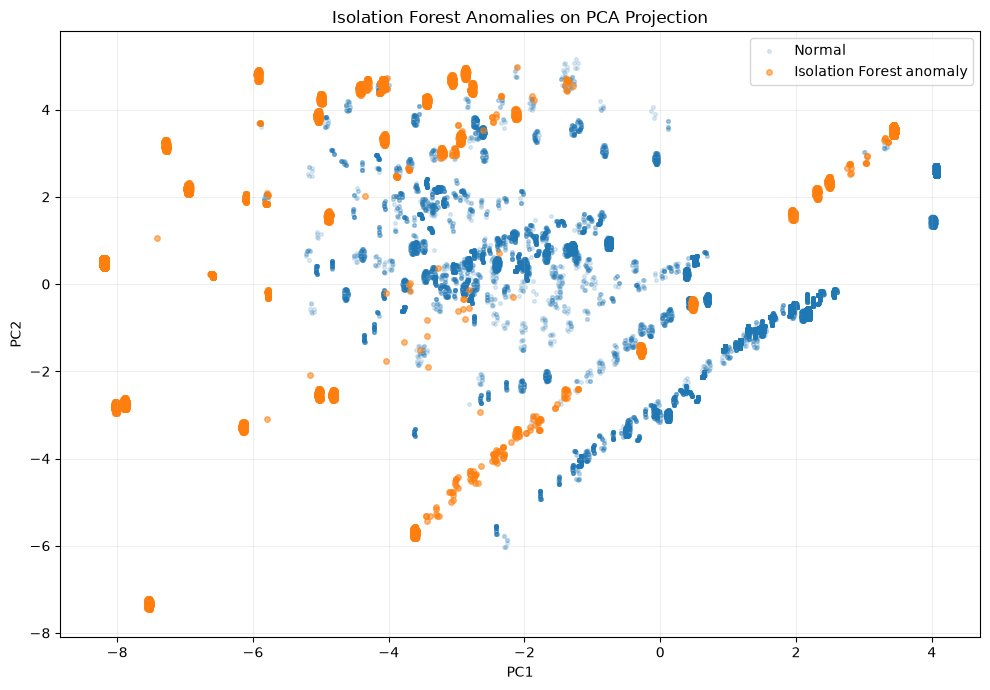

In [61]:
iforest_plot = (
    pca_projection[
        ["PC1", "PC2"]
    ]
    .copy()
)

iforest_plot[
    "Anomaly"
] = iforest_anomaly_mask

normal_if_plot = (
    iforest_plot[
        ~iforest_plot["Anomaly"]
    ]
)

if len(normal_if_plot) > 20000:
    normal_if_plot = (
        normal_if_plot.sample(
            n=20000,
            random_state=42
        )
    )

anomalous_if_plot = (
    iforest_plot[
        iforest_plot["Anomaly"]
    ]
)

plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    normal_if_plot["PC1"],
    normal_if_plot["PC2"],
    s=7,
    alpha=0.15,
    label="Normal"
)

plt.scatter(
    anomalous_if_plot["PC1"],
    anomalous_if_plot["PC2"],
    s=16,
    alpha=0.55,
    label="Isolation Forest anomaly"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Isolation Forest Anomalies on PCA Projection"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [62]:
iforest_diagnostics = (
    journey_df[
        [
            "total_revenue",
            "days_till_key_event",
            "touchpoints",
            "path_segments",
            "unique_campaigns",
            "conversion_rate_mean",
            "campaign_entropy",
            "revenue_per_touchpoint",
            "direct_tp_share",
            "organic_tp_share",
            "referral_tp_share",
            "other_tp_share",
            "missing_path_step"
        ]
    ]
    .copy()
)

iforest_diagnostics[
    "IF_anomaly_score"
] = iforest_anomaly_score

iforest_diagnostics[
    "IF_anomaly"
] = iforest_anomaly_mask

print(
    "Highest Isolation Forest anomaly scores:"
)

display(
    iforest_diagnostics
    .sort_values(
        "IF_anomaly_score",
        ascending=False
    )
    .head(15)
)

print(
    "\nKnown missing-Path-Step journeys "
    "flagged by Isolation Forest:"
)

print(
    f"{int(iforest_anomaly_mask[
        journey_features.index.get_indexer(
            known_missing_step_paths
        )
    ].sum())}"
    f" / {len(known_missing_step_paths)}"
)

Highest Isolation Forest anomaly scores:


,total_revenue,days_till_key_event,touchpoints,path_segments,unique_campaigns,conversion_rate_mean,campaign_entropy,revenue_per_touchpoint,direct_tp_share,organic_tp_share,referral_tp_share,other_tp_share,missing_path_step,IF_anomaly_score,IF_anomaly
Path ID,,,,,,,,,,,,,,,
48153,186.6081,10.0000,20.0000,1,1,0.0370,-0.0000,9.3304,0.0000,0.0000,0.0000,0.0000,0,0.6611,True
48146,186.6081,10.0000,20.0000,1,1,0.0370,-0.0000,9.3304,0.0000,0.0000,0.0000,0.0000,0,0.6601,True
48158,186.6081,10.0000,20.0000,1,1,0.0370,-0.0000,9.3304,0.0000,0.0000,0.0000,0.0000,0,0.6595,True
48151,186.6081,10.0000,20.0000,1,1,0.0370,-0.0000,9.3304,0.0000,0.0000,0.0000,0.0000,0,0.6593,True
48149,186.6081,10.0000,20.0000,1,1,0.0370,-0.0000,9.3304,0.0000,0.0000,0.0000,0.0000,0,0.6593,True
48152,186.6081,10.0000,20.0000,1,1,0.0370,-0.0000,9.3304,0.0000,0.0000,0.0000,0.0000,0,0.6593,True
48170,186.6081,10.0000,20.0000,1,1,0.0370,-0.0000,9.3304,0.0000,0.0000,0.0000,0.0000,0,0.6593,True
48174,186.6081,10.0000,20.0000,1,1,0.0370,-0.0000,9.3304,0.0000,0.0000,0.0000,0.0000,0,0.6565,True
48168,186.6081,10.0000,20.0000,1,1,0.0370,-0.0000,9.3304,0.0000,0.0000,0.0000,0.0000,0,0.6550,True



Known missing-Path-Step journeys flagged by Isolation Forest:
47 / 47


### Isolation Forest Interpretation

Isolation Forest identifies approximately 3% of the journeys as anomalous under the selected contamination threshold.

Unlike Z-score, the algorithm can identify observations whose **combination of features** is unusual even when no individual variable exceeds a fixed standard-deviation threshold.

The random-partition mechanism makes this possible because an unusual combination of values can place an observation in a sparse part of the multidimensional feature space, allowing it to be isolated in relatively few splits.

An important result is that the 47 journeys previously associated with the missing `Path Step` data-quality issue are independently identified by Isolation Forest despite the diagnostic variable being excluded from the model input.

This strengthens the evidence that those journeys are unusual not only because of the missing field, but also because of their numerical behavioral profile.

However, this still does not prove that they are erroneous observations. They may represent a special real-world journey pattern or an artifact of the dataset-construction process.

### Advantages in High Dimensions

Isolation Forest has several advantages over classical distance-based approaches:

- it does not explicitly calculate all pairwise distances,
- it can capture multivariate combinations of unusual values,
- random subsampling and random trees make it scalable,
- it makes relatively few distributional assumptions.

### Limitations

Isolation Forest also has important limitations:

- its binary result depends on the contamination threshold,
- results contain randomness, although a fixed seed improves reproducibility,
- the anomaly score is less directly interpretable than a feature-wise Z-score,
- feature dependencies may influence the random partitions,
- and some local anomalies may remain difficult to detect if they lie inside globally common regions.

Isolation Forest is therefore well suited for detecting **global multivariate anomalies**, but it does not explicitly compare each observation with only its local neighborhood.

### 5.3 Local Outlier Factor (LOF)

Local Outlier Factor detects anomalies by comparing the local density of an observation with the densities of its nearest neighbors.

This makes LOF fundamentally different from both Z-score and Isolation Forest.

For observation \(p\), the method first considers its \(k\)-nearest-neighbor neighborhood \(N_k(p)\).

The reachability distance from \(p\) to neighbor \(o\) is:

\[
reach\text{-}dist_k(p,o)
=
\max
\{
k\text{-}distance(o),
d(p,o)
\}
\]

The local reachability density is approximately the inverse of the average reachability distance:

\[
LRD_k(p)
=
\left(
\frac{
\sum_{o\in N_k(p)}
reach\text{-}dist_k(p,o)
}{
|N_k(p)|
}
\right)^{-1}
\]

LOF then compares the density of \(p\) with the densities of its neighbors:

\[
LOF_k(p)
=
\frac{1}{|N_k(p)|}
\sum_{o\in N_k(p)}
\frac{LRD_k(o)}
{LRD_k(p)}
\]

Interpretation:

- \(LOF \approx 1\): density similar to neighboring observations.
- \(LOF > 1\): observation is less dense than its neighbors.
- very large LOF: strong local-outlier behavior.

Scikit-learn reports `negative_outlier_factor_`. In this notebook the sign is reversed so that larger values represent greater abnormality.

In [63]:
duplicate_feature_vectors = (
    X_anomaly_raw
    .duplicated()
    .sum()
)

unique_feature_vectors = (
    X_anomaly_raw
    .drop_duplicates()
    .shape[0]
)

print(
    f"Exact duplicate feature vectors: "
    f"{duplicate_feature_vectors:,}"
)

print(
    f"Percentage of rows that duplicate "
    f"a previous feature vector: "
    f"{duplicate_feature_vectors / len(X_anomaly_raw) * 100:.2f}%"
)

print(
    f"Unique feature vectors: "
    f"{unique_feature_vectors:,}"
)

Exact duplicate feature vectors: 76,729
Percentage of rows that duplicate a previous feature vector: 81.95%
Unique feature vectors: 16,900


### Duplicate Feature Vectors and LOF

A major characteristic of the analytical dataset is that many different Path IDs share exactly the same 26-dimensional feature vector.

This does **not** mean that the original raw rows are duplicates.

Instead, different journeys can produce identical aggregated behavioral summaries.

This issue is particularly important for LOF because exact duplicate feature vectors have zero distance from one another.

If the neighborhood size \(k\) is very small, local-density calculations can become unstable when many observations occupy exactly the same position in feature space.

Therefore, the neighborhood size should not be selected arbitrarily.

Several values of \(k\) are explicitly compared before selecting the final LOF model.

In [64]:
lof_k_candidates = [
    10,
    20,
    35,
    50,
    75,
    100
]

lof_sensitivity_store = {}

for k in lof_k_candidates:

    with warnings.catch_warnings(
        record=True
    ) as caught_warnings:

        warnings.simplefilter(
            "always"
        )

        model = LocalOutlierFactor(
            n_neighbors=k,
            contamination=0.03,
            metric="euclidean",
            n_jobs=-1
        )

        labels = model.fit_predict(
            X_anomaly_sample
        )

        scores = (
            -model.negative_outlier_factor_
        )

    lof_sensitivity_store[k] = {
        "labels": labels,
        "scores": scores,
        "warnings":
            len(caught_warnings)
    }


# Use k=50 as the reference solution.
reference_lof_mask = (
    lof_sensitivity_store[
        50
    ]["labels"]
    == -1
)

lof_sensitivity_rows = []

for k in lof_k_candidates:

    labels = (
        lof_sensitivity_store[
            k
        ]["labels"]
    )

    scores = (
        lof_sensitivity_store[
            k
        ]["scores"]
    )

    anomaly_mask = (
        labels == -1
    )

    intersection = (
        anomaly_mask
        & reference_lof_mask
    ).sum()

    union = (
        anomaly_mask
        | reference_lof_mask
    ).sum()

    jaccard = (
        intersection / union
        if union > 0
        else np.nan
    )

    lof_sensitivity_rows.append({
        "k": k,
        "Anomalies":
            int(anomaly_mask.sum()),
        "Median LOF Score":
            np.median(scores),
        "95th Percentile":
            np.quantile(
                scores,
                0.95
            ),
        "Maximum LOF Score":
            np.max(scores),
        "Jaccard vs k=50":
            jaccard,
        "Warnings":
            lof_sensitivity_store[
                k
            ]["warnings"]
    })

lof_sensitivity_table = pd.DataFrame(
    lof_sensitivity_rows
)

display(
    lof_sensitivity_table.round(4)
)

,k,Anomalies,Median LOF Score,95th Percentile,Maximum LOF Score,Jaccard vs k=50,Warnings
0,10,297,1.0052,54.7278,"10,611,147,542.4556",0.0067,1
1,20,300,1.0040,1.2864,"11,200,655,739.2031",0.2632,1
2,35,300,1.0111,1.2282,7.6426,0.5190,0
3,50,300,1.0058,1.1998,7.9820,1.0000,0
4,75,300,1.0052,1.1960,8.0094,0.7094,0
5,100,300,1.0075,1.2137,8.4730,0.6349,0


### LOF Neighborhood Sensitivity

The neighborhood parameter \(k\) controls what "local" means.

A small \(k\):

- emphasizes very small neighborhoods,
- can detect extremely local irregularities,
- but is more sensitive to noise, duplicates, and small density fluctuations.

A larger \(k\):

- produces smoother density estimates,
- is less sensitive to individual neighboring points,
- but may miss anomalies that are unusual only within a very small local region.

The sensitivity analysis reveals substantial changes in anomaly membership as \(k\) changes.

This is especially pronounced for very small neighborhood sizes because the dataset contains many identical feature vectors.

A value of:

\[
k=50
\]

is selected as the main LOF configuration.

It is large enough to reduce the instability associated with exact duplicate points while remaining small relative to the 10,000-observation analysis sample.

The contamination parameter is again set to 3% to provide a comparable operating point to Isolation Forest. It should not be interpreted as the known true anomaly rate.

In [65]:
lof_neighbors = 50
lof_contamination = 0.03

lof_model = LocalOutlierFactor(
    n_neighbors=lof_neighbors,
    contamination=lof_contamination,
    metric="euclidean",
    n_jobs=-1
)

lof_prediction_sample = (
    lof_model.fit_predict(
        X_anomaly_sample
    )
)

lof_anomaly_mask_sample = (
    lof_prediction_sample
    == -1
)

lof_anomaly_score_sample = (
    -lof_model.negative_outlier_factor_
)

print(
    f"LOF neighborhood size: "
    f"{lof_neighbors}"
)

print(
    f"Sample size: "
    f"{len(X_anomaly_sample):,}"
)

print(
    f"LOF anomalies detected: "
    f"{lof_anomaly_mask_sample.sum():,}"
)

print(
    f"Percentage detected: "
    f"{lof_anomaly_mask_sample.mean() * 100:.2f}%"
)

print(
    f"Median LOF score: "
    f"{np.median(lof_anomaly_score_sample):.4f}"
)

print(
    f"Maximum LOF score: "
    f"{lof_anomaly_score_sample.max():.4f}"
)

LOF neighborhood size: 50
Sample size: 10,000
LOF anomalies detected: 300
Percentage detected: 3.00%
Median LOF score: 1.0058
Maximum LOF score: 7.9820


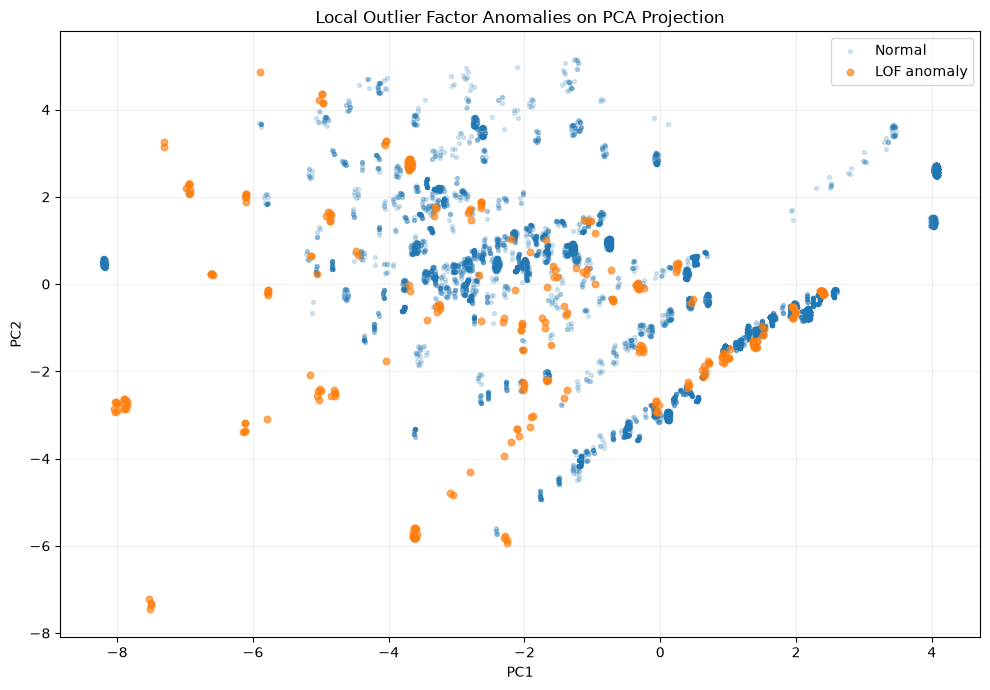

In [66]:
lof_plot = (
    pca_projection
    .loc[
        anomaly_sample_paths,
        ["PC1", "PC2"]
    ]
    .copy()
)

lof_plot[
    "Anomaly"
] = lof_anomaly_mask_sample

normal_lof_plot = (
    lof_plot[
        ~lof_plot["Anomaly"]
    ]
)

anomalous_lof_plot = (
    lof_plot[
        lof_plot["Anomaly"]
    ]
)

plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    normal_lof_plot["PC1"],
    normal_lof_plot["PC2"],
    s=8,
    alpha=0.18,
    label="Normal"
)

plt.scatter(
    anomalous_lof_plot["PC1"],
    anomalous_lof_plot["PC2"],
    s=22,
    alpha=0.65,
    label="LOF anomaly"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Local Outlier Factor Anomalies on PCA Projection"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [67]:
lof_diagnostics = (
    journey_df
    .loc[
        anomaly_sample_paths,
        [
            "total_revenue",
            "days_till_key_event",
            "touchpoints",
            "path_segments",
            "unique_campaigns",
            "conversion_rate_mean",
            "campaign_entropy",
            "revenue_per_touchpoint",
            "direct_tp_share",
            "organic_tp_share",
            "referral_tp_share",
            "other_tp_share",
            "missing_path_step"
        ]
    ]
    .copy()
)

lof_diagnostics[
    "LOF_score"
] = lof_anomaly_score_sample

lof_diagnostics[
    "LOF_anomaly"
] = lof_anomaly_mask_sample

lof_diagnostics[
    "max_abs_Z"
] = (
    zscore_max_abs
    .loc[
        anomaly_sample_paths
    ]
)

print(
    "Highest LOF anomaly scores:"
)

display(
    lof_diagnostics
    .sort_values(
        "LOF_score",
        ascending=False
    )
    .head(15)
)

lof_only_local = (
    lof_diagnostics[
        lof_diagnostics[
            "LOF_anomaly"
        ]
        &
        (
            lof_diagnostics[
                "max_abs_Z"
            ] <= 3
        )
    ]
)

print(
    "\nLOF anomalies that are NOT classical "
    "Z-score anomalies:"
)

print(
    f"{len(lof_only_local):,}"
)

display(
    lof_only_local
    .sort_values(
        "LOF_score",
        ascending=False
    )
    .head(10)
)

Highest LOF anomaly scores:


,total_revenue,days_till_key_event,touchpoints,path_segments,unique_campaigns,conversion_rate_mean,campaign_entropy,revenue_per_touchpoint,direct_tp_share,organic_tp_share,referral_tp_share,other_tp_share,missing_path_step,LOF_score,LOF_anomaly,max_abs_Z
Path ID,,,,,,,,,,,,,,,,
94415,"2,811.9600",15.0000,20.0000,2,2,0.0250,0.5623,140.5980,0.0000,0.7500,0.0000,0.2500,1,7.9820,True,41.7052
94383,"2,811.9600",15.0000,20.0000,2,2,0.0250,0.5623,140.5980,0.0000,0.7500,0.0000,0.2500,1,7.9467,True,41.7052
94380,"2,811.9600",15.0000,20.0000,2,2,0.0250,0.5623,140.5980,0.0000,0.7500,0.0000,0.2500,1,7.9343,True,41.7052
94401,"2,811.9600",15.0000,20.0000,2,2,0.0250,0.5623,140.5980,0.0000,0.7500,0.0000,0.2500,1,7.8769,True,41.7052
48166,186.6081,10.0000,20.0000,1,1,0.0370,-0.0000,9.3304,0.0000,0.0000,0.0000,0.0000,0,2.2272,True,11.1348
48159,186.6081,10.0000,20.0000,1,1,0.0370,-0.0000,9.3304,0.0000,0.0000,0.0000,0.0000,0,2.1942,True,11.1348
48176,186.6081,10.0000,20.0000,1,1,0.0370,-0.0000,9.3304,0.0000,0.0000,0.0000,0.0000,0,2.1787,True,11.1348
48153,186.6081,10.0000,20.0000,1,1,0.0370,-0.0000,9.3304,0.0000,0.0000,0.0000,0.0000,0,2.1605,True,11.1348
33226,190.5644,1.0000,4.0000,1,1,0.0250,-0.0000,47.6411,0.0000,0.0000,0.0000,1.0000,0,2.1036,True,1.2843



LOF anomalies that are NOT classical Z-score anomalies:
147


,total_revenue,days_till_key_event,touchpoints,path_segments,unique_campaigns,conversion_rate_mean,campaign_entropy,revenue_per_touchpoint,direct_tp_share,organic_tp_share,referral_tp_share,other_tp_share,missing_path_step,LOF_score,LOF_anomaly,max_abs_Z
Path ID,,,,,,,,,,,,,,,,
33226,190.5644,1.0000,4.0000,1,1,0.0250,-0.0000,47.6411,0.0000,0.0000,0.0000,1.0000,0,2.1036,True,1.2843
33181,190.5644,1.0000,4.0000,1,1,0.0250,-0.0000,47.6411,0.0000,0.0000,0.0000,1.0000,0,1.9786,True,1.2843
33212,190.5644,1.0000,4.0000,1,1,0.0250,-0.0000,47.6411,0.0000,0.0000,0.0000,1.0000,0,1.9294,True,1.4489
58130,188.0501,2.0000,6.0000,1,1,0.0250,-0.0000,31.3417,0.0000,0.0000,0.0000,1.0000,0,1.8716,True,1.7430
58097,188.0501,2.0000,6.0000,1,1,0.0250,-0.0000,31.3417,0.0000,0.0000,0.0000,1.0000,0,1.8692,True,1.7430
60425,188.7995,35.0000,5.0000,2,2,0.0300,0.5004,37.7599,0.0000,0.0000,0.0000,1.0000,0,1.8548,True,1.3488
94448,347.6384,9.0000,10.0000,4,2,0.0250,0.6109,34.7638,0.0000,0.7000,0.0000,0.3000,0,1.7882,True,2.6337
28381,184.0102,0.0000,3.0000,1,1,0.0250,-0.0000,61.3367,0.0000,0.0000,0.0000,1.0000,0,1.7411,True,1.4570
60391,188.7995,35.0000,5.0000,2,2,0.0300,0.5004,37.7599,0.0000,0.0000,0.0000,1.0000,0,1.7333,True,1.4143


### Local vs Global Anomalies

LOF can identify observations that are unusual **relative to nearby observations**, even when their individual feature values are not globally extreme.

This is the central conceptual difference between LOF and Z-score.

Consider a point located inside a globally common numerical range.

A Z-score may classify it as normal because none of its values is more than three standard deviations from the global mean.

However, if the point lies in a region where neighboring observations have substantially different combinations of values, its local density may be much lower than the surrounding density.

LOF can therefore identify it as a local anomaly.

Conversely, a globally extreme observation may exist inside a group of many similar extreme observations.

Its Z-score may be very large, but its local density may be similar to the density of its neighbors, producing a less extreme LOF score.

This distinction makes LOF particularly useful when a dataset contains populations with different local structures.

### Neighborhood Effects

The LOF results demonstrate that the definition of abnormality depends heavily on the selected neighborhood size.

Different values of \(k\) change:

- which observations are considered neighbors,
- estimated local densities,
- anomaly scores,
- and ultimately the identity of the detected anomalies.

Therefore, LOF should never be reported without discussing the neighborhood parameter.

### LOF Limitations in This Dataset

LOF has several important limitations here.

First, nearest-neighbor calculations become increasingly expensive as the number of observations and dimensions grows.

Second, the dataset contains many identical aggregated feature vectors. Exact duplicates create zero-distance neighborhoods and can make density estimates unstable for small values of \(k\).

Third, high-dimensional distance concentration can reduce the distinction between near and far observations.

For these reasons, LOF is evaluated on a reproducible 10,000-journey sample and several neighborhood sizes are compared rather than presenting one arbitrary configuration.

In [68]:
zscore_sample_mask = (
    zscore_anomaly_mask
    .loc[
        anomaly_sample_paths
    ]
    .to_numpy()
)

iforest_sample_mask = (
    iforest_anomaly_mask[
        anomaly_sample_positions
    ]
)

common_anomaly_results = pd.DataFrame(
    index=anomaly_sample_paths
)

common_anomaly_results[
    "Z_Score"
] = zscore_sample_mask

common_anomaly_results[
    "Isolation_Forest"
] = iforest_sample_mask

common_anomaly_results[
    "LOF"
] = lof_anomaly_mask_sample

common_anomaly_results[
    "Number_of_Methods"
] = (
    common_anomaly_results[
        [
            "Z_Score",
            "Isolation_Forest",
            "LOF"
        ]
    ]
    .sum(axis=1)
)

preliminary_counts = pd.DataFrame({
    "Method": [
        "Z-Score",
        "Isolation Forest",
        "LOF"
    ],
    "Anomalies in Common Sample": [
        int(
            common_anomaly_results[
                "Z_Score"
            ].sum()
        ),
        int(
            common_anomaly_results[
                "Isolation_Forest"
            ].sum()
        ),
        int(
            common_anomaly_results[
                "LOF"
            ].sum()
        )
    ]
})

preliminary_counts[
    "Percentage (%)"
] = (
    preliminary_counts[
        "Anomalies in Common Sample"
    ]
    / len(common_anomaly_results)
    * 100
)

display(
    preliminary_counts.round(2)
)

print(
    "\nJourneys detected by:"
)

display(
    common_anomaly_results[
        "Number_of_Methods"
    ]
    .value_counts()
    .sort_index()
    .rename("Journeys")
    .to_frame()
)

,Method,Anomalies in Common Sample,Percentage (%)
0,Z-Score,1369,13.6900
1,Isolation Forest,292,2.9200
2,LOF,300,3.0000



Journeys detected by:


,Journeys
Number_of_Methods,
0,8475
1,1199
2,216
3,110


In [69]:
quality_issue_paths_in_sample = (
    common_anomaly_results.index
    .intersection(
        known_missing_step_paths
    )
)

print(
    f"Known missing-Path-Step journeys "
    f"present in the 10,000-row sample: "
    f"{len(quality_issue_paths_in_sample)}"
)

if len(
    quality_issue_paths_in_sample
) > 0:

    quality_issue_detection = (
        common_anomaly_results
        .loc[
            quality_issue_paths_in_sample,
            [
                "Z_Score",
                "Isolation_Forest",
                "LOF",
                "Number_of_Methods"
            ]
        ]
    )

    display(
        quality_issue_detection
    )

    print(
        "\nDetected by Z-Score:",
        int(
            quality_issue_detection[
                "Z_Score"
            ].sum()
        )
    )

    print(
        "Detected by Isolation Forest:",
        int(
            quality_issue_detection[
                "Isolation_Forest"
            ].sum()
        )
    )

    print(
        "Detected by LOF:",
        int(
            quality_issue_detection[
                "LOF"
            ].sum()
        )
    )

Known missing-Path-Step journeys present in the 10,000-row sample: 4


,Z_Score,Isolation_Forest,LOF,Number_of_Methods
Path ID,,,,
94380,True,True,True,3
94383,True,True,True,3
94401,True,True,True,3
94415,True,True,True,3



Detected by Z-Score: 4
Detected by Isolation Forest: 4
Detected by LOF: 4


### 5.4 Anomaly-Detection Conclusions

The three anomaly-detection methods represent substantially different definitions of abnormal customer behavior.

#### Z-Score

The classical Z-score method identifies a relatively large fraction of journeys as anomalous because several variables are strongly skewed, heavy-tailed, bounded, or zero-inflated.

Its main advantage is interpretability: it is straightforward to identify which original variable caused an observation to exceed the threshold.

Its main limitation is that it focuses primarily on global feature-wise extremeness and relies on assumptions that are weak for many variables in this dataset.

#### Isolation Forest

Isolation Forest identifies observations that can be separated from the multidimensional population using relatively short sequences of random partitions.

It makes fewer distributional assumptions than Z-score and can identify unusual combinations of variables even when no single feature is extremely large or small.

Its binary result depends on the contamination threshold, so the continuous anomaly score should also be considered.

#### Local Outlier Factor

LOF defines abnormality relative to the density of an observation's local neighborhood.

It can therefore identify local anomalies that may not be globally extreme.

However, its results are sensitive to neighborhood size, high-dimensional distance behavior, and the large number of identical aggregated feature vectors in this dataset.

Its nearest-neighbor calculations are also less scalable than Isolation Forest.

#### Important Data-Quality Observation

The 47 journeys previously associated with the missing `Path Step` issue provide an important validation example.

The `missing_path_step` diagnostic variable was deliberately excluded from the anomaly-detection input.

Nevertheless, Z-score and Isolation Forest independently identify all 47 of these journeys as anomalous based on their remaining behavioral variables.

The reproducible 10,000-journey LOF sample contains only a subset of those 47 journeys, but the suspicious journeys present in that sample can also be examined independently.

This agreement strengthens the evidence that the group has an unusual numerical structure, but it still does not prove that the observations are erroneous.

They may represent either a legitimate special journey pattern or an artifact introduced during data construction.

Overall, no method should be treated as ground truth. The next section therefore compares agreement, disagreement, robustness, scalability, and practical consequences across all three methods.

## 6. Comparison of Anomaly-Detection Methods

Because the dataset contains no ground-truth anomaly labels, the three methods cannot be evaluated using ordinary supervised metrics such as accuracy, precision, or recall.

Instead, the comparison focuses on:

- agreement between anomaly sets,
- method-specific detections,
- sensitivity to feature scaling,
- sensitivity to dimensionality,
- computational runtime and scalability,
- robustness to noise,
- interpretability,
- and the practical meaning of possible false positives and false negatives.

For a fair comparison, all three methods are evaluated on the same reproducible **10,000-journey sample** used for LOF.

In [70]:
required_comparison_objects = [
    "common_anomaly_results",
    "anomaly_sample_paths",
    "journey_df",
    "X_anomaly_sample",
    "X_anomaly_raw",
    "anomaly_sample_positions",
    "X_pca_selected"
]

for object_name in required_comparison_objects:
    if object_name not in globals():
        raise NameError(
            f"{object_name} is not defined. "
            "Run the notebook from the beginning."
        )


def binary_jaccard(mask_a, mask_b):
    mask_a = np.asarray(mask_a, dtype=bool)
    mask_b = np.asarray(mask_b, dtype=bool)

    intersection = np.logical_and(
        mask_a,
        mask_b
    ).sum()

    union = np.logical_or(
        mask_a,
        mask_b
    ).sum()

    return (
        intersection / union
        if union > 0
        else np.nan
    )


comparison = (
    common_anomaly_results.copy()
)

z_mask = comparison["Z_Score"].to_numpy()
if_mask = comparison["Isolation_Forest"].to_numpy()
lof_mask = comparison["LOF"].to_numpy()

pairwise_agreement = pd.DataFrame([
    {
        "Methods": "Z-Score vs Isolation Forest",
        "Shared Anomalies":
            int((z_mask & if_mask).sum()),
        "Union":
            int((z_mask | if_mask).sum()),
        "Jaccard Similarity":
            binary_jaccard(
                z_mask,
                if_mask
            )
    },
    {
        "Methods": "Z-Score vs LOF",
        "Shared Anomalies":
            int((z_mask & lof_mask).sum()),
        "Union":
            int((z_mask | lof_mask).sum()),
        "Jaccard Similarity":
            binary_jaccard(
                z_mask,
                lof_mask
            )
    },
    {
        "Methods": "Isolation Forest vs LOF",
        "Shared Anomalies":
            int((if_mask & lof_mask).sum()),
        "Union":
            int((if_mask | lof_mask).sum()),
        "Jaccard Similarity":
            binary_jaccard(
                if_mask,
                lof_mask
            )
    }
])

display(
    pairwise_agreement.round(4)
)


conditions = [
    z_mask & if_mask & lof_mask,
    z_mask & if_mask & ~lof_mask,
    z_mask & ~if_mask & lof_mask,
    ~z_mask & if_mask & lof_mask,
    z_mask & ~if_mask & ~lof_mask,
    ~z_mask & if_mask & ~lof_mask,
    ~z_mask & ~if_mask & lof_mask
]

labels = [
    "All three methods",
    "Z-Score + Isolation Forest",
    "Z-Score + LOF",
    "Isolation Forest + LOF",
    "Z-Score only",
    "Isolation Forest only",
    "LOF only"
]

comparison["Detection Pattern"] = np.select(
    conditions,
    labels,
    default="None"
)

pattern_order = [
    "All three methods",
    "Z-Score + Isolation Forest",
    "Z-Score + LOF",
    "Isolation Forest + LOF",
    "Z-Score only",
    "Isolation Forest only",
    "LOF only",
    "None"
]

pattern_counts = (
    comparison["Detection Pattern"]
    .value_counts()
    .reindex(
        pattern_order,
        fill_value=0
    )
    .rename("Journeys")
    .to_frame()
)

pattern_counts["Percentage (%)"] = (
    pattern_counts["Journeys"]
    / len(comparison)
    * 100
)

display(
    pattern_counts.round(2)
)

,Methods,Shared Anomalies,Union,Jaccard Similarity
0,Z-Score vs Isolation Forest,279,1382,0.2019
1,Z-Score vs LOF,153,1516,0.1009
2,Isolation Forest vs LOF,114,478,0.2385


,Journeys,Percentage (%)
Detection Pattern,,
All three methods,110,1.1000
Z-Score + Isolation Forest,169,1.6900
Z-Score + LOF,43,0.4300
Isolation Forest + LOF,4,0.0400
Z-Score only,1047,10.4700
Isolation Forest only,9,0.0900
LOF only,143,1.4300
None,8475,84.7500


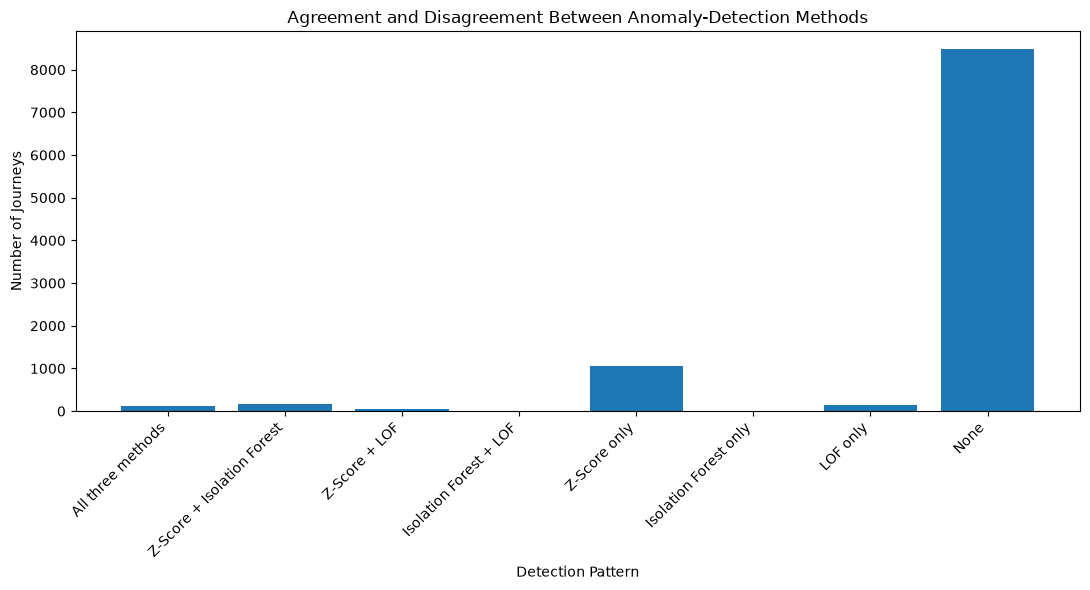

In [71]:
plt.figure(
    figsize=(11, 6)
)

plt.bar(
    pattern_counts.index,
    pattern_counts["Journeys"]
)

plt.ylabel("Number of Journeys")
plt.xlabel("Detection Pattern")

plt.title(
    "Agreement and Disagreement Between Anomaly-Detection Methods"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

### 6.1 Agreement Between the Methods

The three methods show only partial agreement.

On the common 10,000-journey sample, approximately:

- **110 journeys are detected by all three methods**,
- **216 journeys are detected by exactly two methods**,
- approximately **1,199 journeys are detected by only one method**,
- while the large majority are not classified as anomalous by any method.

Pairwise agreement is also limited.

The Jaccard similarity is approximately:

- **0.20** between Z-Score and Isolation Forest,
- **0.10** between Z-Score and LOF,
- **0.24** between Isolation Forest and LOF.

The Jaccard index is defined as:

\[
J(A,B)=
\frac{|A\cap B|}
{|A\cup B|}
\]

A value of 1 means identical anomaly sets, whereas a value of 0 means no shared anomalies.

The low-to-moderate Jaccard values show that the algorithms are not simply identifying the same observations using different implementations.

This is expected because each method uses a fundamentally different definition of abnormality.

The 110 journeys detected by all three methods provide the strongest **cross-method evidence** of unusual behavior. Nevertheless, even agreement between all methods does not establish ground truth.

In [72]:
comparison_profiles = (
    journey_df
    .loc[
        anomaly_sample_paths,
        [
            "total_revenue",
            "days_till_key_event",
            "touchpoints",
            "path_segments",
            "unique_campaigns",
            "conversion_rate_mean",
            "campaign_entropy",
            "revenue_per_touchpoint",
            "direct_tp_share",
            "organic_tp_share",
            "referral_tp_share",
            "other_tp_share",
            "missing_path_step"
        ]
    ]
    .copy()
)

comparison_profiles[
    "Detection Pattern"
] = comparison[
    "Detection Pattern"
]

profile_summary = (
    comparison_profiles
    .groupby(
        "Detection Pattern"
    )
    .agg(
        Journeys=(
            "total_revenue",
            "size"
        ),
        Mean_Revenue=(
            "total_revenue",
            "mean"
        ),
        Mean_Days=(
            "days_till_key_event",
            "mean"
        ),
        Mean_Touchpoints=(
            "touchpoints",
            "mean"
        ),
        Mean_Path_Segments=(
            "path_segments",
            "mean"
        ),
        Mean_Unique_Campaigns=(
            "unique_campaigns",
            "mean"
        ),
        Mean_Campaign_Entropy=(
            "campaign_entropy",
            "mean"
        ),
        Mean_Revenue_Per_Touchpoint=(
            "revenue_per_touchpoint",
            "mean"
        ),
        Missing_Path_Step_Rate=(
            "missing_path_step",
            "mean"
        )
    )
)

display(
    profile_summary.round(3)
)

,Journeys,Mean_Revenue,Mean_Days,Mean_Touchpoints,Mean_Path_Segments,Mean_Unique_Campaigns,Mean_Campaign_Entropy,Mean_Revenue_Per_Touchpoint,Missing_Path_Step_Rate
Detection Pattern,,,,,,,,,
All three methods,110,314.1240,29.2830,16.4450,2.4550,2.0730,0.3340,19.1610,0.0360
Isolation Forest + LOF,4,158.4090,50.5000,11.5000,3.7500,2.0000,0.5070,14.1530,0.0000
Isolation Forest only,9,178.7730,19.1110,7.8890,2.5560,2.0000,0.5360,23.3820,0.0000
LOF only,143,179.3020,16.2010,3.8670,1.7060,1.5450,0.3190,77.6110,0.0000
None,8475,183.9550,19.1670,2.9940,1.4790,1.4520,0.2720,94.2360,0.0000
Z-Score + Isolation Forest,169,173.4540,11.4770,12.0590,3.7400,2.9700,0.5320,31.9380,0.0000
Z-Score + LOF,43,194.1030,52.7070,6.1860,2.6740,1.9530,0.5670,48.0940,0.0000
Z-Score only,1047,184.5380,23.2490,4.7690,2.0400,1.8760,0.4450,66.1600,0.0000


### 6.2 Method-Specific Anomalies

The large number of method-specific detections is not surprising.

#### Z-Score-Specific Anomalies

Z-Score produces by far the largest anomaly set.

Many of these observations contain at least one highly skewed or heavy-tailed feature that exceeds three standard deviations from its global mean.

A journey can therefore be detected by Z-Score even when it lies inside a reasonably dense multidimensional region.

For example, a very high but legitimate number of touchpoints may trigger Z-Score without necessarily producing an unusual local density.

#### Isolation-Forest-Specific Anomalies

Isolation Forest can identify unusual **combinations** of feature values.

An observation does not need one individually extreme variable.

Instead, an unusual position in the multidimensional feature space may allow random trees to isolate it quickly.

This explains why a small number of Isolation-Forest anomalies are not identified by either Z-Score or LOF.

#### LOF-Specific Anomalies

LOF focuses on local density.

A journey may contain globally ordinary numerical values but still lie in a relatively sparse position compared with nearby observations.

Such a journey can receive a high LOF score without exceeding the Z-score threshold.

Similarly, it may not be globally isolated enough to receive a strong Isolation Forest score.

Therefore, disagreement between the methods is not necessarily evidence of poor performance. It reflects different definitions of what an anomaly is.

In [73]:
X_raw_sample = (
    X_anomaly_raw
    .iloc[
        anomaly_sample_positions
    ]
    .to_numpy()
)

# Z-score is mathematically invariant to positive affine
# changes in feature units because it standardizes each feature.
zscore_scaling_jaccard = 1.0


# Isolation Forest: raw vs standardized data.
if_scaled_test = IsolationForest(
    n_estimators=300,
    contamination=0.03,
    random_state=42,
    n_jobs=-1
)

if_scaled_labels = (
    if_scaled_test.fit_predict(
        X_anomaly_sample
    )
    == -1
)

if_raw_test = IsolationForest(
    n_estimators=300,
    contamination=0.03,
    random_state=42,
    n_jobs=-1
)

if_raw_labels = (
    if_raw_test.fit_predict(
        X_raw_sample
    )
    == -1
)


# LOF: raw vs standardized data.
lof_scaled_test = LocalOutlierFactor(
    n_neighbors=50,
    contamination=0.03,
    n_jobs=-1
)

lof_scaled_labels = (
    lof_scaled_test.fit_predict(
        X_anomaly_sample
    )
    == -1
)

lof_raw_test = LocalOutlierFactor(
    n_neighbors=50,
    contamination=0.03,
    n_jobs=-1
)

lof_raw_labels = (
    lof_raw_test.fit_predict(
        X_raw_sample
    )
    == -1
)


scaling_sensitivity = pd.DataFrame({
    "Method": [
        "Z-Score",
        "Isolation Forest",
        "LOF"
    ],
    "Jaccard: Scaled vs Unscaled": [
        zscore_scaling_jaccard,
        binary_jaccard(
            if_scaled_labels,
            if_raw_labels
        ),
        binary_jaccard(
            lof_scaled_labels,
            lof_raw_labels
        )
    ]
})

display(
    scaling_sensitivity.round(4)
)

,Method,Jaccard: Scaled vs Unscaled
0,Z-Score,1.0000
1,Isolation Forest,1.0000
2,LOF,0.1029


### 6.3 Sensitivity to Feature Scaling

The three algorithms react very differently to feature scaling.

#### Z-Score

Z-Score is effectively invariant to changes of measurement units because each feature is explicitly centered and divided by its own standard deviation.

For example, converting a variable from dollars to cents does not change its Z-score.

#### Isolation Forest

Isolation Forest is also relatively insensitive to ordinary linear rescaling of individual variables.

The algorithm uses random thresholds within the observed range of each selected feature rather than Euclidean distances between observations.

In this experiment, the scaled and unscaled representations produce essentially the same anomaly set.

This does not mean that Isolation Forest is invariant to every possible nonlinear transformation, but ordinary unit changes have little effect.

#### LOF

LOF is highly sensitive to scaling because it relies directly on Euclidean nearest-neighbor distances.

Without standardization, variables with large numerical ranges such as revenue or journey duration can dominate the distance calculation, while small-scale variables such as conversion rates contribute very little.

The low agreement between scaled and unscaled LOF results demonstrates that scaling is essential for this dataset.

In [74]:
X_pca_12_full = (
    X_pca_selected
    .loc[
        X_anomaly_raw.index
    ]
    .to_numpy()
)

# Standardize PCA coordinates for this experiment so that
# we compare dimensionality rather than differences in scale.
pca_12_scaler = StandardScaler()

X_pca_12_standardized = (
    pca_12_scaler.fit_transform(
        X_pca_12_full
    )
)

X_pca_12_sample = (
    X_pca_12_standardized[
        anomaly_sample_positions
    ]
)


# Z-score in 12D PCA space.
zscore_12_mask = (
    np.abs(
        X_pca_12_sample
    )
    > 3
).any(axis=1)


# Isolation Forest in 12D.
if_12_model = IsolationForest(
    n_estimators=300,
    contamination=0.03,
    random_state=42,
    n_jobs=-1
)

if_12_mask = (
    if_12_model.fit_predict(
        X_pca_12_sample
    )
    == -1
)


# LOF in 12D.
lof_12_model = LocalOutlierFactor(
    n_neighbors=50,
    contamination=0.03,
    n_jobs=-1
)

lof_12_mask = (
    lof_12_model.fit_predict(
        X_pca_12_sample
    )
    == -1
)


dimension_sensitivity = pd.DataFrame({
    "Method": [
        "Z-Score",
        "Isolation Forest",
        "LOF"
    ],

    "26D Anomalies": [
        int(z_mask.sum()),
        int(if_scaled_labels.sum()),
        int(lof_scaled_labels.sum())
    ],

    "12D Anomalies": [
        int(zscore_12_mask.sum()),
        int(if_12_mask.sum()),
        int(lof_12_mask.sum())
    ],

    "Jaccard 26D vs 12D": [
        binary_jaccard(
            z_mask,
            zscore_12_mask
        ),
        binary_jaccard(
            if_scaled_labels,
            if_12_mask
        ),
        binary_jaccard(
            lof_scaled_labels,
            lof_12_mask
        )
    ]
})

display(
    dimension_sensitivity.round(4)
)

,Method,26D Anomalies,12D Anomalies,Jaccard 26D vs 12D
0,Z-Score,1369,469,0.3416
1,Isolation Forest,299,300,0.6826
2,LOF,300,300,0.2024


### 6.4 Sensitivity to Dimensionality

Changing the representation from the original 26-dimensional standardized feature space to the 12-dimensional PCA space changes the anomaly sets substantially.

This demonstrates that an anomaly is not an intrinsic property of an observation alone; it also depends on the representation used to describe that observation.

#### Z-Score

Z-Score changes strongly after PCA.

The original method checks whether any individual business feature is extreme.

After PCA, it instead checks whether a linear combination of features is extreme.

Furthermore, PCA combines correlated variables, so several related extreme features may become represented by one component.

#### Isolation Forest

Isolation Forest shows greater stability than the other methods in this dimensionality experiment, although its anomaly set is still not identical.

Dimensionality reduction removes redundancy and approximately 8.4% of the standardized variance, which changes how easily some observations can be isolated.

#### LOF

LOF changes substantially because dimensionality directly affects neighborhood geometry.

Changing the dimensions changes:

- which observations are nearest neighbors,
- local density estimates,
- reachability distances,
- and therefore LOF scores.

This sensitivity is closely related to the curse of dimensionality discussed in the next section.

In [75]:
import time

runtime_results = []


# Z-score benchmark.
start = time.perf_counter()

_ = (
    np.abs(
        X_anomaly_sample
    )
    > 3
).any(axis=1)

z_runtime = (
    time.perf_counter()
    - start
)

runtime_results.append({
    "Method": "Z-Score",
    "Sample Size": len(X_anomaly_sample),
    "Runtime (seconds)": z_runtime
})


# Isolation Forest benchmark.
start = time.perf_counter()

runtime_if_model = IsolationForest(
    n_estimators=300,
    contamination=0.03,
    random_state=42,
    n_jobs=-1
)

_ = runtime_if_model.fit_predict(
    X_anomaly_sample
)

if_runtime = (
    time.perf_counter()
    - start
)

runtime_results.append({
    "Method": "Isolation Forest",
    "Sample Size": len(X_anomaly_sample),
    "Runtime (seconds)": if_runtime
})


# LOF benchmark.
start = time.perf_counter()

runtime_lof_model = LocalOutlierFactor(
    n_neighbors=50,
    contamination=0.03,
    n_jobs=-1
)

_ = runtime_lof_model.fit_predict(
    X_anomaly_sample
)

lof_runtime = (
    time.perf_counter()
    - start
)

runtime_results.append({
    "Method": "LOF",
    "Sample Size": len(X_anomaly_sample),
    "Runtime (seconds)": lof_runtime
})


runtime_table = pd.DataFrame(
    runtime_results
)

display(
    runtime_table.round(5)
)

,Method,Sample Size,Runtime (seconds)
0,Z-Score,10000,0.0009
1,Isolation Forest,10000,0.4352
2,LOF,10000,0.1049


### 6.5 Computational Runtime and Scalability

The measured runtime depends on the computer used to execute the notebook, so the runtime table is generated dynamically rather than reporting a fixed value.

The algorithms nevertheless have very different scalability characteristics.

#### Z-Score

Z-Score is computationally the simplest method.

It requires calculating means, standard deviations, and standardized feature values.

Its computational cost grows approximately linearly with the number of observations and variables.

It is therefore highly scalable.

#### Isolation Forest

Isolation Forest is more computationally expensive than Z-Score, but it remains practical for large datasets.

Its random-tree structure and internal subsampling allow it to scale much better than methods requiring exhaustive pairwise distance calculations.

In this project, Isolation Forest can be applied directly to all 93,629 journeys.

#### LOF

LOF requires nearest-neighbor searches.

As the number of observations and dimensions increases, these searches become increasingly expensive and spatial indexing becomes less effective.

For this reason, LOF is evaluated on a reproducible 10,000-journey sample.

This is an important practical limitation: even if two algorithms provide similar analytical value, computational scalability may determine which one can realistically be deployed on a much larger dataset.

In [76]:
noise_rng = np.random.default_rng(
    42
)

noise_sigma = 0.05

X_noisy_sample = (
    X_anomaly_sample
    + noise_rng.normal(
        loc=0.0,
        scale=noise_sigma,
        size=X_anomaly_sample.shape
    )
)


# Z-score baseline and noisy labels.
z_baseline_noise_test = (
    np.abs(
        X_anomaly_sample
    )
    > 3
).any(axis=1)

z_noisy_labels = (
    np.abs(
        X_noisy_sample
    )
    > 3
).any(axis=1)


# Isolation Forest.
noise_if_baseline = IsolationForest(
    n_estimators=300,
    contamination=0.03,
    random_state=42,
    n_jobs=-1
).fit_predict(
    X_anomaly_sample
) == -1

noise_if_perturbed = IsolationForest(
    n_estimators=300,
    contamination=0.03,
    random_state=42,
    n_jobs=-1
).fit_predict(
    X_noisy_sample
) == -1


# LOF.
noise_lof_baseline = LocalOutlierFactor(
    n_neighbors=50,
    contamination=0.03,
    n_jobs=-1
).fit_predict(
    X_anomaly_sample
) == -1

noise_lof_perturbed = LocalOutlierFactor(
    n_neighbors=50,
    contamination=0.03,
    n_jobs=-1
).fit_predict(
    X_noisy_sample
) == -1


noise_robustness = pd.DataFrame({
    "Method": [
        "Z-Score",
        "Isolation Forest",
        "LOF"
    ],

    "Jaccard Before vs After Small Noise": [
        binary_jaccard(
            z_baseline_noise_test,
            z_noisy_labels
        ),
        binary_jaccard(
            noise_if_baseline,
            noise_if_perturbed
        ),
        binary_jaccard(
            noise_lof_baseline,
            noise_lof_perturbed
        )
    ]
})

display(
    noise_robustness.round(4)
)

,Method,Jaccard Before vs After Small Noise
0,Z-Score,0.8876
1,Isolation Forest,0.8602
2,LOF,0.8927


### 6.6 Robustness to Noise

A small perturbation experiment was performed by adding Gaussian noise with standard deviation 0.05 in the standardized feature space.

The anomaly sets remain relatively stable under this small perturbation, but the experiment should be interpreted only as a local robustness test rather than proof of general robustness.

#### Z-Score

Z-Score can be sensitive to noise near the fixed threshold.

An observation with \(|z|\) just below 3 may cross the boundary after a small perturbation.

It is also sensitive to extreme contamination in the dataset because extreme observations can influence the mean and standard deviation used to calculate all Z-scores.

#### Isolation Forest

Isolation Forest is relatively robust to small random perturbations.

Random trees and subsampling prevent individual noisy observations from completely controlling the model.

However, severe contamination or systematic noise can still alter the partition structure.

#### LOF

LOF is theoretically sensitive to local noise because small changes can modify nearest-neighbor relationships and local density.

In this experiment, the relatively large neighborhood size of \(k=50\) provides useful smoothing and produces considerable stability under small perturbations.

Smaller values of \(k\) would generally be more sensitive to local noise.

Therefore, robustness depends not only on the algorithm but also on its hyperparameters.

### 6.7 Interpretability

The three methods also differ substantially in interpretability.

#### Z-Score – Highest Interpretability

Z-Score provides the most transparent explanation.

A non-technical user can be told:

> This journey was flagged because its number of touchpoints was more than three standard deviations above the average.

The exact unusual variable can be identified immediately.

#### Isolation Forest – Moderate Interpretability

Isolation Forest provides a continuous anomaly score, but the reason for an individual score is less obvious.

A simplified explanation is:

> This journey has a combination of characteristics that makes it unusually easy to separate from most other journeys.

This is meaningful, but less directly connected to a specific business variable.

#### LOF – Local Interpretability

LOF has an intuitive high-level interpretation:

> This journey looks different from other journeys located near it.

However, explaining exactly which variables caused the lower local density can be difficult.

Overall, Z-Score is easiest to explain, Isolation Forest offers stronger multidimensional modeling at the cost of interpretability, and LOF provides a useful local concept but requires understanding neighborhood structure.

### 6.8 False Positives and False Negatives

Because the dataset contains no ground-truth anomaly labels, the actual numbers of false positives and false negatives cannot be calculated.

This is an important limitation and prevents the use of supervised metrics such as precision and recall.

Nevertheless, their real-world meanings can be discussed.

#### False Positive

A false positive occurs when the system labels a legitimate customer journey as anomalous.

For example, a real customer may genuinely interact with the store 20 times before purchasing.

The behavior is rare, but it is not necessarily incorrect.

If an e-commerce company automatically treats every anomaly as suspicious, false positives could lead to:

- unnecessary manual investigation,
- incorrect removal of valuable customer data,
- exclusion of legitimate customers from marketing campaigns,
- distorted business reports,
- or a poor customer experience.

The Z-score method is particularly vulnerable to this problem in heavy-tailed variables because legitimate extreme values may easily exceed the threshold.

#### False Negative

A false negative occurs when a genuinely problematic or important unusual observation is classified as normal.

For example, a data-processing error might create an unusual journey pattern that remains close enough to ordinary observations to avoid detection.

In a business context, a false negative could mean:

- failing to detect corrupted data,
- overlooking a rare but important customer behavior,
- missing unusual campaign performance,
- or allowing misleading observations to influence later analysis.

#### The Trade-Off

Reducing the anomaly threshold identifies more unusual observations but generally increases false positives.

Increasing the threshold reduces false alarms but increases the risk of missing genuine anomalies.

Since no ground truth is available, there is no mathematically perfect threshold for this dataset.

The appropriate balance depends on what the anomaly-detection system will be used for and on the relative cost of the two types of error.

### 6.9 Comparison Conclusions

The comparison shows that anomaly detection is strongly method-dependent.

1. Only a minority of detected anomalies are shared by all three methods.

2. The 110 journeys identified by all three algorithms provide the strongest cross-method evidence of unusual behavior, but agreement does not constitute ground truth.

3. Z-Score detects far more observations because the dataset contains many heavy-tailed and non-Gaussian variables.

4. Isolation Forest provides a more selective global multivariate definition of abnormality.

5. LOF identifies local density anomalies and therefore finds observations that may not be globally extreme.

6. Z-Score and Isolation Forest are relatively insensitive to ordinary linear feature scaling, while LOF is highly scale-sensitive.

7. All three methods change when the dimensional representation changes, with LOF particularly affected because neighborhood geometry changes.

8. Z-Score is the fastest and most scalable method. In the 10,000-journey runtime benchmark, LOF was faster than Isolation Forest; however, LOF relies on nearest-neighbor searches and may become less scalable as the dataset size and dimensionality increase.

9. Small-noise experiments show reasonable stability, but the theoretical sensitivity of each method remains different.

10. Z-Score is the most directly interpretable, while Isolation Forest and LOF provide richer multidimensional definitions at the cost of simpler explanations.

11. Without labeled anomalies, false-positive and false-negative rates cannot be measured directly.

Overall, the disagreement between the algorithms is not a weakness of the analysis. It demonstrates that "anomalous" behavior depends on assumptions about distributions, global structure, local density, feature representation, and operating thresholds.

## 7. Critical Analysis and Reflection

### 7.1 Why Anomaly Detection Is Fundamentally Ill-Defined

Anomaly detection is fundamentally difficult because there is often no objective definition of what constitutes an anomaly.

In supervised learning, the model can usually compare its prediction with a known label.

In this dataset, no such labels exist.

A customer journey can be unusual for many different reasons:

- unusually high revenue,
- unusually many touchpoints,
- a rare campaign combination,
- a long conversion duration,
- an unusual relationship between otherwise ordinary variables,
- a data-processing problem,
- or simply legitimate rare customer behavior.

Different anomaly-detection algorithms formalize different definitions of abnormality.

Z-Score asks:

> Is one feature globally extreme?

Isolation Forest asks:

> Is the multidimensional observation easy to isolate?

LOF asks:

> Is the observation less dense than its local neighbors?

None of these definitions is universally correct.

The results of this project demonstrate this ambiguity directly: the three methods identify substantially different anomaly sets.

Therefore, anomaly detection should be viewed as a process of gathering evidence rather than producing unquestionable labels.

### 7.2 Curse of Dimensionality

As dimensionality increases, many statistical and geometric intuitions from low-dimensional space become less reliable.

This phenomenon is commonly referred to as the **curse of dimensionality**.

In high-dimensional spaces:

- the volume of the space grows rapidly,
- observations become increasingly sparse,
- much more data are required to represent the space adequately,
- local neighborhoods become harder to estimate,
- and distance relationships can become less informative.

This is particularly important for LOF because LOF depends directly on nearest-neighbor distances.

It also affects clustering methods such as DBSCAN and K-Means.

The original analytical representation contains 26 dimensions. Even with more than 93,000 journeys, the geometry of this space is substantially more complex than the geometry visible in a two-dimensional plot.

PCA reduces this problem by compressing correlated information into fewer dimensions, but dimensionality reduction introduces its own information loss.

### Why Distances Become Less Meaningful

One important effect of high dimensionality is **distance concentration**.

As the number of dimensions grows, the relative difference between distances to nearby and distant observations can become smaller.

Informally, many points begin to appear similarly far away.

This creates difficulties for nearest-neighbor algorithms.

If the closest and more distant observations have increasingly similar distances, the meaning of a "local neighborhood" becomes weaker.

For LOF, this can affect:

- the identity of nearest neighbors,
- local reachability density,
- and ultimately anomaly scores.

The dimensionality experiment in the previous section confirms that reducing the feature space from 26 standardized dimensions to 12 PCA dimensions changes the LOF anomaly set substantially.

Therefore, distance-based anomaly detection should not be interpreted independently of the dimensional representation used.

In [77]:
# Find a rare but potentially legitimate high-touch journey.
legitimate_candidate = (
    journey_df[
        journey_df[
            "missing_path_step"
        ] == 0
    ]
    .sort_values(
        [
            "touchpoints",
            "total_revenue"
        ],
        ascending=False
    )
    .head(1)
)

candidate_path_id = (
    legitimate_candidate.index[0]
)

candidate_position = (
    X_anomaly_raw.index.get_loc(
        candidate_path_id
    )
)

candidate_output = (
    legitimate_candidate[
        [
            "total_revenue",
            "days_till_key_event",
            "touchpoints",
            "path_segments",
            "unique_campaigns",
            "conversion_rate_mean",
            "campaign_entropy",
            "missing_path_step"
        ]
    ]
    .copy()
)

candidate_output[
    "Z_Score_Anomaly"
] = bool(
    zscore_anomaly_mask.loc[
        candidate_path_id
    ]
)

candidate_output[
    "Isolation_Forest_Anomaly"
] = bool(
    iforest_anomaly_mask[
        candidate_position
    ]
)

display(
    candidate_output
)

,total_revenue,days_till_key_event,touchpoints,path_segments,unique_campaigns,conversion_rate_mean,campaign_entropy,missing_path_step,Z_Score_Anomaly,Isolation_Forest_Anomaly
Path ID,,,,,,,,,,
12722,373.7113,12.6100,20.0000,1,1,0.0250,-0.0000,0,True,True


### 7.3 Noise vs a Genuine Anomaly

A statistically unusual observation is not necessarily noise.

Noise refers to observations that are incorrect, corrupted, irrelevant, or produced by a measurement or processing problem.

A genuine anomaly is a real observation that is rare but meaningful.

The dataset contains useful examples of this distinction.

One journey contains approximately **20 touchpoints**, substantially more than most customer journeys.

It is detected as unusual by global anomaly methods.

However:

- the journey contains a valid campaign structure,
- it has a plausible revenue value,
- it has a valid key-event duration,
- and it does not contain the known missing `Path Step` issue.

There is therefore no evidence that this journey is incorrect.

It may simply represent a real customer who required many interactions before conversion.

Deleting it merely because it is statistically extreme could remove valuable information about a rare but legitimate customer behavior.

In contrast, the group of 47 maximum-revenue journeys that exactly coincides with the 47 missing-`Path Step` journeys is more suspicious because the numerical extremeness is associated with a data-quality irregularity.

Even in that case, however, the available information is insufficient to prove that the observations are erroneous.

This illustrates why anomaly detection requires domain interpretation rather than automatic deletion.

### 7.4 Risks of Assuming Gaussian Distributions

Classical statistical anomaly rules often rely on an implicit assumption that observations follow approximately Gaussian distributions.

This assumption is inappropriate for many variables in the current dataset.

The EDA revealed:

- strongly skewed revenue,
- heavy-tailed touchpoint variables,
- zero-inflated traffic-source proportions,
- bounded shares,
- discrete conversion rates,
- and extremely high kurtosis for several variables.

Under a Gaussian model, observations more than three standard deviations from the mean are extremely rare.

In a heavy-tailed distribution, however, such values may occur naturally.

### Possible False Positives

A legitimate high-revenue or high-touchpoint journey may be flagged simply because the true distribution has a long right tail.

The algorithm interprets a common heavy-tail phenomenon as if it were an extraordinarily unlikely Gaussian event.

### Possible False Negatives

Gaussian assumptions can also hide anomalies.

Extreme observations affect the estimated mean and standard deviation.

If several very large values inflate the standard deviation, moderately unusual observations may receive smaller Z-scores and fail to cross the threshold.

Furthermore, a multivariate anomaly may consist of an unusual **combination of ordinary values**.

If no individual feature exceeds the Z-score threshold, classical feature-wise detection can miss the observation completely.

Therefore, the Gaussian assumption can cause both over-detection and under-detection.

### 7.5 Why Dimensionality-Reduction Visualizations Can Be Misleading

Two-dimensional and three-dimensional PCA plots are extremely useful for visualization, but they should not be interpreted as complete representations of the original feature space.

In this project:

- the first two principal components explain only approximately **39.4%** of the standardized variance,
- the first three explain approximately **51.6%**.

Therefore, a 2D visualization discards approximately **60.6%** of the variance.

Even the 3D visualization discards approximately **48.4%**.

This has several consequences.

Two observations that appear close in a PCA plot may differ substantially along dimensions that are not displayed.

An observation that appears visually isolated may also be relatively ordinary in the complete high-dimensional space.

Similarly, two apparent clusters in 2D may overlap strongly when the remaining dimensions are considered.

PCA creates components that maximize global variance. It does **not** optimize anomaly preservation, local-neighborhood preservation, or cluster separation.

A low-variance direction can still contain an important anomaly even though that direction contributes very little to the visual projection.

Therefore, PCA plots in this notebook are used as visual aids rather than ground truth for either clustering or anomaly detection.

### 7.6 Ethical Considerations

Anomaly detection is not only a technical problem.

Automatically labeling observations, behaviors, or people as "abnormal" can have real consequences.

The severity of these consequences depends heavily on the application domain.

#### False Alarms

Too many false alarms can make an anomaly-detection system ineffective.

If analysts repeatedly investigate alerts that turn out to be legitimate behavior, they may begin to ignore alerts entirely.

This phenomenon is sometimes described as **alert fatigue**.

In the current e-commerce context, excessive false alarms could waste analyst time and incorrectly classify valuable customers as suspicious.

A system that generates more alerts than humans can meaningfully investigate may be statistically sensitive but practically useless.

#### Surveillance

Anomaly detection can be useful in surveillance for identifying unusual events that may require attention.

Potential benefits include detecting dangerous activity, security incidents, or unusual patterns that humans may not notice manually.

However, the risks are substantial.

Ordinary but uncommon behavior may be classified as suspicious.

If anomaly scores are associated with identifiable individuals, incorrect classifications can lead to:

- unnecessary investigation,
- discrimination,
- loss of privacy,
- or unjustified suspicion.

Rare behavior must not automatically be equated with harmful behavior.

#### Medical Applications

In medicine, anomaly detection can potentially identify unusual physiological measurements or patterns that deserve further examination.

However, both error types can have serious consequences.

A **false positive** may incorrectly classify a healthy patient as abnormal, causing:

- anxiety,
- unnecessary medical tests,
- financial costs,
- or unnecessary treatment.

A **false negative** may be even more dangerous if a genuine abnormality is incorrectly classified as normal, potentially delaying diagnosis or treatment.

For this reason, anomaly-detection systems in medicine should support clinical decision-making rather than independently determining diagnoses.

#### Cybersecurity

Cybersecurity presents a different trade-off.

A false negative may represent a genuine cyberattack that the system fails to detect.

The consequences can include:

- data theft,
- service disruption,
- financial loss,
- or compromise of sensitive information.

A false positive occurs when legitimate activity is classified as malicious.

Too many false positives can overwhelm security teams and eventually cause genuine alerts to be overlooked.

Therefore, cybersecurity systems must balance detection sensitivity with a manageable false-alarm rate.

#### Privacy

Anomaly-detection models may require large amounts of behavioral data.

Even when individual variables appear harmless, combining many variables can reveal sensitive behavioral patterns.

Organizations should therefore minimize unnecessary data collection and protect access to individual-level anomaly results.

#### Bias and Fairness

Anomaly detection can reproduce biases already present in the dataset.

If some populations are underrepresented, their legitimate behavior may appear statistically unusual simply because the model has seen fewer similar examples.

The present dataset does not contain demographic or geographic variables, so demographic fairness cannot be evaluated directly.

However, the absence of such variables does not guarantee absence of bias.

Selection bias, campaign exposure, purchasing behavior, and the way the dataset was constructed can still influence which journeys appear normal.

#### The Meaning of the Word "Abnormal"

The term "anomaly" is a statistical description, not a moral judgment.

An unusual customer, patient, employee, network user, or citizen should not automatically be considered problematic.

Whenever anomaly scores affect people, human interpretation and an appropriate appeal or review process are important.

### 7.7 Final Critical Reflection

This project demonstrates why unsupervised anomaly detection should not be treated as a simple process of applying an algorithm and accepting its output.

The same dataset produces substantially different anomaly sets depending on:

- the definition of abnormality,
- the selected features,
- feature scaling,
- dimensionality,
- hyperparameters,
- neighborhood size,
- and the threshold used to convert scores into labels.

Z-Score provides a simple and interpretable global statistical baseline but performs poorly when Gaussian assumptions are violated.

Isolation Forest provides a scalable multivariate approach and identifies unusual combinations of variables without requiring a Gaussian distribution.

LOF provides a fundamentally different local perspective but is sensitive to neighborhood definition, high-dimensional distance geometry, and computational cost.

The disagreement between these methods is not something that should be hidden.

Instead, it is one of the most important findings of the analysis.

Observations detected by several different methods provide stronger evidence of unusual structure, while method-specific anomalies demonstrate that abnormality can have several different meanings.

Even strong algorithmic agreement cannot determine whether an observation represents:

- an error,
- noise,
- fraud,
- unusual but legitimate behavior,
- or a previously unknown real-world phenomenon.

That determination requires context and domain knowledge.

For this reason, the anomaly labels produced in this notebook should be interpreted as **signals for further investigation rather than definitive judgments**.

The most defensible conclusion is therefore not that one algorithm discovered the "true anomalies", but that each method provides a different perspective on unusual customer journeys, with different assumptions, strengths, weaknesses, and practical risks.

## 8. Final Visualization Dashboard

This optional dashboard section summarizes the main results of the project in a compact visual form.

It contains:

- PCA visualization,
- cluster visualization,
- interactive anomaly exploration,
- pairwise feature relationships,
- correlation heatmaps,
- and cross-method anomaly-agreement visualization.

The dashboard is intended as a summary and exploration tool. It does not replace the detailed methodological analysis presented in the previous sections.

In [78]:
dashboard_required_objects = [
    "journey_df",
    "journey_features",
    "pca_projection",
    "X_pca_selected",
    "kmeans_labels",
    "kmeans_semantic_names",
    "anomaly_sample_paths",
    "anomaly_sample_positions",
    "common_anomaly_results",
    "zscore_max_abs",
    "iforest_anomaly_score",
    "lof_anomaly_score_sample",
    "lof_anomaly_mask_sample"
]

missing_dashboard_objects = [
    name
    for name in dashboard_required_objects
    if name not in globals()
]

if missing_dashboard_objects:
    raise NameError(
        "The following objects are missing: "
        + ", ".join(missing_dashboard_objects)
        + ". Run the notebook from the beginning."
    )

print("Dashboard prerequisites are available.")

Dashboard prerequisites are available.


### 8.1 PCA Overview

The PCA visualization provides a two-dimensional summary of the main global structure of the customer journeys.

Because the first two principal components retain only part of the complete variance, the visualization should not be interpreted as a complete representation of similarity between journeys.

Revenue is used only as a visual context variable in this dashboard and was not used to supervise the PCA.

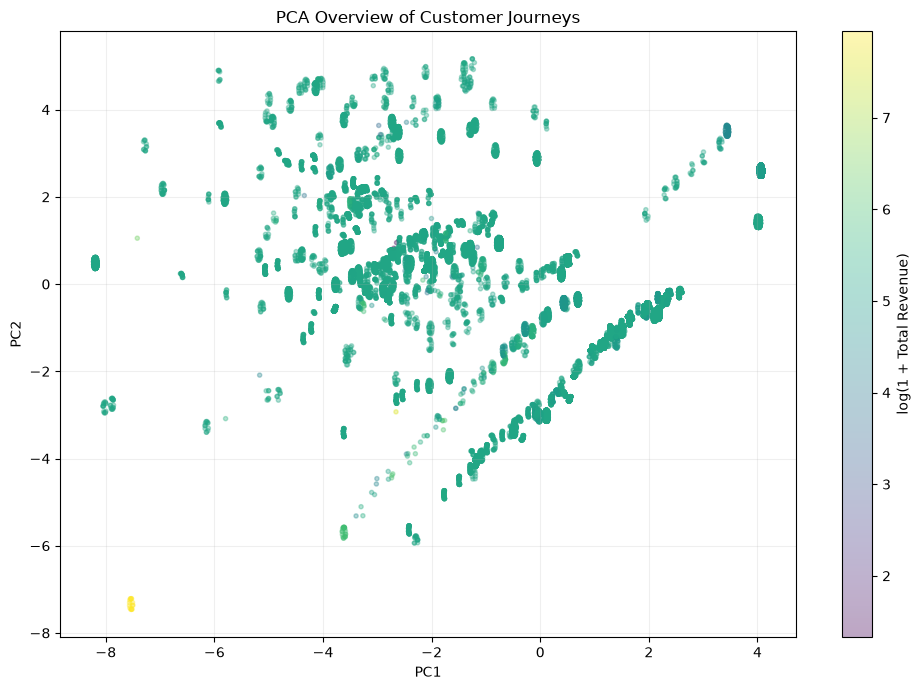

In [79]:
dashboard_pca = (
    pca_projection[
        ["PC1", "PC2"]
    ]
    .join(
        journey_df[
            ["total_revenue"]
        ]
    )
)

dashboard_pca_sample = (
    dashboard_pca.sample(
        n=min(
            25000,
            len(dashboard_pca)
        ),
        random_state=42
    )
)

plt.figure(
    figsize=(10, 7)
)

scatter = plt.scatter(
    dashboard_pca_sample["PC1"],
    dashboard_pca_sample["PC2"],
    c=np.log1p(
        dashboard_pca_sample[
            "total_revenue"
        ]
    ),
    s=9,
    alpha=0.35
)

plt.colorbar(
    scatter,
    label="log(1 + Total Revenue)"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "PCA Overview of Customer Journeys"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

### 8.2 Cluster Visualization

The following visualization presents the four K-Means journey profiles on the first two PCA dimensions.

The purpose is not to prove that four objectively correct customer groups exist.

Instead, the plot provides an intuitive visual summary of how the centroid-based clustering solution divides the global PCA space.

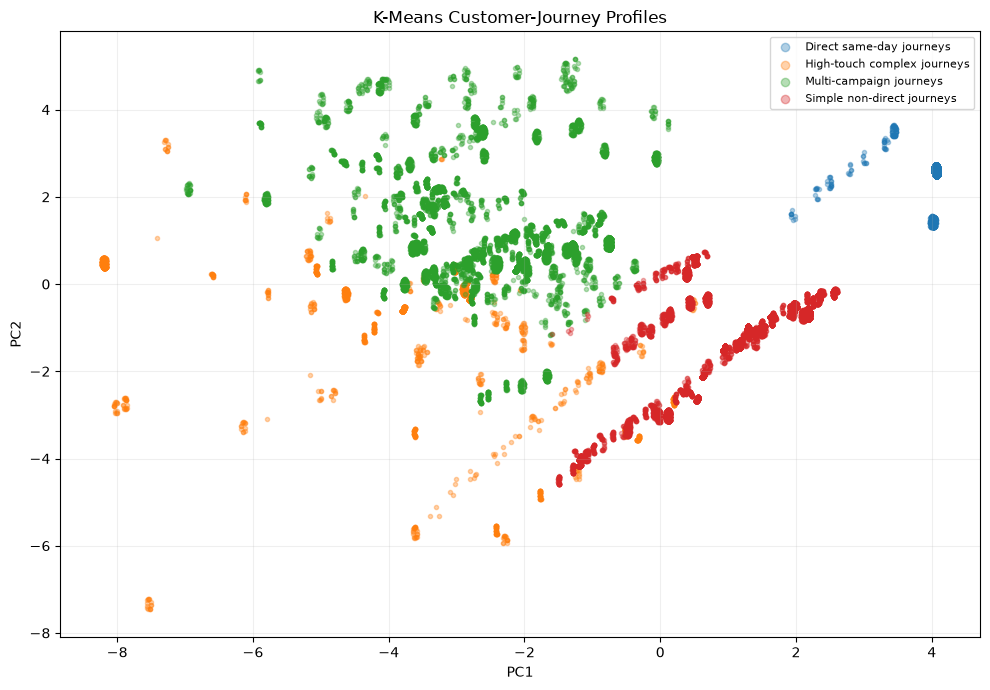

In [80]:
cluster_dashboard = (
    pca_projection[
        ["PC1", "PC2"]
    ]
    .copy()
)

cluster_dashboard[
    "KMeans_Label"
] = kmeans_labels

cluster_dashboard[
    "Cluster"
] = [
    kmeans_semantic_names[label]
    for label in kmeans_labels
]

cluster_dashboard_sample = (
    cluster_dashboard.sample(
        n=min(
            25000,
            len(cluster_dashboard)
        ),
        random_state=42
    )
)

plt.figure(
    figsize=(10, 7)
)

for cluster_name, group in (
    cluster_dashboard_sample
    .groupby("Cluster")
):

    plt.scatter(
        group["PC1"],
        group["PC2"],
        s=9,
        alpha=0.35,
        label=cluster_name
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "K-Means Customer-Journey Profiles"
)

plt.legend(
    fontsize=8,
    markerscale=2
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

### 8.3 Interactive Anomaly Exploration

The interactive panel allows the user to switch between:

- Z-Score,
- Isolation Forest,
- Local Outlier Factor.

All three methods are displayed on the same reproducible 10,000-journey sample so that the visual comparison is fair.

The table below the visualization shows the highest-scoring observations for the selected method together with interpretable business variables.

The anomaly score directions are standardized in this dashboard so that **larger values represent more unusual observations**.

In [81]:
import ipywidgets as widgets
from IPython.display import (
    display,
    clear_output
)

dashboard_anomaly_base = (
    pca_projection
    .loc[
        anomaly_sample_paths,
        ["PC1", "PC2"]
    ]
    .join(
        journey_df[
            [
                "total_revenue",
                "days_till_key_event",
                "touchpoints",
                "path_segments",
                "unique_campaigns",
                "campaign_entropy",
                "revenue_per_touchpoint",
                "missing_path_step"
            ]
        ]
    )
)

dashboard_anomaly_base[
    "Z_Score"
] = common_anomaly_results[
    "Z_Score"
]

dashboard_anomaly_base[
    "Isolation_Forest"
] = common_anomaly_results[
    "Isolation_Forest"
]

dashboard_anomaly_base[
    "LOF"
] = common_anomaly_results[
    "LOF"
]


dashboard_anomaly_base[
    "Z_Score_Value"
] = (
    zscore_max_abs
    .loc[
        anomaly_sample_paths
    ]
)

dashboard_anomaly_base[
    "Isolation_Forest_Value"
] = (
    iforest_anomaly_score[
        anomaly_sample_positions
    ]
)

dashboard_anomaly_base[
    "LOF_Value"
] = (
    lof_anomaly_score_sample
)


method_dropdown = widgets.Dropdown(
    options=[
        "Z-Score",
        "Isolation Forest",
        "LOF"
    ],
    value="Isolation Forest",
    description="Method:"
)

top_n_slider = widgets.IntSlider(
    value=10,
    min=5,
    max=30,
    step=5,
    description="Top N:"
)

dashboard_output = widgets.Output()


def update_anomaly_dashboard(
    change=None
):

    with dashboard_output:

        clear_output(
            wait=True
        )

        method = (
            method_dropdown.value
        )

        top_n = (
            top_n_slider.value
        )

        if method == "Z-Score":

            flag_column = "Z_Score"
            score_column = "Z_Score_Value"
            plot_title = "Z-Score"

        elif method == "Isolation Forest":

            flag_column = "Isolation_Forest"
            score_column = "Isolation_Forest_Value"
            plot_title = "Isolation Forest"

        else:

            flag_column = "LOF"
            score_column = "LOF_Value"
            plot_title = "Local Outlier Factor"

        normal_points = (
            dashboard_anomaly_base[
                ~dashboard_anomaly_base[
                    flag_column
                ]
            ]
        )

        anomalous_points = (
            dashboard_anomaly_base[
                dashboard_anomaly_base[
                    flag_column
                ]
            ]
        )

        plt.figure(
            figsize=(10, 6)
        )

        plt.scatter(
            normal_points["PC1"],
            normal_points["PC2"],
            s=8,
            alpha=0.15,
            label="Not flagged"
        )

        plt.scatter(
            anomalous_points["PC1"],
            anomalous_points["PC2"],
            s=20,
            alpha=0.65,
            label="Anomaly"
        )

        plt.xlabel("PC1")
        plt.ylabel("PC2")

        plt.title(
            f"{plot_title} – Interactive Anomaly View"
        )

        plt.legend()

        plt.grid(
            alpha=0.2
        )

        plt.tight_layout()
        plt.show()

        print(
            f"Flagged journeys: "
            f"{len(anomalous_points):,} / "
            f"{len(dashboard_anomaly_base):,}"
        )

        print(
            f"\nTop {top_n} journeys "
            f"according to {plot_title}:"
        )

        top_anomalies = (
            dashboard_anomaly_base
            .sort_values(
                score_column,
                ascending=False
            )
            .head(top_n)
            [
                [
                    score_column,
                    "total_revenue",
                    "days_till_key_event",
                    "touchpoints",
                    "path_segments",
                    "unique_campaigns",
                    "campaign_entropy",
                    "revenue_per_touchpoint",
                    "missing_path_step"
                ]
            ]
        )

        display(
            top_anomalies.round(4)
        )


method_dropdown.observe(
    update_anomaly_dashboard,
    names="value"
)

top_n_slider.observe(
    update_anomaly_dashboard,
    names="value"
)

display(
    widgets.HBox(
        [
            method_dropdown,
            top_n_slider
        ]
    )
)

display(
    dashboard_output
)

update_anomaly_dashboard()

Output()

### Interactive Dashboard Interpretation

The interactive exploration demonstrates visually that the three algorithms focus on different regions of the journey space.

Z-Score marks a relatively broad set of globally extreme observations.

Isolation Forest produces a smaller and more selective multidimensional anomaly set.

LOF highlights observations that are sparse relative to their local neighborhoods.

The dashboard therefore reinforces one of the central conclusions of this project: anomaly detection depends strongly on the mathematical definition of abnormality.

### 8.4 Pairplot of Major Business Features

A pairplot is used to examine relationships between several interpretable variables in their original business units.

Only a reproducible sample is plotted because displaying more than 93,000 observations would make the figure visually unreadable and computationally unnecessary.

The pairplot complements the correlation matrix because it can reveal:

- nonlinear relationships,
- discrete structures,
- skewed distributions,
- dense regions,
- and extreme observations.

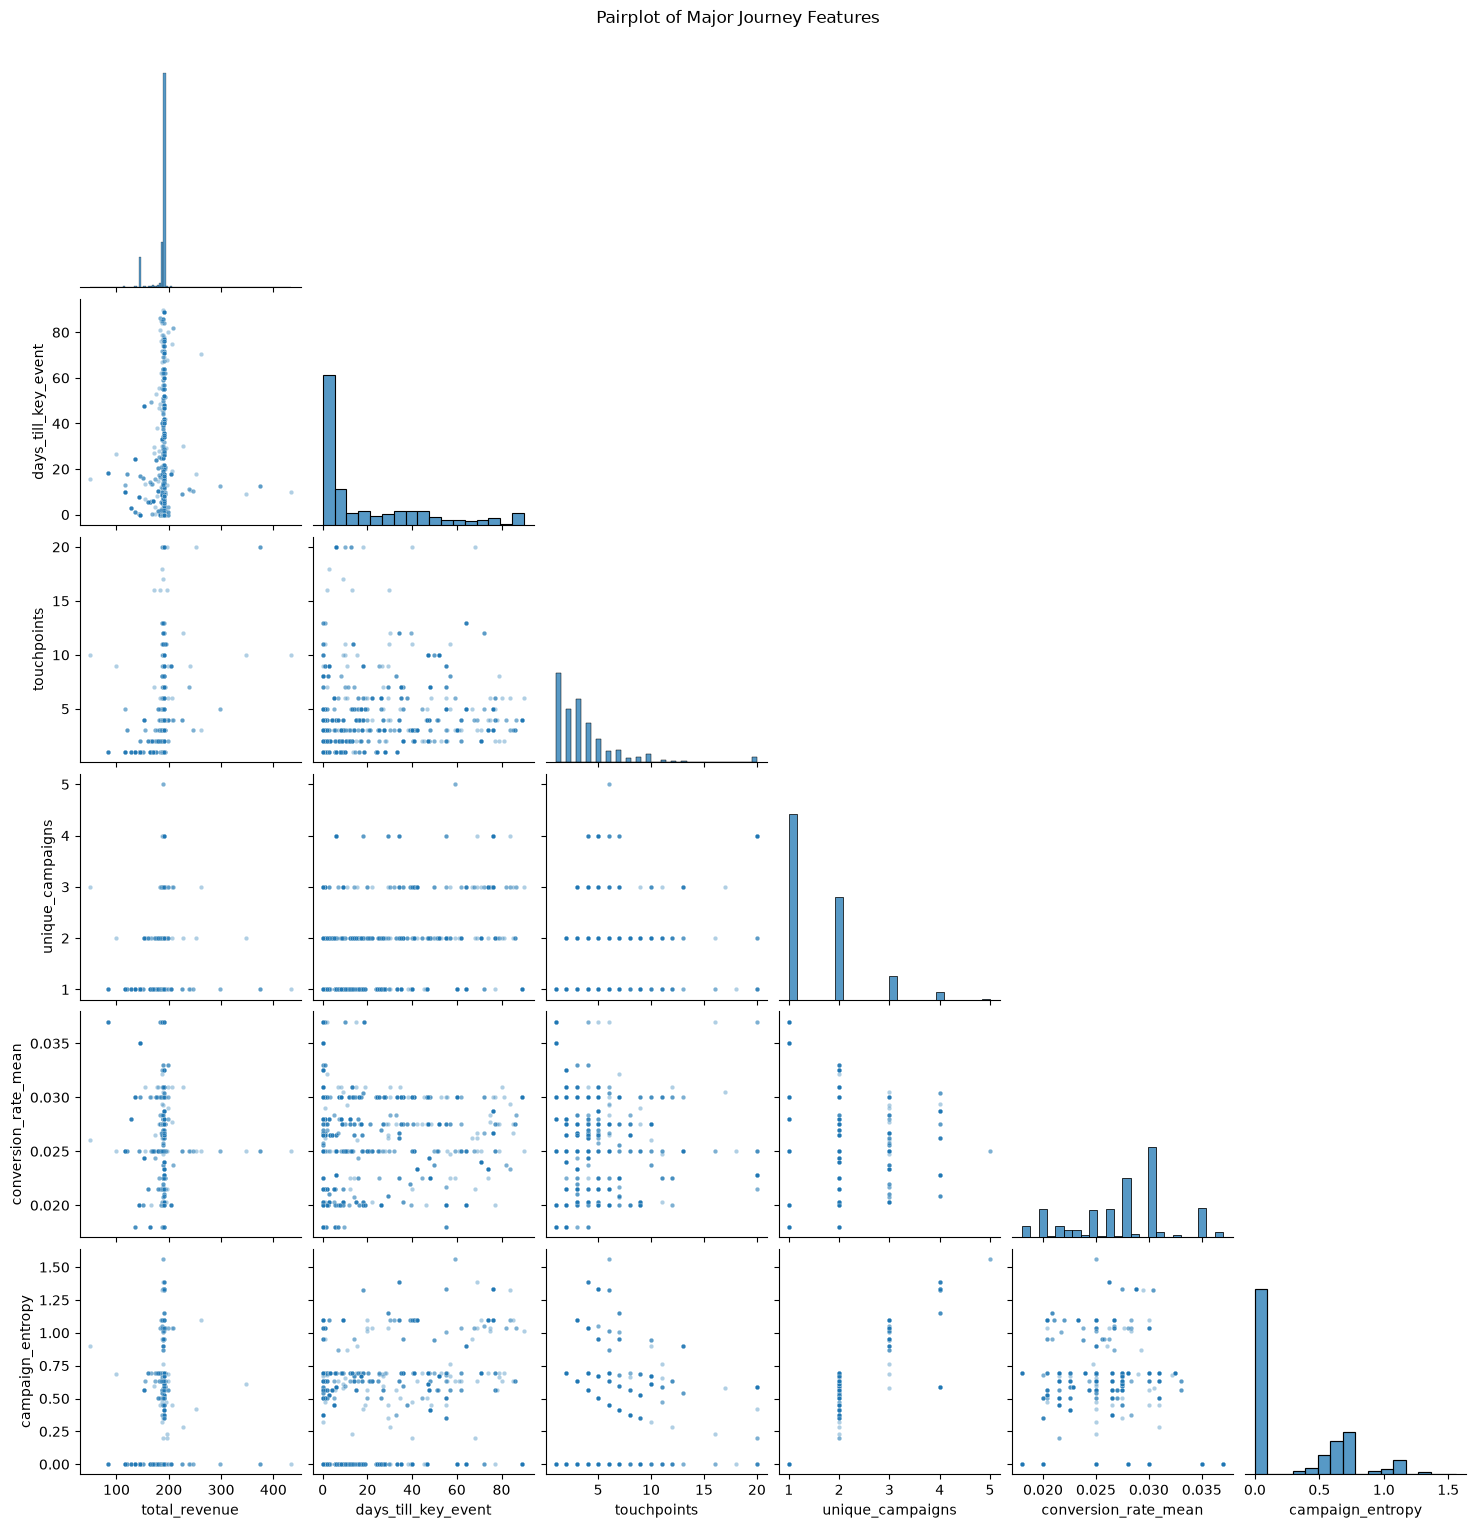

In [82]:
pairplot_features = [
    "total_revenue",
    "days_till_key_event",
    "touchpoints",
    "unique_campaigns",
    "conversion_rate_mean",
    "campaign_entropy"
]

pairplot_data = (
    journey_df[
        pairplot_features
    ]
    .sample(
        n=min(
            2000,
            len(journey_df)
        ),
        random_state=42
    )
)

sns.pairplot(
    pairplot_data,
    corner=True,
    diag_kind="hist",
    plot_kws={
        "s": 10,
        "alpha": 0.35
    }
)

plt.suptitle(
    "Pairplot of Major Journey Features",
    y=1.02
)

plt.show()

### 8.5 Feature Correlation Heatmap

The compact heatmap below focuses on interpretable business features rather than all engineered variables.

It summarizes relationships between revenue, journey duration, interaction intensity, campaign complexity, conversion behavior, and traffic-source composition.

Strong correlations help explain why PCA was able to remove substantial redundancy from the original numerical representation.

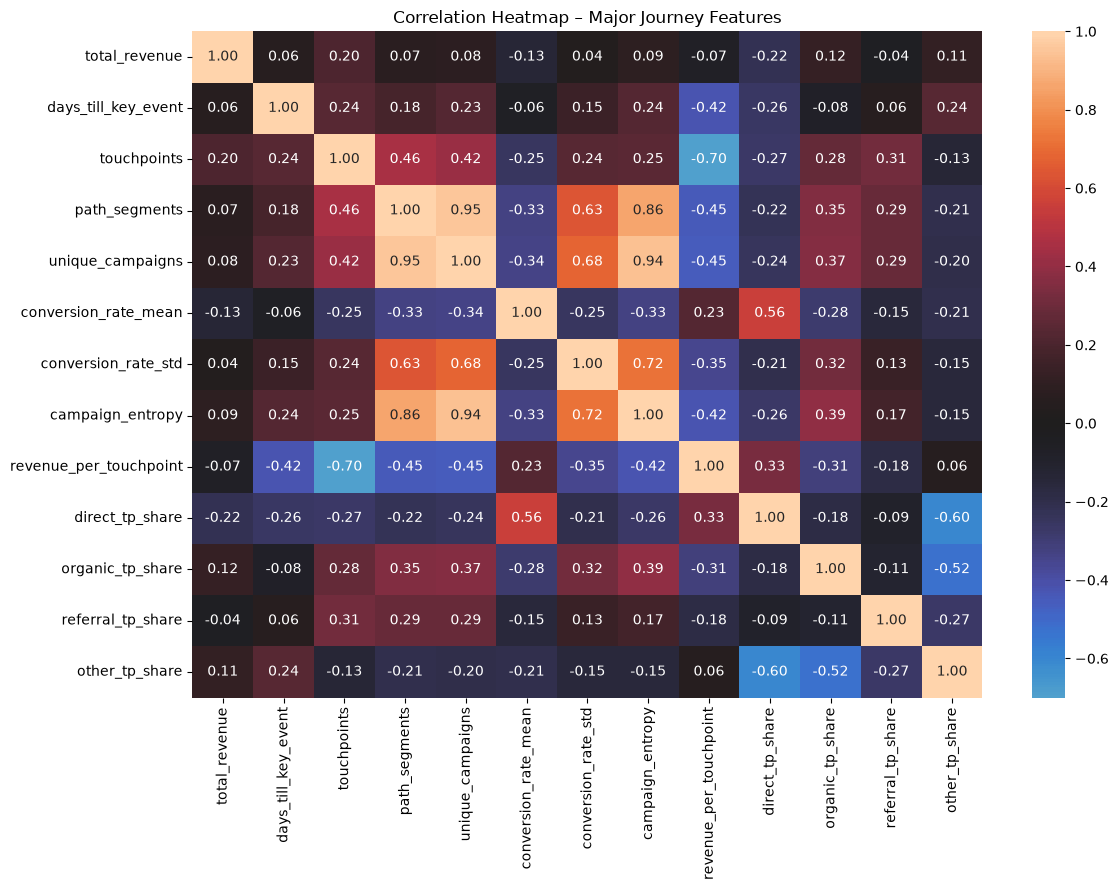

In [83]:
dashboard_heatmap_features = [
    "total_revenue",
    "days_till_key_event",
    "touchpoints",
    "path_segments",
    "unique_campaigns",
    "conversion_rate_mean",
    "conversion_rate_std",
    "campaign_entropy",
    "revenue_per_touchpoint",
    "direct_tp_share",
    "organic_tp_share",
    "referral_tp_share",
    "other_tp_share"
]

dashboard_correlation = (
    journey_df[
        dashboard_heatmap_features
    ]
    .corr()
)

plt.figure(
    figsize=(12, 9)
)

sns.heatmap(
    dashboard_correlation,
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Correlation Heatmap – Major Journey Features"
)

plt.tight_layout()
plt.show()

### 8.6 Anomaly-Method Agreement Heatmap

The second heatmap summarizes pairwise agreement between the three anomaly-detection methods using Jaccard similarity.

This visualization emphasizes that the algorithms share some detections but also produce substantial method-specific anomaly sets.

,Z_Score,Isolation_Forest,LOF
Z_Score,1.0000,0.2019,0.1009
Isolation_Forest,0.2019,1.0000,0.2385
LOF,0.1009,0.2385,1.0000


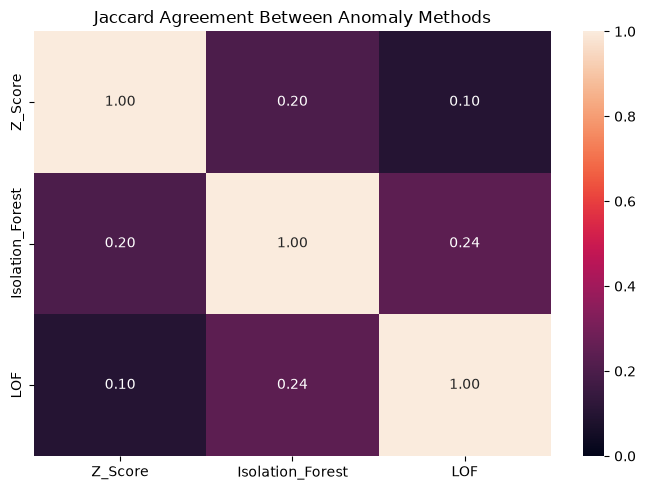

In [84]:
anomaly_methods = [
    "Z_Score",
    "Isolation_Forest",
    "LOF"
]

agreement_matrix = pd.DataFrame(
    index=anomaly_methods,
    columns=anomaly_methods,
    dtype=float
)

for method_a in anomaly_methods:

    for method_b in anomaly_methods:

        agreement_matrix.loc[
            method_a,
            method_b
        ] = binary_jaccard(
            common_anomaly_results[
                method_a
            ],
            common_anomaly_results[
                method_b
            ]
        )

display(
    agreement_matrix.round(4)
)

plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    agreement_matrix,
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1
)

plt.title(
    "Jaccard Agreement Between Anomaly Methods"
)

plt.tight_layout()
plt.show()

### 8.7 Dashboard Conclusions

The visualization dashboard summarizes the major structures discovered throughout the project.

- The PCA overview demonstrates the global geometry and dimensional compression of the customer journeys.
- The K-Means visualization provides an interpretable view of broad customer-journey profiles.
- Interactive anomaly exploration shows how the three anomaly methods emphasize different observations.
- The pairplot reveals distributional and pairwise structure in major business variables.
- The feature heatmap highlights redundancy and related behavioral dimensions.
- The anomaly-agreement heatmap makes the limited agreement between detection methods immediately visible.

The dashboard is intended for exploration and communication rather than as an independent source of analytical conclusions.

All interpretations remain grounded in the complete statistical and methodological analysis presented earlier in the notebook.

## 9. Submission, Methodology, and Reproducibility

### Methodological Summary

The analysis follows a reproducible unsupervised-learning pipeline:

1. Load and verify the raw Kaggle dataset.
2. Inspect its long-format structure and distinguish structural missingness from genuine missing information.
3. Aggregate the data from journey-step level to one numerical observation per `Path ID`.
4. Perform exploratory data analysis, including distributions, correlations, skewness, kurtosis, and extreme-value investigation.
5. Standardize the numerical representation when required by the mathematical assumptions of the subsequent methods.
6. Apply PCA and evaluate explained variance, dimensionality reduction, component contributions, and stability.
7. Compare three clustering approaches:
   - K-Means,
   - DBSCAN,
   - Ward hierarchical clustering.
8. Cluster both observations and the transposed feature matrix.
9. Apply three anomaly-detection approaches:
   - classical Z-Score,
   - Isolation Forest,
   - Local Outlier Factor.
10. Compare anomaly methods using agreement, scaling sensitivity, dimensionality sensitivity, runtime, robustness, and interpretability.
11. Critically discuss limitations, uncertainty, false positives, false negatives, and ethical considerations.
12. Summarize the results through an optional visualization dashboard.

Methodological choices were not based solely on obtaining visually attractive clusters or anomalies.

Parameter selection, computational limitations, feature geometry, scalability, assumptions, and real-world interpretability were considered throughout the analysis.

### Mathematical and Conceptual Coverage

Mathematical intuition is included throughout the notebook rather than being separated from the corresponding methods.

The report explains the main mathematical ideas behind:

- feature standardization,
- skewness and kurtosis,
- PCA eigenvectors and explained variance,
- Shannon entropy,
- K-Means within-cluster squared error,
- Silhouette score,
- DBSCAN density neighborhoods,
- Ward hierarchical clustering,
- within-cluster versus global variance,
- Z-scores,
- Isolation Forest path lengths and anomaly scores,
- LOF local reachability density,
- and Jaccard agreement.

The mathematical explanations are accompanied by discussion of assumptions and limitations so that formulas are connected to their practical meaning in the dataset.

### Real-World Interpretation

The analysis is interpreted in the context of e-commerce customer journeys rather than only through numerical model outputs.

The discovered structures suggest differences between:

- simple direct conversions,
- simple non-direct journeys,
- multi-campaign journeys,
- and high-touch complex journeys.

The anomaly analysis also demonstrates that statistically rare observations can represent several different phenomena:

- valid rare customer behavior,
- unusual combinations of marketing interactions,
- extreme revenue or duration,
- sparse local behavior,
- or possible data-quality artifacts.

The results should not be treated as universal e-commerce rules.

The data originates from the Google Merchandise Store and does not include geographic information, advertising costs, customer demographics, or a complete description of the original extraction and sampling process.

Therefore, findings from this project should be viewed as evidence and hypotheses rather than causal or universal conclusions.

### Critical Limitations and Alternative Explanations

Several findings require cautious interpretation.

#### Long-Format Data Structure

The original rows are not independent customers. Multiple rows can belong to one Path ID.

Ignoring this structure would produce an invalid analytical representation.

#### Dataset Selection Bias

The dataset is centered on recorded key-event journeys and may underrepresent visitors who never reach such an event.

#### Feature Engineering

The 27 journey-level variables are analytically useful but are not direct raw measurements.

Different reasonable feature-engineering decisions could produce somewhat different PCA, clustering, and anomaly results.

#### Redundancy

Some engineered variables are strongly correlated, and two exact linear dependencies exist.

PCA reduces this redundancy, but removing dimensions may also discard information relevant to local anomalies.

#### Unexpected Extreme-Revenue Pattern

A particularly unexpected result is the exact overlap between the 47 maximum-revenue journeys and the 47 journeys containing the missing `Path Step` issue.

This could represent:

- a real special journey type,
- a transformation artifact,
- a source-system convention,
- or another undocumented data-processing behavior.

Without additional source documentation, no single explanation can be proven.

#### Lack of Anomaly Ground Truth

There is no verified anomaly label.

Therefore, agreement between algorithms can strengthen evidence of unusual structure but cannot establish whether an observation is truly erroneous or problematic.

#### Clustering Ambiguity

Moderate clustering-quality metrics and disagreement between algorithms indicate that the dataset does not contain one obvious, uniquely correct cluster structure.

This is a valid unsupervised-learning result rather than a failure of the analysis.

In [85]:
import sys
import platform
import sklearn
import scipy
import matplotlib
import seaborn

reproducibility_checks = {
    "Dataset loaded":
        "raw_df" in globals(),

    "Expected raw rows":
        (
            "raw_df" in globals()
            and len(raw_df) == 150011
        ),

    "Expected raw columns":
        (
            "raw_df" in globals()
            and raw_df.shape[1] == 9
        ),

    "Journey-level dataset created":
        "journey_features" in globals(),

    "Expected Path IDs":
        (
            "journey_features" in globals()
            and len(journey_features) == 93629
        ),

    "No missing analytical values":
        (
            "journey_features" in globals()
            and journey_features.isna()
                .sum()
                .sum() == 0
        ),

    "PCA completed":
        "X_pca_selected" in globals(),

    "K-Means completed":
        "kmeans_labels" in globals(),

    "DBSCAN completed":
        "dbscan_labels" in globals(),

    "Hierarchical clustering completed":
        "hierarchical_labels" in globals(),

    "Z-Score completed":
        "zscore_anomaly_mask" in globals(),

    "Isolation Forest completed":
        "iforest_anomaly_mask" in globals(),

    "LOF completed":
        "lof_anomaly_mask_sample" in globals(),

    "Anomaly comparison completed":
        "common_anomaly_results" in globals()
}

reproducibility_table = pd.DataFrame({
    "Check":
        reproducibility_checks.keys(),

    "Passed":
        reproducibility_checks.values()
})

display(
    reproducibility_table
)

if reproducibility_table[
    "Passed"
].all():

    print(
        "\nALL REPRODUCIBILITY CHECKS PASSED."
    )

else:

    print(
        "\nSome checks failed. "
        "Review the notebook before submission."
    )

,Check,Passed
0,Dataset loaded,True
1,Expected raw rows,True
2,Expected raw columns,True
3,Journey-level dataset created,True
4,Expected Path IDs,True
5,No missing analytical values,True
6,PCA completed,True
7,K-Means completed,True
8,DBSCAN completed,True
9,Hierarchical clustering completed,True



ALL REPRODUCIBILITY CHECKS PASSED.


In [86]:
environment_info = pd.DataFrame({
    "Component": [
        "Python",
        "Operating System",
        "pandas",
        "NumPy",
        "SciPy",
        "scikit-learn",
        "Matplotlib",
        "Seaborn"
    ],

    "Version": [
        sys.version.split()[0],
        platform.platform(),
        pd.__version__,
        np.__version__,
        scipy.__version__,
        sklearn.__version__,
        matplotlib.__version__,
        sns.__version__
    ]
})

display(
    environment_info
)

,Component,Version
0,Python,3.13.14
1,Operating System,Windows-11-10.0.26200-SP0
2,pandas,3.0.3
3,NumPy,2.5.1
4,SciPy,1.18.0
5,scikit-learn,1.9.0
6,Matplotlib,3.11.1
7,Seaborn,0.13.2


In [87]:
requirements_content = f"""pandas=={pd.__version__}
numpy=={np.__version__}
scipy=={scipy.__version__}
scikit-learn=={sklearn.__version__}
matplotlib=={matplotlib.__version__}
seaborn=={sns.__version__}
ipywidgets
jupyter
"""

with open(
    "requirements.txt",
    "w",
    encoding="utf-8"
) as requirements_file:

    requirements_file.write(
        requirements_content
    )

print(
    "requirements.txt created successfully."
)

print(
    "\nContents:"
)

print(
    requirements_content
)

requirements.txt created successfully.

Contents:
pandas==3.0.3
numpy==2.5.1
scipy==1.18.0
scikit-learn==1.9.0
matplotlib==3.11.1
seaborn==0.13.2
ipywidgets
jupyter



### Reproducibility

The notebook is designed to be executed sequentially from beginning to end.

The dataset file:

`Dataset_v4.csv`

should remain in the same project directory as the notebook.

All stochastic procedures use fixed random seeds where applicable, including:

- sampling,
- K-Means initialization,
- PCA stability experiments,
- Isolation Forest,
- robustness experiments.

This improves reproducibility while recognizing that results can still vary slightly across software versions, operating systems, or numerical libraries.

A `requirements.txt` file is generated to document the principal Python dependencies used in the analysis.

Before submission, the notebook should be restarted and executed using **Run All** to verify that the complete analysis can be reproduced without relying on variables remaining from an earlier interactive session.

### Final Submission Checklist

- [x] `Dataset_v4.csv` is included or available according to the submission instructions.
- [x] The notebook opens successfully.
- [x] The notebook runs from top to bottom without errors.
- [x] Dataset source and limitations are documented.
- [x] EDA includes structure, missing values, data types, statistical summaries, correlations, histograms, boxplots, skewness, kurtosis, and extreme-value discussion.
- [x] PCA includes explained variance, cumulative variance, scree plot, 2D projection, 3D projection, component interpretation, and stability discussion.
- [x] At least three clustering methods are implemented and compared.
- [x] Feature-space clustering is performed on the transposed analytical matrix.
- [x] Z-Score anomaly detection is implemented and discussed.
- [x] Isolation Forest is implemented and discussed.
- [x] LOF is implemented and discussed.
- [x] Anomaly-method agreement and disagreement are analyzed.
- [x] Scaling sensitivity is discussed.
- [x] Dimensionality sensitivity is discussed.
- [x] Runtime and scalability are compared.
- [x] Noise robustness is investigated.
- [x] False positives and false negatives are explained in real-world terms.
- [x] The critical-reflection section discusses the curse of dimensionality, Gaussian assumptions, noise versus anomalies, and misleading dimensionality-reduction visualizations.
- [x] Ethical considerations include surveillance, medicine, cybersecurity, privacy, bias, and fairness.
- [x] The optional visualization dashboard runs successfully.
- [x] All major visualizations have titles, labels, and accompanying explanations.
- [x] Mathematical intuition is included in Markdown cells.
- [x] Code uses meaningful variable names and explanatory comments.
- [x] Random seeds are fixed where appropriate.
- [x] `requirements.txt` exists.
- [x] The final reproducibility audit reports that all checks passed.

## Final Conclusion

This project investigated the hidden structure of Google Merchandise Store customer journeys using dimensionality reduction, clustering, and multidimensional anomaly detection.

The analysis demonstrates that the dataset contains meaningful behavioral structure but does not support one uniquely correct unsupervised interpretation.

PCA reveals substantial correlation and redundancy and provides a compact representation of the journey space.

K-Means, DBSCAN, and hierarchical clustering identify different but partially related forms of customer structure because they use different definitions of similarity and cluster geometry.

Likewise, Z-Score, Isolation Forest, and LOF produce substantially different anomaly sets because they define abnormality through global extremeness, random isolation, and local density respectively.

One of the most important findings is therefore methodological rather than algorithmic:

> Unsupervised-learning results depend strongly on the representation of the data, the assumptions of the method, the selected hyperparameters, and the real-world interpretation of the observations.

No cluster label or anomaly label should be treated as an unquestionable fact.

The results are most useful when multiple methods, statistical evidence, data-quality investigation, domain interpretation, and critical reasoning are considered together.

This conclusion reflects the central challenge of real-world data science: not simply producing an answer, but understanding why that answer should be trusted, when it may fail, and what its limitations mean in practice.

## Appendix A – Practical E-Commerce Experiment Ideas

This appendix is a practical extension of the academic analysis.

The dataset used in this project originates from the **Google Merchandise Store**, not from a cosmetics or Shopify store. Therefore, the findings below should be treated as **hypotheses to test**, not as rules that can automatically be transferred to another business.

| Finding from this project | Possible e-commerce experiment | Data required from a real store |
|---|---|---|
| Customer journeys differ in the number of touchpoints required before conversion. | Compare conversion behavior of short journeys with customers exposed to several marketing interactions. | Customer/session identifier, timestamps, traffic source, purchase event. |
| Some journeys involve several campaigns or traffic sources before conversion. | Test whether remarketing or sequential campaigns improve conversion for customers who do not purchase on their first visit. | Source/medium/campaign history, sessions, purchase timestamp. |
| Direct same-day journeys form a distinctive behavioral group. | Compare new campaign-driven visitors with direct or returning visitors instead of assuming all conversions follow the same journey. | New/returning status, source, sessions, purchase event. |
| Revenue per touchpoint varies substantially between journeys. | Investigate whether some acquisition paths generate similar revenue with fewer customer interactions. | Revenue, journey touchpoints, source/medium/campaign. |
| Different anomaly methods identify different kinds of unusual journeys. | Use anomaly scores as a manual analytics-review tool for unusual orders, journeys, or possible tracking problems rather than automatically deleting observations. | Order/session data, journey features, tracking-quality indicators. |
| Data-quality artifacts can themselves appear statistically anomalous. | Periodically inspect unusual Shopify/GA4 journeys for missing campaign information, broken tracking, duplicated events, or unexpected attribution. | Raw GA4/Shopify exports and tracking metadata. |

### Practical Use

If comparable Shopify and GA4 data become available, the methodology from this notebook can be reused:

1. define one meaningful customer-journey observation,
2. construct numerical behavioral features,
3. perform EDA,
4. investigate redundancy using PCA,
5. identify behavioral journey groups,
6. compare multiple anomaly-detection methods,
7. and convert the findings into controlled business experiments.

The models and numerical thresholds obtained from the Google Merchandise Store should **not** be copied directly.

The reusable asset is the **analytical methodology**, not the specific cluster boundaries or anomaly thresholds found in this dataset. 